## barplot

数据集形状: (333, 7)

数据集列名: ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']

企鹅种类: ['Adelie' 'Chinstrap' 'Gentoo']
岛屿: ['Torgersen' 'Biscoe' 'Dream']
性别: ['Male' 'Female']


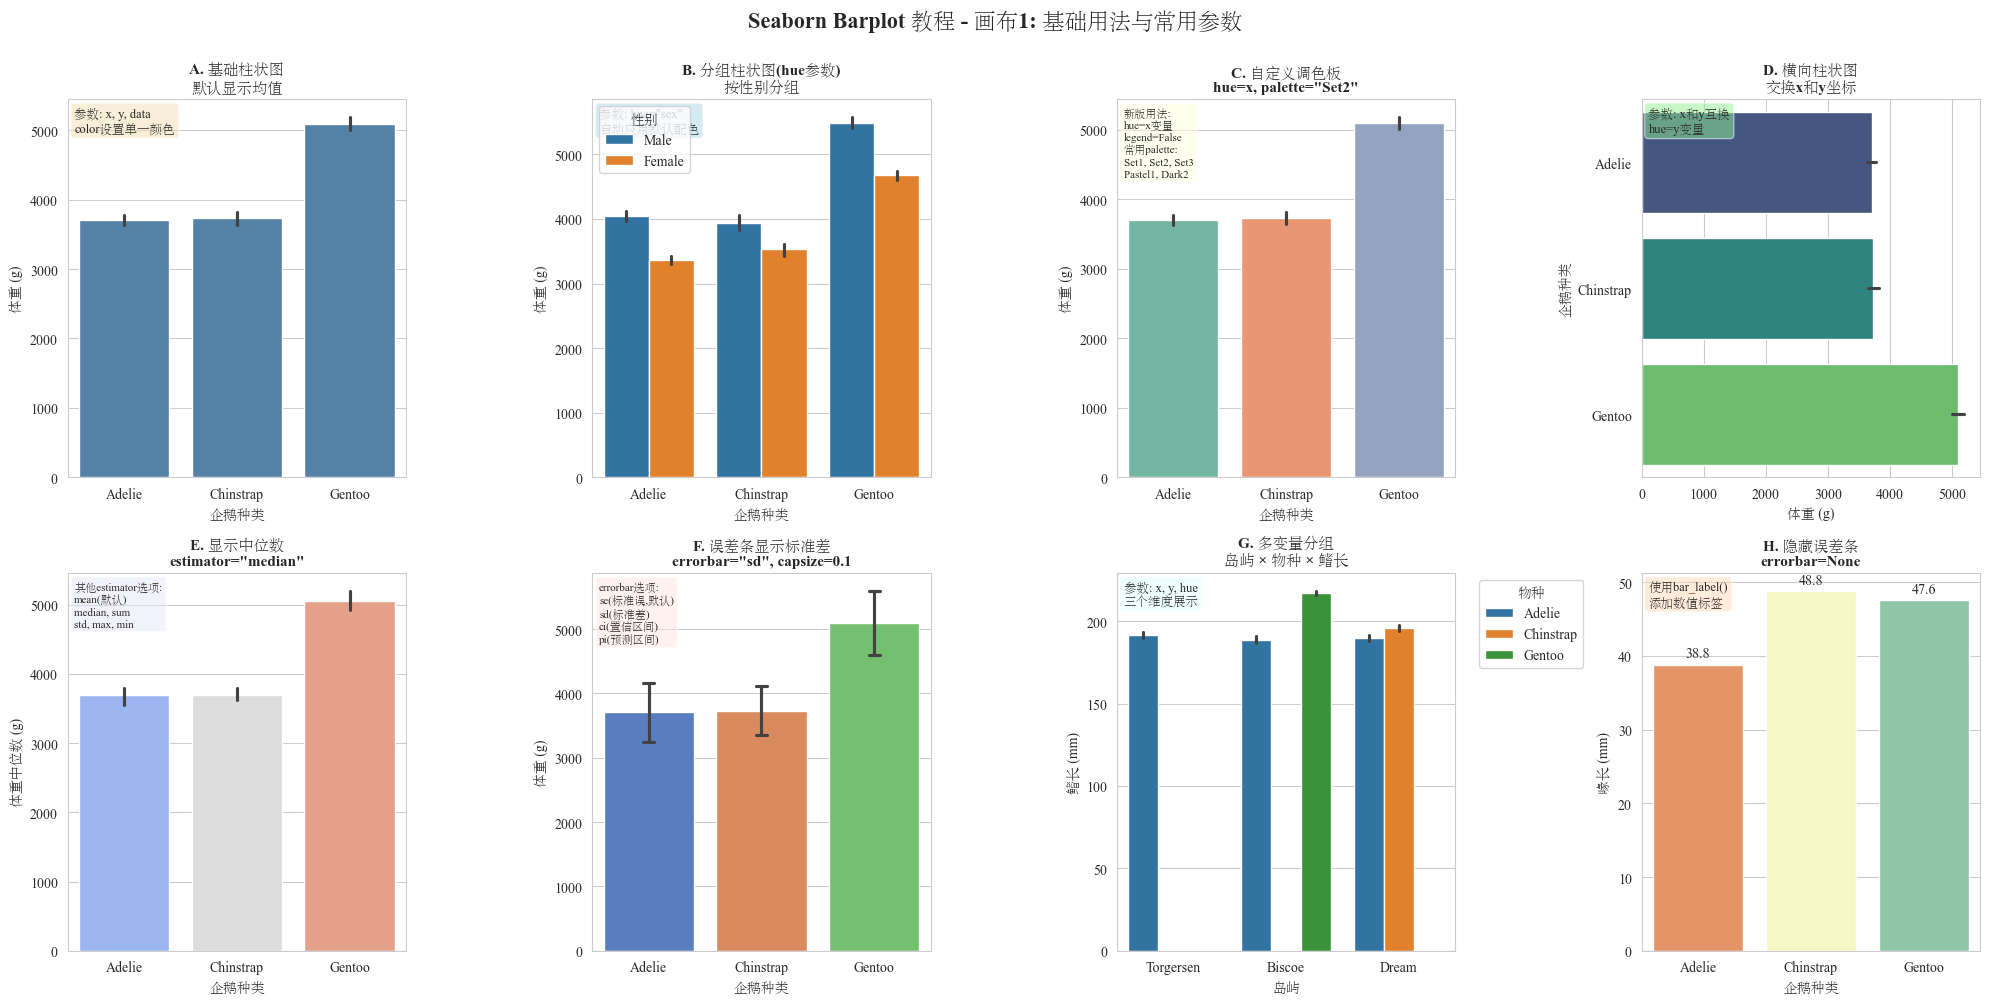

In [1]:
import seaborn as sns                    # 导入Seaborn库，用于高级统计图表绘制
import matplotlib.pyplot as plt          # 导入Matplotlib的Pyplot模块，用于基础绘图
import pandas as pd                      # 导入Pandas库，用于数据处理和分析
import numpy as np                       # 导入NumPy库，用于数值计算

# 设置中文显示和样式
plt.rcParams['axes.unicode_minus'] = False      # 禁用负号自动转成中文字符，解决坐标轴负号显示问题
sns.set_style("whitegrid")                      # 设置Seaborn绘图样式为白色网格背景，便于数据阅读
plt.rcParams['font.family'] = ['Times New Roman', 'STsong']    # 设置字体优先级：英文用Times New Roman，中文用仿宋

# 加载数据集
penguins = sns.load_dataset('penguins')         # 从Seaborn内置数据集加载企鹅数据集，包含多种企鹅物种的生理测量数据

# 删除缺失值
penguins = penguins.dropna()                    # 删除数据集中的所有缺失值行，确保数据完整性

print(f"数据集形状: {penguins.shape}")          # 打印数据集的行数和列数，显示数据规模
print(f"\n数据集列名: {penguins.columns.tolist()}")    # 打印所有列名列表，帮助了解数据字段
print(f"\n企鹅种类: {penguins['species'].unique()}")   # 打印唯一企鹅种类，显示共有3种企鹅
print(f"岛屿: {penguins['island'].unique()}")          # 打印企鹅栖息的岛屿名称，共3个岛屿
print(f"性别: {penguins['sex'].unique()}")             # 打印性别分类，显示Male和Female两种

# ============================================================
# 画布 1: 基础用法和常用参数
# ============================================================
fig1, axes1 = plt.subplots(2, 4, figsize=(20, 10))      # 创建2行4列的子图布局，总画布大小20x10英寸
fig1.suptitle('Seaborn Barplot 教程 - 画布1: 基础用法与常用参数',     # 设置整个画布的总标题
              fontsize=16,                          # 总标题字体大小16
              fontweight='bold',                    # 总标题加粗显示
              y=1.00)                                # 总标题垂直位置为画布顶部

# ========== 子图 A：最基础的柱状图 ==========
ax = axes1[0, 0]                                    # 获取第1行第1列的子图对象
sns.barplot(data=penguins,                          # 指定数据源：清洗后的企鹅数据集
            x='species',                           # x轴变量：企鹅种类（分类变量）
            y='body_mass_g',                       # y轴变量：体重（数值变量）
            ax=ax,                                 # 指定绘制目标：当前子图
            color='steelblue')                     # 设置柱状图单一颜色为钢蓝色
ax.set_title('A. 基础柱状图\n默认显示均值', fontsize=11, fontweight='bold')    # 设置子图标题，显示均值，双行标题
ax.set_xlabel('企鹅种类', fontsize=10)              # 设置x轴标签：企鹅种类，字体大小10
ax.set_ylabel('体重 (g)', fontsize=10)              # 设置y轴标签：体重（克），字体大小10
ax.text(0.02,                                       # 文本左边距2%的位置
        0.98,                                       # 文本顶部98%的位置
        '参数: x, y, data\ncolor设置单一颜色',       # 文本内容：参数说明
        transform=ax.transAxes,                     # 使用相对坐标系（0-1范围）
        fontsize=9,                                 # 文本字体大小9
        verticalalignment='top',                    # 文本垂直对齐顶部
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))    # 添加圆角背景框，浅黄色半透明

# ========== 子图 B：添加hue参数进行分组 ==========
ax = axes1[0, 1]                                    # 获取第1行第2列的子图对象
sns.barplot(data=penguins,                          # 数据源：企鹅数据集
            x='species',                           # x轴：企鹅种类
            y='body_mass_g',                       # y轴：体重
            hue='sex',                              # hue参数：按性别分组，不同颜色表示不同性别
            ax=ax)                                  # 绘制到当前子图
ax.set_title('B. 分组柱状图(hue参数)\n按性别分组', fontsize=11, fontweight='bold')    # 子图标题说明hue分组
ax.set_xlabel('企鹅种类', fontsize=10)              # x轴标签
ax.set_ylabel('体重 (g)', fontsize=10)              # y轴标签
ax.legend(title='性别', loc='upper left')           # 设置图例：标题为"性别"，位置左上角
ax.text(0.02,                                       # 文本位置
        0.98,
        '参数: hue="sex"\n自动应用默认配色',         # hue参数说明
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))     # 浅蓝色背景框

# ========== 子图 C：自定义颜色palette(带hue) ==========
ax = axes1[0, 2]                                    # 获取第1行第3列子图
sns.barplot(data=penguins,                          # 数据源
            x='species',                           # x轴：种类
            y='body_mass_g',                       # y轴：体重
            hue='species',                         # hue参数：按种类本身分组（每个种类不同颜色）
            palette='Set2',                        # 自定义调色板：Set2（柔和色彩）
            legend=False,                          # 隐藏图例（因为hue=x，图例冗余）
            ax=ax)                                 # 绘制到当前子图
ax.set_title('C. 自定义调色板\nhue=x, palette="Set2"', fontsize=11, fontweight='bold')    # 标题说明调色板用法
ax.set_xlabel('企鹅种类', fontsize=10)
ax.set_ylabel('体重 (g)', fontsize=10)
ax.text(0.02,
        0.98,
        """新版用法:
hue=x变量
legend=False
常用palette:
Set1, Set2, Set3
Pastel1, Dark2""",                           # 多行文本说明新版用法和常用调色板
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

# ========== 子图 D：横向柱状图 ==========
ax = axes1[0, 3]                                    # 获取第1行第4列子图
sns.barplot(data=penguins,                          # 数据源
            x='body_mass_g',                       # x轴：体重（数值）
            y='species',                           # y轴：种类（分类）-交换实现横向
            hue='species',                         # hue：按种类着色
            palette='viridis',                     # 调色板：viridis（连续色彩）
            legend=False,                          # 隐藏图例
            ax=ax)                                 # 绘制到当前子图
ax.set_title('D. 横向柱状图\n交换x和y坐标', fontsize=11, fontweight='bold')      # 标题说明横向实现方法
ax.set_xlabel('体重 (g)', fontsize=10)              # x轴标签：体重
ax.set_ylabel('企鹅种类', fontsize=10)              # y轴标签：种类
ax.text(0.02,
        0.98,
        '参数: x和y互换\nhue=y变量',                 # 说明横向参数设置
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

# ========== 子图 E：不同的统计量estimator ==========
ax = axes1[1, 0]                                    # 获取第2行第1列子图
sns.barplot(data=penguins,                          # 数据源
            x='species',                           # x轴
            y='body_mass_g',                       # y轴
            estimator='median',                    # 统计量：中位数（默认是均值）
            hue='species',                         # hue分组
            palette='coolwarm',                    # 调色板：冷暖色系
            legend=False,                          # 隐藏图例
            ax=ax)                                 # 绘制
ax.set_title('E. 显示中位数\nestimator="median"', fontsize=11, fontweight='bold')     # 标题说明中位数显示
ax.set_xlabel('企鹅种类', fontsize=10)
ax.set_ylabel('体重中位数 (g)', fontsize=10)        # y轴标签明确显示"中位数"
ax.text(0.02,
        0.98,
        """其他estimator选项:
mean(默认)
median, sum
std, max, min""",                            # 列出所有estimator选项
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.5))

# ========== 子图 F：误差条样式errorbar ==========
ax = axes1[1, 1]                                    # 获取第2行第2列子图
sns.barplot(data=penguins,                          # 数据源
            x='species',                           # x轴
            y='body_mass_g',                       # y轴
            errorbar='sd',                         # 误差条：标准差（默认是标准误）
            capsize=0.1,                           # 误差条端点大小：0.1倍柱宽
            hue='species',                         # hue分组
            palette='muted',                       # 调色板：柔和色彩
            legend=False,                          # 隐藏图例
            ax=ax)                                 # 绘制
ax.set_title('F. 误差条显示标准差\nerrorbar="sd", capsize=0.1', fontsize=11, fontweight='bold')
ax.set_xlabel('企鹅种类', fontsize=10)
ax.set_ylabel('体重 (g)', fontsize=10)
ax.text(0.02,
        0.98,
        """errorbar选项:
se(标准误,默认)
sd(标准差)
ci(置信区间)
pi(预测区间)""",                             # 详细列出所有误差条选项
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.5))

# ========== 子图 G：按岛屿分组的体重对比 ==========
ax = axes1[1, 2]                                    # 获取第2行第3列子图
sns.barplot(data=penguins,                          # 数据源
            x='island',                            # x轴：岛屿（分类）
            y='flipper_length_mm',                 # y轴：鳍长（数值）
            hue='species',                         # hue：按物种分组，三维展示
            palette='tab10',                       # 调色板：10色分类色
            ax=ax)                                 # 绘制
ax.set_title('G. 多变量分组\n岛屿 × 物种 × 鳍长', fontsize=11, fontweight='bold')     # 标题说明三维分组
ax.set_xlabel('岛屿', fontsize=10)
ax.set_ylabel('鳍长 (mm)', fontsize=10)
ax.legend(title='物种', bbox_to_anchor=(1.05, 1), loc='upper left')    # 图例移到画布外右侧，节省空间
ax.text(0.02,
        0.98,
        '参数: x, y, hue\n三个维度展示',             # 说明三维参数用法
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.5))

# ========== 子图 H：不显示误差条 ==========
ax = axes1[1, 3]                                    # 获取第2行第4列子图
sns.barplot(data=penguins,                          # 数据源
            x='species',                           # x轴
            y='bill_length_mm',                    # y轴：喙长
            errorbar=None,                         # 完全隐藏误差条
            hue='species',                         # hue分组
            palette='Spectral',                    # 调色板：光谱色
            legend=False,                          # 隐藏图例
            ax=ax)                                 # 绘制
ax.set_title('H. 隐藏误差条\nerrorbar=None', fontsize=11, fontweight='bold')
ax.set_xlabel('企鹅种类', fontsize=10)
ax.set_ylabel('喙长 (mm)', fontsize=10)
# 添加数值标签
for container in ax.containers:                     # 遍历所有柱状图容器
    ax.bar_label(container, fmt='%.1f', padding=3)  # 为每个柱子添加标签：保留1位小数，内边距3点
ax.text(0.02,
        0.98,
        '使用bar_label()\n添加数值标签',             # 说明数值标签添加方法
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='peachpuff', alpha=0.5))

plt.tight_layout()                                  # 自动调整子图间距，避免标题重叠
plt.show()                                          # 显示整个画布1的所有子图

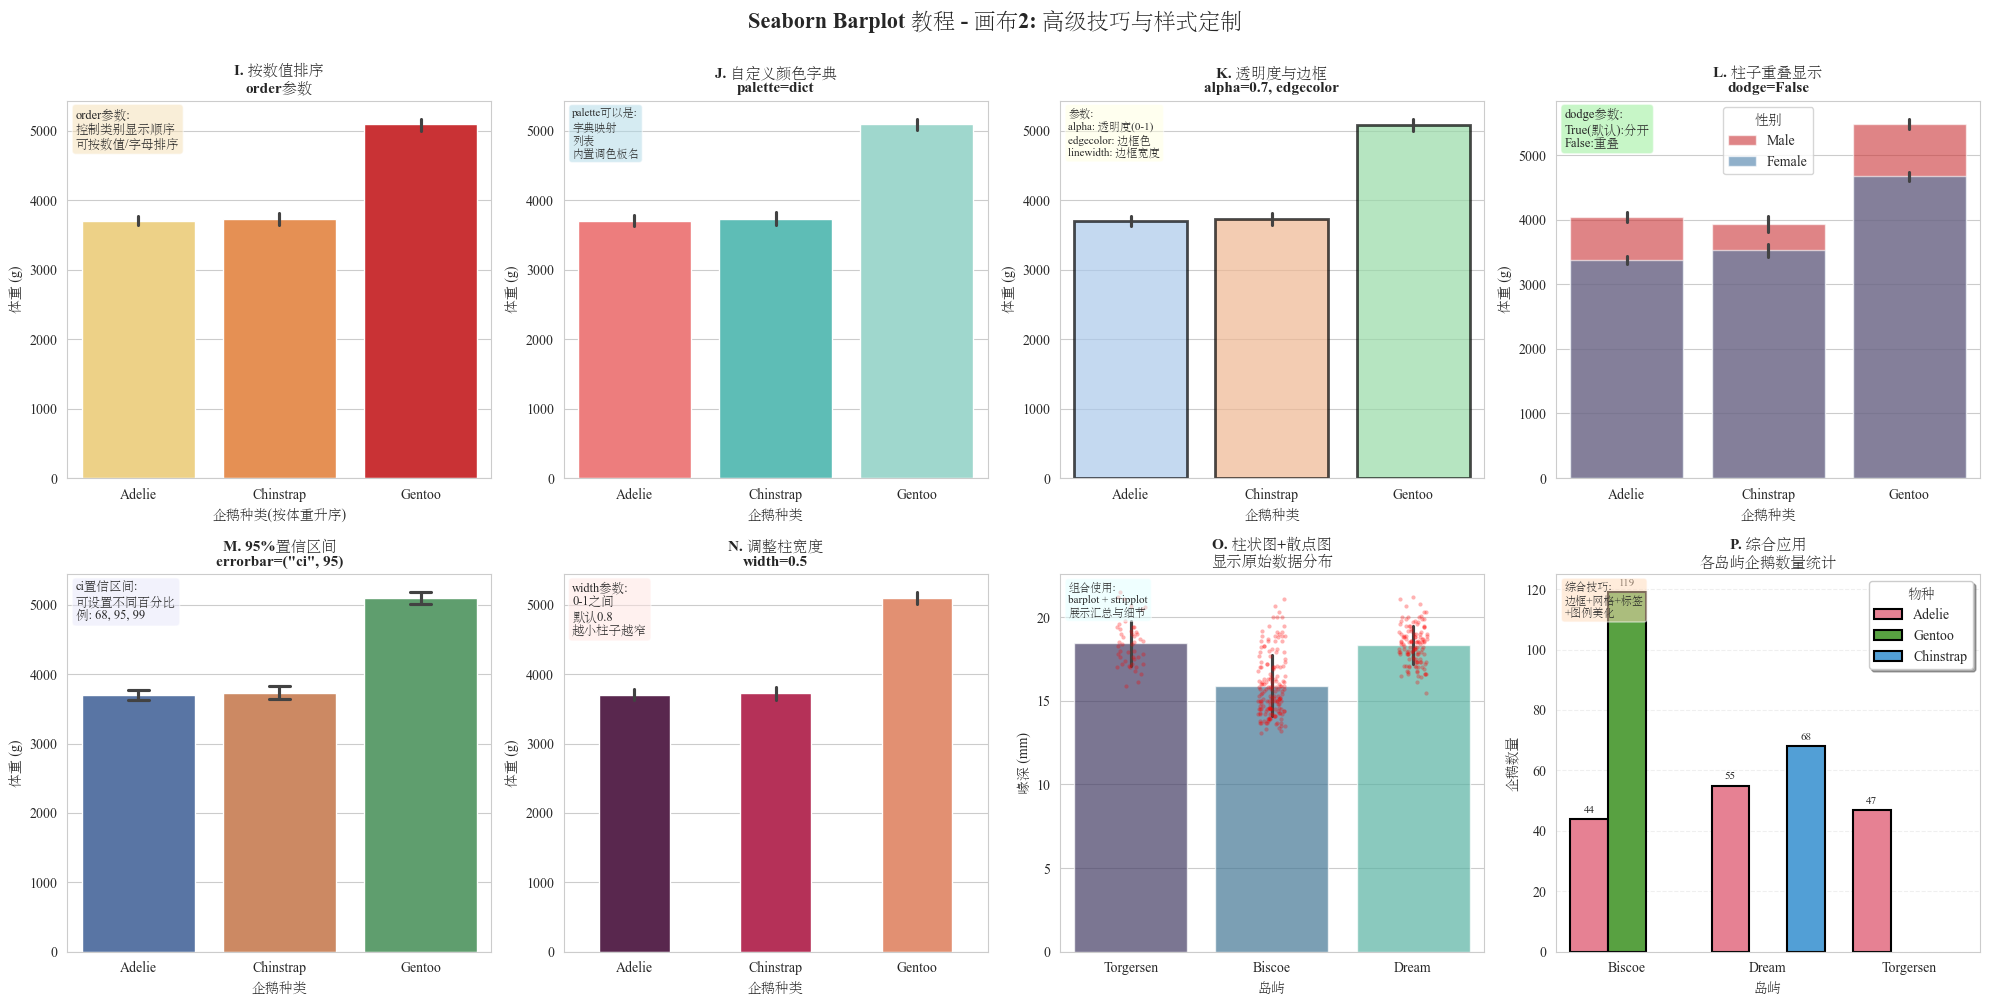

In [2]:
# ============================================================
# 画布 2: 高级技巧和样式定制
# ============================================================
fig2, axes2 = plt.subplots(2, 4, figsize=(20, 10))  # 创建一个2行4列的子图网格，总画布大小为20x10英寸
fig2.suptitle('Seaborn Barplot 教程 - 画布2: 高级技巧与样式定制',  # 设置整个画布的标题，展示本画布主题
              fontsize=16,  # 标题字体大小为16
              fontweight='bold',  # 标题字体加粗
              y=1.00)  # 标题垂直位置调整到画布顶部（1.00表示顶部）

# ========== 子图 I：按数值排序 ==========
ax = axes2[0, 0]  # 获取第1行第1列的子图对象，用于绘制图I
# 计算每个物种的平均体重并排序
species_order = penguins.groupby(  # 使用pandas的groupby按物种分组
    'species')['body_mass_g'].mean().sort_values().index  # 计算每组体重均值，升序排序，返回排序后的物种索引
sns.barplot(data=penguins,  # 指定数据源为清洗后的企鹅数据集
            x='species',  # x轴变量：企鹅物种（分类变量）
            y='body_mass_g',  # y轴变量：体重（数值变量）
            order=species_order,  # 使用预先计算的顺序控制x轴类别显示顺序（按体重升序）
            hue='species',  # 按物种分组着色，每个物种不同颜色
            palette='YlOrRd',  # 使用黄-橙-红渐变调色板（从浅到深）
            legend=False,  # 隐藏图例（因hue=x，图例冗余）
            ax=ax)  # 指定绘制到当前子图ax
ax.set_title('I. 按数值排序\norder参数', fontsize=11, fontweight='bold')  # 设置子图标题，说明使用order参数排序，双行显示
ax.set_xlabel('企鹅种类(按体重升序)', fontsize=10)  # x轴标签，说明排序依据
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签，单位克
ax.text(0.02,  # 文本水平位置：子图左边距2%
        0.98,  # 文本垂直位置：子图顶部98%
        'order参数:\n控制类别显示顺序\n可按数值/字母排序',  # 文本内容：详细说明order参数功能
        transform=ax.transAxes,  # 使用子图相对坐标系（0-1范围）
        fontsize=9,  # 文本字体大小9
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))  # 添加圆角背景框，浅黄色半透明

# ========== 子图 J：自定义颜色映射 ==========
ax = axes2[0, 1]  # 获取第1行第2列的子图对象
custom_colors = {  # 定义一个字典，将物种名映射到自定义的十六进制颜色
    'Adelie': '#FF6B6B',  # 阿德利企鹅：珊瑚红
    'Chinstrap': '#4ECDC4',  # 帽带企鹅：青绿色
    'Gentoo': '#95E1D3'  # 巴布亚企鹅：浅青色
}
sns.barplot(data=penguins,  # 数据源
            x='species',  # x轴：物种
            y='body_mass_g',  # y轴：体重
            hue='species',  # 按物种分组
            palette=custom_colors,  # 使用自定义颜色字典作为调色板
            legend=False,  # 隐藏图例
            ax=ax)  # 绘制到当前子图
ax.set_title('J. 自定义颜色字典\npalette=dict', fontsize=11, fontweight='bold')  # 标题说明使用字典自定义颜色
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'palette可以是:\n字典映射\n列表\n内置调色板名',  # 说明palette参数支持多种格式
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))  # 浅蓝色背景框

# ========== 子图 K：透明度和边框 ==========
ax = axes2[0, 2]  # 获取第1行第3列子图
sns.barplot(data=penguins,  # 数据源
            x='species',  # x轴
            y='body_mass_g',  # y轴
            hue='species',  # 分组
            palette='pastel',  # 使用柔和的pastel调色板
            legend=False,  # 隐藏图例
            ax=ax,  # 绘制目标
            alpha=0.7,  # 设置柱子透明度为70%（0完全透明，1不透明）
            edgecolor='black',  # 设置柱子边框颜色为黑色
            linewidth=2)  # 设置边框线宽为2点
ax.set_title('K. 透明度与边框\nalpha=0.7, edgecolor', fontsize=11, fontweight='bold')  # 标题说明透明度和边框参数
ax.set_xlabel('企鹅种类', fontsize=10)
ax.set_ylabel('体重 (g)', fontsize=10)
ax.text(0.02,  # 文本位置
        0.98,
        '参数:\nalpha: 透明度(0-1)\nedgecolor: 边框色\nlinewidth: 边框宽度',  # 详细列出三个参数的作用
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))  # 浅黄色背景框

# ========== 子图 L：dodge参数控制分组柱重叠 ==========
ax = axes2[0, 3]  # 获取第1行第4列子图
sns.barplot(data=penguins,  # 数据源
            x='species',  # x轴
            y='body_mass_g',  # y轴
            hue='sex',  # 按性别分组（male/female）
            dodge=False,  # 关闭dodge功能，使分组柱重叠显示（默认True为并列）
            palette='Set1',  # 使用Set1分类调色板
            ax=ax,  # 绘制目标
            alpha=0.6)  # 设置透明度60%
ax.set_title('L. 柱子重叠显示\ndodge=False', fontsize=11, fontweight='bold')  # 标题说明重叠效果
ax.set_xlabel('企鹅种类', fontsize=10)
ax.set_ylabel('体重 (g)', fontsize=10)
ax.legend(title='性别')  # 显示图例，标题为“性别”
ax.text(0.02,  # 文本位置
        0.98,
        'dodge参数:\nTrue(默认):分开\nFalse:重叠',  # 说明dodge参数的两种取值效果
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))  # 浅绿色背景框

# ========== 子图 M：置信区间设置 ==========
ax = axes2[1, 0]  # 获取第2行第1列子图
sns.barplot(data=penguins,  # 数据源
            x='species',  # x轴
            y='body_mass_g',  # y轴
            errorbar=('ci', 95),  # 显示95%置信区间（可自定义百分比）
            capsize=0.15,  # 误差条端点宽度为柱宽的15%
            hue='species',  # 分组
            palette='deep',  # 使用deep深色调色板
            legend=False,  # 隐藏图例
            ax=ax)  # 绘制目标
ax.set_title('M. 95%置信区间\nerrorbar=("ci", 95)', fontsize=11, fontweight='bold')  # 标题说明置信区间设置
ax.set_xlabel('企鹅种类', fontsize=10)
ax.set_ylabel('体重 (g)', fontsize=10)
ax.text(0.02,  # 文本位置
        0.98,
        'ci置信区间:\n可设置不同百分比\n例: 68, 95, 99',  # 说明可自定义置信水平
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.5))  # 淡紫色背景框

# ========== 子图 N：柱宽度调整 ==========
ax = axes2[1, 1]  # 获取第2行第2列子图
sns.barplot(data=penguins,  # 数据源
            x='species',  # x轴
            y='body_mass_g',  # y轴
            width=0.5,  # 设置柱子宽度为0.5（默认0.8，范围0-1）
            hue='species',  # 分组
            palette='rocket',  # 使用rocket红黑渐变调色板
            legend=False,  # 隐藏图例
            ax=ax)  # 绘制目标
ax.set_title('N. 调整柱宽度\nwidth=0.5', fontsize=11, fontweight='bold')  # 标题说明宽度调整
ax.set_xlabel('企鹅种类', fontsize=10)
ax.set_ylabel('体重 (g)', fontsize=10)
ax.text(0.02,  # 文本位置
        0.98,
        'width参数:\n0-1之间\n默认0.8\n越小柱子越窄',  # 详细说明width参数范围和效果
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.5))  # 玫瑰色背景框

# ========== 子图 O：添加数据点和标注 ==========
ax = axes2[1, 2]  # 获取第2行第3列子图
sns.barplot(data=penguins,  # 数据源
            x='island',  # x轴：岛屿
            y='bill_depth_mm',  # y轴：喙深
            hue='island',  # 按岛屿分组
            palette='mako',  # 使用mako蓝绿渐变调色板
            legend=False,  # 隐藏图例
            ax=ax,  # 绘制目标
            errorbar='sd',  # 显示标准差误差条
            alpha=0.7)  # 透明度70%
# 叠加散点图显示原始数据
sns.stripplot(data=penguins,  # 使用相同数据源
              x='island',  # x轴：岛屿
              y='bill_depth_mm',  # y轴：喙深
              color='red',  # 散点颜色：红色
              alpha=0.3,  # 透明度30%，避免遮挡
              size=3,  # 散点大小为3点
              ax=ax)  # 绘制到同一子图，叠加在柱状图上
ax.set_title('O. 柱状图+散点图\n显示原始数据分布', fontsize=11, fontweight='bold')  # 标题说明组合图表用途
ax.set_xlabel('岛屿', fontsize=10)
ax.set_ylabel('喙深 (mm)', fontsize=10)
ax.text(0.02,  # 文本位置
        0.98,
        '组合使用:\nbarplot + stripplot\n展示汇总与细节',  # 说明组合图表的优势
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.5))  # 浅青色背景框

# ========== 子图 P：综合应用 - 精美图表 ==========
ax = axes2[1, 3]  # 获取第2行第4列子图
# 选择特定数据
island_species = penguins.groupby(['island',  # 按岛屿和物种双重分组
                                   'species']).size().reset_index(name='count')  # 统计数量，重置索引并命名列为count
sns.barplot(data=island_species,  # 使用统计后的数据
            x='island',  # x轴：岛屿
            y='count',  # y轴：企鹅数量
            hue='species',  # 按物种分组
            palette='husl',  # 使用husl均匀色彩调色板
            ax=ax,  # 绘制目标
            edgecolor='black',  # 边框颜色：黑色
            linewidth=1.5)  # 边框线宽：1.5点
ax.set_title('P. 综合应用\n各岛屿企鹅数量统计', fontsize=11, fontweight='bold')  # 标题说明综合应用
ax.set_xlabel('岛屿', fontsize=10)
ax.set_ylabel('企鹅数量', fontsize=10)
ax.legend(title='物种', frameon=True, fancybox=True, shadow=True)  # 美化图例：有边框、圆角、阴影
ax.grid(axis='y', alpha=0.3, linestyle='--')  # 添加y轴虚线网格，透明度30%
# 添加数值标签
for container in ax.containers:  # 遍历所有柱状图容器（每个物种一组）
    ax.bar_label(container, fmt='%d', padding=3, fontsize=8)  # 为每个柱子添加整数标签，内边距3点，字体大小8
ax.text(0.02,  # 文本位置
        0.98,
        '综合技巧:\n边框+网格+标签\n+图例美化',  # 总结使用的多种美化技巧
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='peachpuff', alpha=0.5))  # 桃色背景框

plt.tight_layout()  # 自动调整子图间距，防止重叠或标题被裁剪
plt.show()  # 显示整个画布2

In [3]:
# ============================================================
# 打印重要参数总结
# ============================================================
print("\n" + "=" * 60)
print("Seaborn barplot 核心参数总结 (v0.13.2+)")
print("=" * 60)
print("""
1. 基础参数:
   - data: 数据源(DataFrame)
   - x, y: 坐标轴变量
   - hue: 分组变量
   - order, hue_order: 控制显示顺序

2. 统计参数:
   - estimator: 统计量('mean', 'median', 'sum'等)
   - errorbar: 误差表示('se', 'sd', 'ci', 'pi', None)
   - capsize: 误差条帽大小

3. 样式参数:
   - palette: 调色板(需配合hue使用)
   - color: 单一颜色(不使用hue时)
   - alpha: 透明度(0-1)
   - width: 柱宽度(0-1)
   - edgecolor, linewidth: 边框样式

4. 布局参数:
   - dodge: 分组柱是否分开(True/False)
   - legend: 是否显示图例(True/False)
   - ax: 指定绘图的axes对象

5. 新版本重要变化:
   ⚠️ 使用palette时必须指定hue参数
   ✅ 建议: hue=x变量, legend=False
   ✅ 单色柱状图使用color参数

6. 常用技巧:
   - 使用bar_label()添加数值标签
   - 组合stripplot显示原始数据
   - 自定义颜色字典实现精确配色
   - 使用order参数按数值排序
""")


Seaborn barplot 核心参数总结 (v0.13.2+)

1. 基础参数:
   - data: 数据源(DataFrame)
   - x, y: 坐标轴变量
   - hue: 分组变量
   - order, hue_order: 控制显示顺序

2. 统计参数:
   - estimator: 统计量('mean', 'median', 'sum'等)
   - errorbar: 误差表示('se', 'sd', 'ci', 'pi', None)
   - capsize: 误差条帽大小

3. 样式参数:
   - palette: 调色板(需配合hue使用)
   - color: 单一颜色(不使用hue时)
   - alpha: 透明度(0-1)
   - width: 柱宽度(0-1)
   - edgecolor, linewidth: 边框样式

4. 布局参数:
   - dodge: 分组柱是否分开(True/False)
   - legend: 是否显示图例(True/False)
   - ax: 指定绘图的axes对象

5. 新版本重要变化:
   ⚠️ 使用palette时必须指定hue参数
   ✅ 建议: hue=x变量, legend=False
   ✅ 单色柱状图使用color参数

6. 常用技巧:
   - 使用bar_label()添加数值标签
   - 组合stripplot显示原始数据
   - 自定义颜色字典实现精确配色
   - 使用order参数按数值排序



## countplot

数据集形状: (333, 7)

各类别数量统计:
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64
island
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64


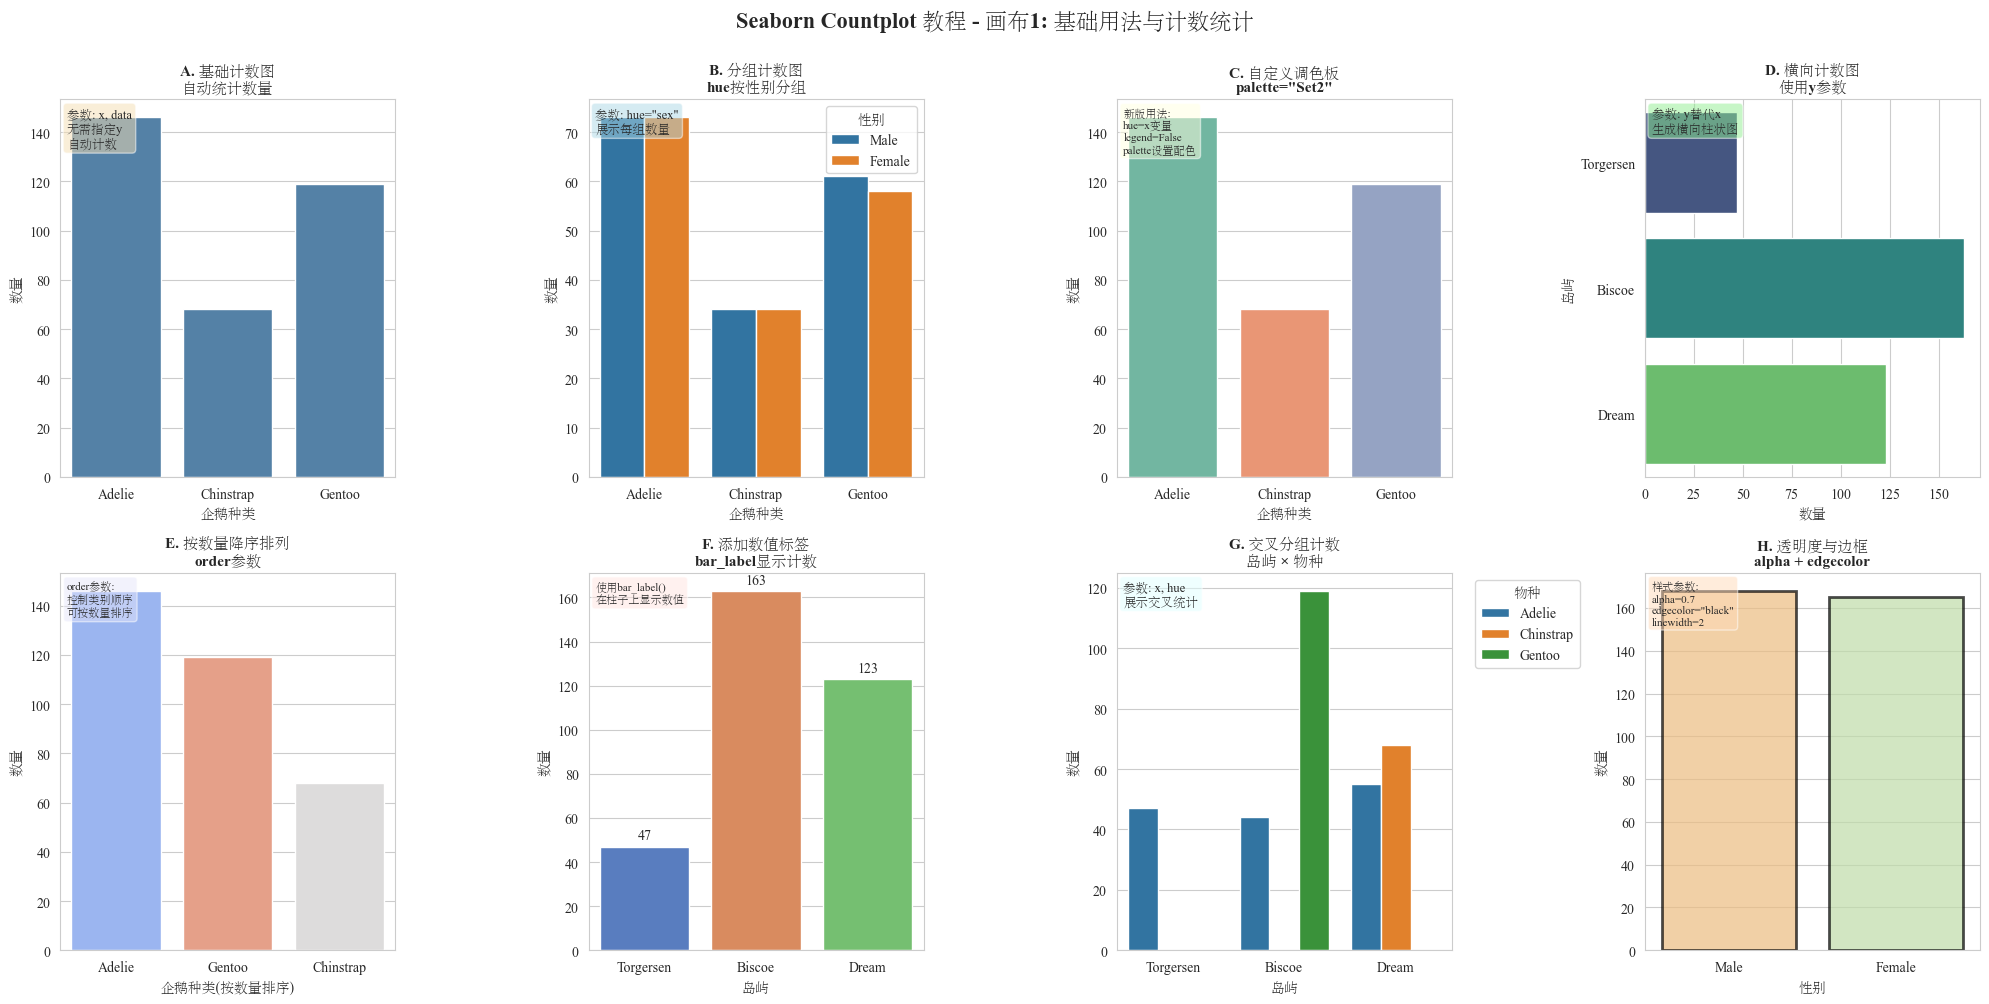

In [4]:
import seaborn as sns  # 导入Seaborn库，用于高级统计图表绘制
import matplotlib.pyplot as plt  # 导入Matplotlib的Pyplot模块，用于基础绘图
import pandas as pd  # 导入Pandas库，用于数据处理和分析
import numpy as np  # 导入NumPy库，用于数值计算

# 加载数据集
penguins = sns.load_dataset('penguins')  # 从Seaborn内置数据集加载企鹅数据集，包含多种企鹅物种的生理测量数据
# 删除缺失值
penguins = penguins.dropna()  # 删除数据集中的所有缺失值行，确保数据完整性

print(f"数据集形状: {penguins.shape}")  # 打印数据集的行数和列数，显示数据规模
print(f"\n各类别数量统计:")  # 打印标题，展示各类别统计
print(penguins['species'].value_counts())  # 打印每种企鹅物种的数量统计
print(penguins['island'].value_counts())  # 打印每个岛屿的企鹅数量统计

plt.rcParams['axes.unicode_minus'] = False  # 禁用负号自动转成中文字符，解决坐标轴负号显示问题
sns.set_style("whitegrid")  # 设置Seaborn绘图样式为白色网格背景，便于数据阅读
plt.rcParams['font.family'] = ['Times New Roman', 'STSong']  # 设置字体优先级：英文用Times New Roman，中文用仿宋

# ============================================================
# 画布 1: 基础用法和常用参数
# ============================================================
fig1, axes1 = plt.subplots(2, 4, figsize=(20, 10))  # 创建2行4列的子图布局，总画布大小20x10英寸
fig1.suptitle('Seaborn Countplot 教程 - 画布1: 基础用法与计数统计',  # 设置整个画布的总标题
              fontsize=16,  # 总标题字体大小16
              fontweight='bold',  # 总标题加粗显示
              y=1.00)  # 总标题垂直位置为画布顶部

# ========== 子图 A：最基础的计数图 ==========
ax = axes1[0, 0]  # 获取第1行第1列的子图对象
sns.countplot(data=penguins, x='species', ax=ax, color='steelblue')  # 绘制基础计数图：x轴为物种，自动统计数量，钢蓝色
ax.set_title('A. 基础计数图\n自动统计数量', fontsize=11, fontweight='bold')  # 设置子图标题，说明自动计数功能，双行显示
ax.set_xlabel('企鹅种类', fontsize=10)  # 设置x轴标签：企鹅种类，字体大小10
ax.set_ylabel('数量', fontsize=10)  # 设置y轴标签：数量，字体大小10
ax.text(0.02,  # 文本水平位置：子图左边距2%
        0.98,  # 文本垂直位置：子图顶部98%
        '参数: x, data\n无需指定y\n自动计数',  # 文本内容：说明countplot核心参数和自动计数特点
        transform=ax.transAxes,  # 使用子图相对坐标系（0-1范围）
        fontsize=9,  # 文本字体大小9
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))  # 添加圆角背景框，浅黄色半透明

# ========== 子图 B：添加hue参数分组计数 ==========
ax = axes1[0, 1]  # 获取第1行第2列的子图对象
sns.countplot(data=penguins, x='species', hue='sex', ax=ax)  # 绘制分组计数图：x轴物种，hue按性别分组，自动配色
ax.set_title('B. 分组计数图\nhue按性别分组', fontsize=11, fontweight='bold')  # 子图标题说明hue分组功能
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('数量', fontsize=10)  # y轴标签
ax.legend(title='性别', loc='upper right')  # 设置图例：标题为"性别"，位置右上角
ax.text(0.02,  # 文本位置
        0.98,
        '参数: hue="sex"\n展示每组数量',  # 说明hue参数用于展示分组数量
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))  # 浅蓝色背景框

# ========== 子图 C：自定义调色板 ==========
ax = axes1[0, 2]  # 获取第1行第3列子图
sns.countplot(data=penguins,  # 数据源
              x='species',  # x轴：物种
              hue='species',  # hue参数：按物种本身分组（每个物种不同颜色）
              palette='Set2',  # 自定义调色板：Set2（柔和色彩）
              legend=False,  # 隐藏图例（因hue=x，图例冗余）
              ax=ax)  # 绘制到当前子图
ax.set_title('C. 自定义调色板\npalette="Set2"', fontsize=11, fontweight='bold')  # 标题说明调色板用法
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('数量', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        '新版用法:\nhue=x变量\nlegend=False\npalette设置配色',  # 说明新版countplot用法要点
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))  # 浅黄色背景框

# ========== 子图 D：横向计数图 ==========
ax = axes1[0, 3]  # 获取第1行第4列子图
sns.countplot(data=penguins,  # 数据源
              y='island',  # y轴：岛屿（使用y参数生成横向柱状图）
              hue='island',  # hue：按岛屿着色
              palette='viridis',  # 调色板：viridis（连续色彩）
              legend=False,  # 隐藏图例
              ax=ax)  # 绘制到当前子图
ax.set_title('D. 横向计数图\n使用y参数', fontsize=11, fontweight='bold')  # 标题说明横向实现方法
ax.set_xlabel('数量', fontsize=10)  # x轴标签：数量
ax.set_ylabel('岛屿', fontsize=10)  # y轴标签：岛屿
ax.text(0.02,  # 文本位置
        0.98,
        '参数: y替代x\n生成横向柱状图',  # 说明横向参数设置
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))  # 浅绿色背景框

# ========== 子图 E：按数量排序 ==========
ax = axes1[1, 0]  # 获取第2行第1列子图
# 计算排序顺序
species_order = penguins['species'].value_counts().index  # 使用value_counts()获取物种数量，按降序返回索引
sns.countplot(data=penguins,  # 数据源
              x='species',  # x轴
              order=species_order,  # order参数：按数量降序排列物种
              hue='species',  # 分组着色
              palette='coolwarm',  # 调色板：冷暖色系
              legend=False,  # 隐藏图例
              ax=ax)  # 绘制
ax.set_title('E. 按数量降序排列\norder参数', fontsize=11, fontweight='bold')  # 标题说明排序功能
ax.set_xlabel('企鹅种类(按数量排序)', fontsize=10)  # x轴标签说明排序依据
ax.set_ylabel('数量', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'order参数:\n控制类别顺序\n可按数量排序',  # 说明order参数用于数量排序
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.5))  # 淡紫色背景框

# ========== 子图 F：添加数值标签 ==========
ax = axes1[1, 1]  # 获取第2行第2列子图
sns.countplot(data=penguins,  # 数据源
              x='island',  # x轴：岛屿
              hue='island',  # 按岛屿分组
              palette='muted',  # 调色板：柔和色彩
              legend=False,  # 隐藏图例
              ax=ax)  # 绘制
ax.set_title('F. 添加数值标签\nbar_label显示计数', fontsize=11, fontweight='bold')  # 标题说明数值标签功能
ax.set_xlabel('岛屿', fontsize=10)  # x轴标签
ax.set_ylabel('数量', fontsize=10)  # y轴标签
# 添加数值标签
for container in ax.containers:  # 遍历所有柱状图容器（每个hue一组）
    ax.bar_label(container, fmt='%d', padding=3)  # 为每个柱子添加整数标签，内边距3点
ax.text(0.02,  # 文本位置
        0.98,
        '使用bar_label()\n在柱子上显示数值',  # 说明数值标签添加方法
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.5))  # 玫瑰色背景框

# ========== 子图 G：多变量交叉计数 ==========
ax = axes1[1, 2]  # 获取第2行第3列子图
sns.countplot(data=penguins, x='island', hue='species', palette='tab10', ax=ax)  # x轴岛屿，hue按物种分组，tab10调色板
ax.set_title('G. 交叉分组计数\n岛屿 × 物种', fontsize=11, fontweight='bold')  # 标题说明交叉分组
ax.set_xlabel('岛屿', fontsize=10)  # x轴标签
ax.set_ylabel('数量', fontsize=10)  # y轴标签
ax.legend(title='物种', bbox_to_anchor=(1.05, 1), loc='upper left')  # 图例移到画布外右侧，节省空间
ax.text(0.02,  # 文本位置
        0.98,
        '参数: x, hue\n展示交叉统计',  # 说明交叉统计参数用法
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.5))  # 浅青色背景框

# ========== 子图 H：透明度和边框 ==========
ax = axes1[1, 3]  # 获取第2行第4列子图
sns.countplot(data=penguins,  # 数据源
              x='sex',  # x轴：性别
              hue='sex',  # 按性别分组
              palette='Spectral',  # 调色板：光谱色
              legend=False,  # 隐藏图例
              ax=ax,  # 绘制目标
              alpha=0.7,  # 设置柱子透明度为70%
              edgecolor='black',  # 设置柱子边框颜色为黑色
              linewidth=2)  # 设置边框线宽为2点
ax.set_title('H. 透明度与边框\nalpha + edgecolor', fontsize=11, fontweight='bold')  # 标题说明样式参数
ax.set_xlabel('性别', fontsize=10)  # x轴标签
ax.set_ylabel('数量', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        '样式参数:\nalpha=0.7\nedgecolor="black"\nlinewidth=2',  # 详细列出三个样式参数
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='peachpuff', alpha=0.5))  # 桃色背景框

plt.tight_layout()  # 自动调整子图间距，避免标题重叠
plt.show()  # 显示整个画布1的所有子图

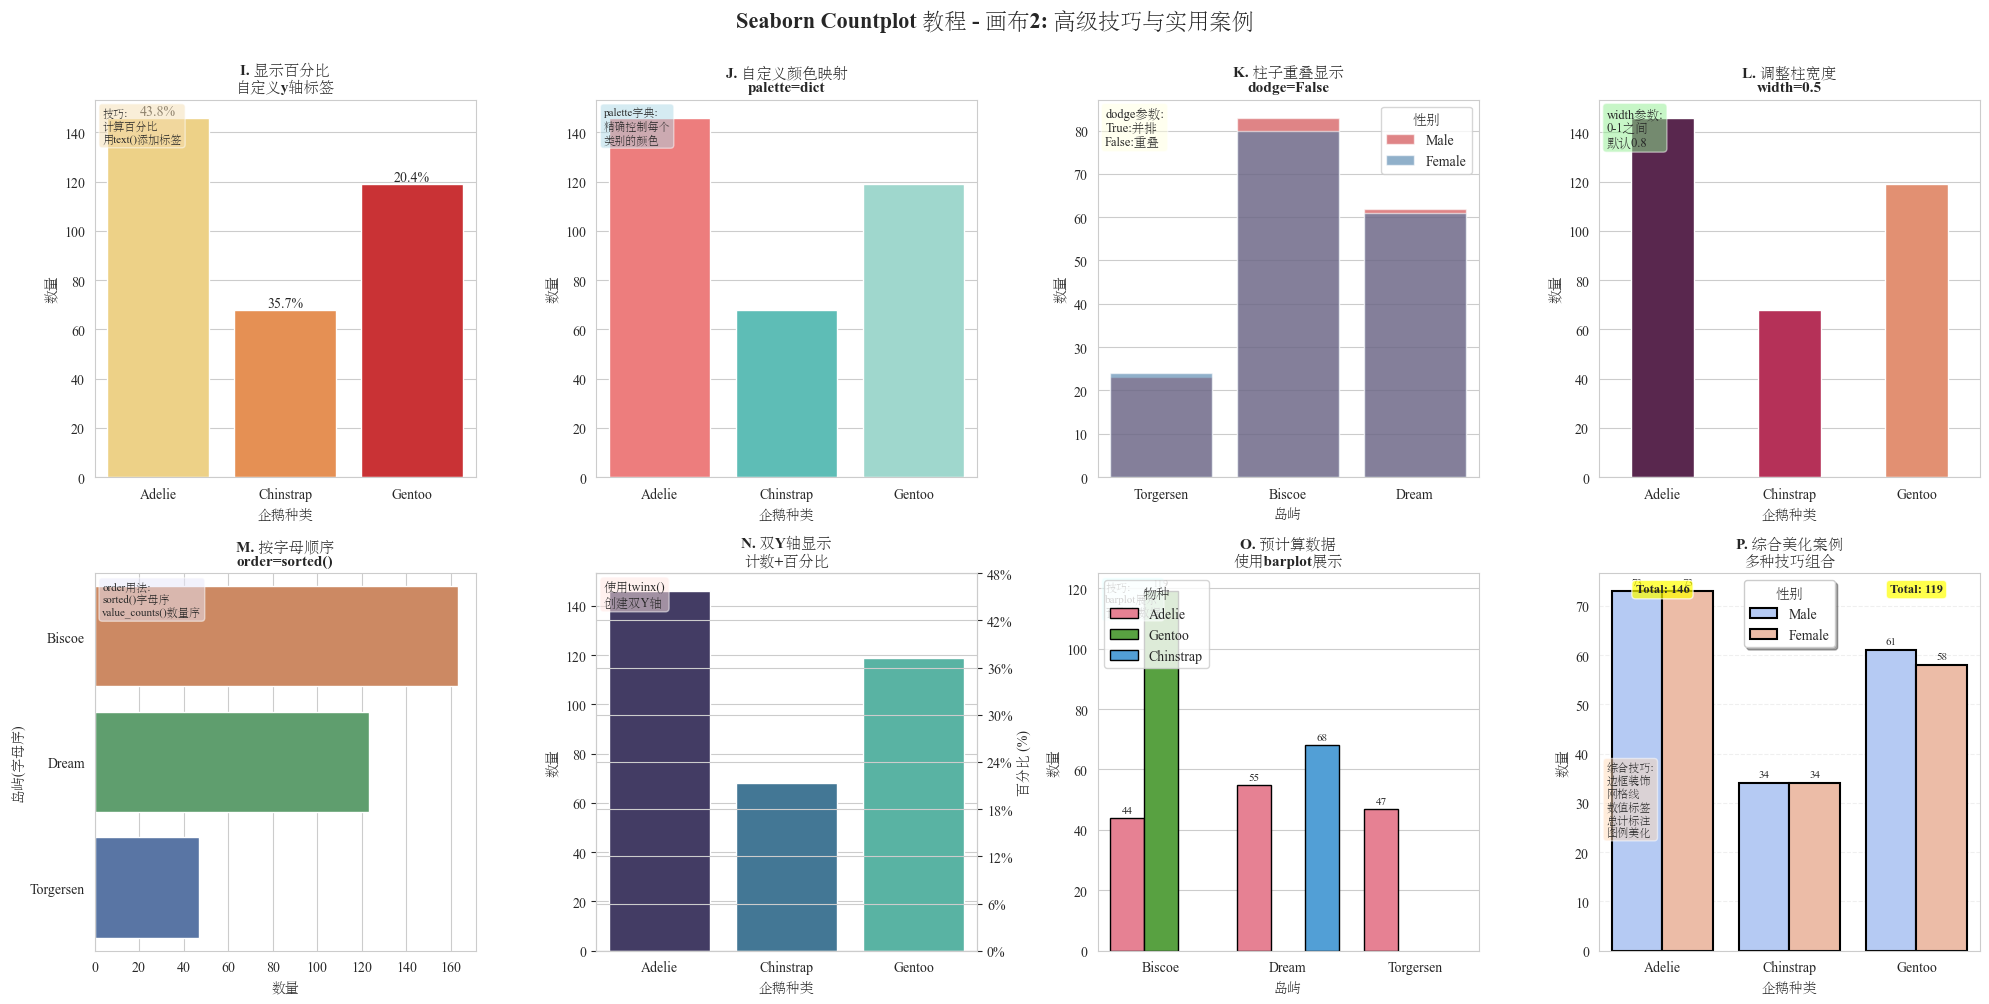

In [5]:
plt.rcParams['font.family'] = ['Times New Roman', 'STsong', 'simhei']  # 设置字体优先级：Times New Roman→仿宋→黑体，确保中英文兼容显示

# ============================================================
# 画布 2: 高级技巧和实用案例
# ============================================================
fig2, axes2 = plt.subplots(2, 4, figsize=(20, 10))  # 创建2行4列子图布局，总画布大小20x10英寸
fig2.suptitle('Seaborn Countplot 教程 - 画布2: 高级技巧与实用案例',  # 设置整个画布的总标题
              fontsize=16,  # 总标题字体大小16
              fontweight='bold',  # 总标题加粗显示
              y=1.00)  # 总标题垂直位置为画布顶部

# ========== 子图 I：显示百分比而非计数 ==========
ax = axes2[0, 0]  # 获取第1行第1列子图对象
# 计算百分比
species_counts = penguins['species'].value_counts()  # 统计每种企鹅物种的数量
species_pct = (species_counts / len(penguins) * 100).round(1)  # 计算百分比：数量/总数*100，保留1位小数
sns.countplot(data=penguins,  # 数据源
              x='species',  # x轴：物种
              hue='species',  # 按物种分组着色
              palette='YlOrRd',  # 黄-橙-红渐变调色板
              legend=False,  # 隐藏图例
              ax=ax)  # 绘制到当前子图
ax.set_title('I. 显示百分比\n自定义y轴标签', fontsize=11, fontweight='bold')  # 子图标题说明百分比显示功能
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('数量', fontsize=10)  # y轴标签（实际显示数量，但标签用百分比）
# 添加百分比标签
for i, (container, species) in enumerate(zip(ax.containers, species_pct.index)):  # 遍历每个容器和对应的物种
    height = container[0].get_height()  # 获取第一个柱子的高度（实际计数值）
    ax.text(i,  # x位置：柱子索引
            height,  # y位置：柱子顶部
            f'{species_pct[species]}%',  # 文本内容：对应物种的百分比
            ha='center',  # 水平居中对齐
            va='bottom',  # 垂直底部对齐
            fontsize=10)  # 字体大小10
ax.text(0.02,  # 文本左边距2%
        0.98,  # 文本顶部98%
        '技巧:\n计算百分比\n用text()添加标签',  # 说明百分比计算和标注技巧
        transform=ax.transAxes,  # 使用相对坐标系
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 顶部对齐
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))  # 圆角浅黄色半透明背景框

# ========== 子图 J：自定义颜色字典 ==========
ax = axes2[0, 1]  # 获取第1行第2列子图对象
custom_colors = {  # 定义自定义颜色字典：物种名→十六进制颜色
    'Adelie': '#FF6B6B',  # 阿德利企鹅：珊瑚红色
    'Chinstrap': '#4ECDC4',  # 帽带企鹅：青绿色
    'Gentoo': '#95E1D3'  # 巴布亚企鹅：浅青色
}
sns.countplot(data=penguins,  # 数据源
              x='species',  # x轴
              hue='species',  # 分组
              palette=custom_colors,  # 使用自定义颜色字典
              legend=False,  # 隐藏图例
              ax=ax)  # 绘制目标
ax.set_title('J. 自定义颜色映射\npalette=dict', fontsize=11, fontweight='bold')  # 标题说明自定义颜色用法
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('数量', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'palette字典:\n精确控制每个\n类别的颜色',  # 说明字典精确控制颜色优势
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))  # 浅蓝色背景框

# ========== 子图 K：堆叠柱状图效果(dodge=False) ==========
ax = axes2[0, 2]  # 获取第1行第3列子图对象
sns.countplot(data=penguins,  # 数据源
              x='island',  # x轴：岛屿
              hue='sex',  # 按性别分组
              dodge=False,  # 关闭dodge，使分组柱重叠（模拟堆叠效果）
              palette='Set1',  # Set1分类调色板
              alpha=0.6,  # 透明度60%
              ax=ax)  # 绘制目标
ax.set_title('K. 柱子重叠显示\ndodge=False', fontsize=11, fontweight='bold')  # 标题说明重叠效果
ax.set_xlabel('岛屿', fontsize=10)  # x轴标签
ax.set_ylabel('数量', fontsize=10)  # y轴标签
ax.legend(title='性别')  # 显示性别图例
ax.text(0.02,  # 文本位置
        0.98,
        'dodge参数:\nTrue:并排\nFalse:重叠',  # 说明dodge参数两种效果
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))  # 浅黄色背景框

# ========== 子图 L：宽度调整 ==========
ax = axes2[0, 3]  # 获取第1行第4列子图对象
sns.countplot(data=penguins,  # 数据源
              x='species',  # x轴
              hue='species',  # 分组
              width=0.5,  # 柱子宽度设为0.5（默认0.8，范围0-1）
              palette='rocket',  # rocket红黑渐变调色板
              legend=False,  # 隐藏图例
              ax=ax)  # 绘制目标
ax.set_title('L. 调整柱宽度\nwidth=0.5', fontsize=11, fontweight='bold')  # 标题说明宽度调整
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('数量', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'width参数:\n0-1之间\n默认0.8',  # 说明width参数范围和默认值
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))  # 浅绿色背景框

# ========== 子图 M：按字母顺序排列 ==========
ax = axes2[1, 0]  # 获取第2行第1列子图对象
island_order = sorted(penguins['island'].unique())  # 获取岛屿唯一值并按字母顺序排序
sns.countplot(data=penguins,  # 数据源
              y='island',  # y轴：岛屿（横向柱状图）
              order=island_order,  # order参数：按字母顺序排列
              hue='island',  # 按岛屿着色
              palette='deep',  # deep深色调色板
              legend=False,  # 隐藏图例
              ax=ax)  # 绘制目标
ax.set_title('M. 按字母顺序\norder=sorted()', fontsize=11, fontweight='bold')  # 标题说明字母排序
ax.set_xlabel('数量', fontsize=10)  # x轴标签：数量
ax.set_ylabel('岛屿(字母序)', fontsize=10)  # y轴标签说明排序依据
ax.text(0.02,  # 文本位置
        0.98,
        'order用法:\nsorted()字母序\nvalue_counts()数量序',  # 说明order参数两种排序方法
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.5))  # 淡紫色背景框

# ========== 子图 N：创建双轴对比图 ==========
ax = axes2[1, 1]  # 获取第2行第2列子图对象
sns.countplot(data=penguins,  # 数据源
              x='species',  # x轴
              hue='species',  # 分组
              palette='mako',  # mako蓝绿渐变调色板
              legend=False,  # 隐藏图例
              ax=ax)  # 绘制目标
ax.set_title('N. 双Y轴显示\n计数+百分比', fontsize=11, fontweight='bold')  # 标题说明双轴功能
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('数量', fontsize=10)  # 左y轴标签：数量
# 添加第二个y轴显示百分比
ax2 = ax.twinx()  # 创建与ax共享x轴的第二个y轴
ax2.set_ylim(0, ax.get_ylim()[1])  # 设置ax2的y轴范围与ax相同（0到最大数量）
ax2.set_ylabel('百分比 (%)', fontsize=10)  # 右y轴标签：百分比
# 计算并设置百分比刻度
total = len(penguins)  # 获取数据集总行数
ax2.set_yticks(ax.get_yticks())  # 设置ax2的刻度位置与ax相同
ax2.set_yticklabels([f'{int(y/total*100)}%' for y in ax.get_yticks()])  # 将刻度标签转换为百分比格式
ax.text(0.02,  # 文本位置
        0.98,
        '使用twinx()\n创建双Y轴',  # 说明双轴创建方法
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.5))  # 玫瑰色背景框

# ========== 子图 O：组合使用：计数+详情标注 ==========
ax = axes2[1, 2]  # 获取第2行第3列子图对象
count_data = penguins.groupby(['island',  # 按岛屿分组
                               'species']).size().reset_index(name='count')  # 统计数量，重置索引，列名为count
# 使用barplot代替countplot来展示预计算的数据
sns.barplot(data=count_data,  # 使用预计算的数据
            x='island',  # x轴：岛屿
            y='count',  # y轴：预计算的计数
            hue='species',  # 按物种分组
            palette='husl',  # husl均匀色彩调色板
            ax=ax,  # 绘制目标
            edgecolor='black',  # 黑色边框
            linewidth=1)  # 边框线宽1点
ax.set_title('O. 预计算数据\n使用barplot展示', fontsize=11, fontweight='bold')  # 标题说明预计算用法
ax.set_xlabel('岛屿', fontsize=10)  # x轴标签
ax.set_ylabel('数量', fontsize=10)  # y轴标签
ax.legend(title='物种', loc='upper left')  # 图例位置左上角
# 添加数值标签
for container in ax.containers:  # 遍历所有柱状容器
    ax.bar_label(container, fmt='%d', padding=2, fontsize=8)  # 添加整数标签，内边距2点，字体8
ax.text(0.02,  # 文本位置
        0.98,
        '技巧:\nbarplot展示\n预聚合数据',  # 说明使用barplot展示预计算数据的技巧
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.5))  # 浅青色背景框

# ========== 子图 P：综合应用 - 精美报表 ==========
ax = axes2[1, 3]  # 获取第2行第4列子图对象
sns.countplot(data=penguins,  # 数据源
              x='species',  # x轴
              hue='sex',  # 按性别分组
              palette='coolwarm',  # 冷暖色系调色板
              ax=ax,  # 绘制目标
              edgecolor='black',  # 黑色边框
              linewidth=1.5)  # 边框线宽1.5点
ax.set_title('P. 综合美化案例\n多种技巧组合', fontsize=11, fontweight='bold')  # 标题说明综合美化
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('数量', fontsize=10)  # y轴标签
ax.legend(title='性别', frameon=True, fancybox=True, shadow=True)  # 美化图例：有边框、圆角、阴影
ax.grid(axis='y', alpha=0.3, linestyle='--')  # y轴虚线网格，透明度30%
# 添加数值标签
for container in ax.containers:  # 遍历所有柱状容器
    ax.bar_label(container, fmt='%d', padding=3, fontsize=8)  # 添加整数标签，内边距3点，字体8
# 添加总计标注
for i, species in enumerate(penguins['species'].unique()):  # 遍历每种物种
    total = len(penguins[penguins['species'] == species])  # 计算该物种总数量
    ax.text(i,  # x位置：物种索引
            ax.get_ylim()[1] * 0.95,  # y位置：y轴最大值的95%
            f'Total: {total}',  # 文本内容：总计数量
            ha='center',  # 水平居中
            fontsize=9,  # 字体大小9
            fontweight='bold',  # 加粗显示
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))  # 黄色圆角背景框，70%透明
ax.text(0.02,  # 文本位置（垂直居中）
        0.50,
        '综合技巧:\n边框装饰\n网格线\n数值标签\n总计标注\n图例美化',  # 总结所有使用的美化技巧
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='peachpuff', alpha=0.5))  # 桃色背景框

plt.tight_layout()  # 自动调整子图间距，避免重叠
plt.show()  # 显示整个画布2的所有子图

In [6]:

# ============================================================
# 额外演示：与value_counts()的对比
# ============================================================
print("\n" + "=" * 60)
print("Countplot vs Pandas value_counts() 对比")
print("=" * 60)

print("\n使用 pandas value_counts():")
print(penguins['species'].value_counts())

print("\n使用 pandas crosstab()进行交叉统计:")
print(pd.crosstab(penguins['island'], penguins['species']))

# ============================================================
# 打印重要参数总结
# ============================================================
print("\n" + "=" * 60)
print("Seaborn countplot 核心参数总结 (v0.13.2+)")
print("=" * 60)
print("""
1. 基础参数:
   - data: 数据源(DataFrame)
   - x 或 y: 要计数的分类变量(只需其一)
   - hue: 分组变量
   - order, hue_order: 控制类别显示顺序

2. 样式参数:
   - palette: 调色板(需配合hue使用)
   - color: 单一颜色(不使用hue时)
   - alpha: 透明度(0-1)
   - width: 柱宽度(0-1)
   - edgecolor, linewidth: 边框样式

3. 布局参数:
   - dodge: 分组柱是否分开(True/False)
   - legend: 是否显示图例(True/False)
   - ax: 指定绘图的axes对象

4. countplot vs barplot:
   - countplot: 自动计数分类变量
   - barplot: 需要指定y值(适合预计算数据)

5. 新版本规范 (v0.13.2+):
   ⚠️ 使用palette时必须指定hue参数
   ✅ 单色: color='颜色名'
   ✅ 彩色: hue=x变量, palette='调色板', legend=False
   ✅ 分组: hue='分组变量', palette='调色板'

6. 常用技巧:
   - 使用value_counts()配合order实现排序
   - bar_label()添加数值标签
   - 结合crosstab()进行交叉分析
   - 计算百分比并用text()标注
   - 使用twinx()创建双Y轴
   - 预聚合数据后用barplot展示

7. 使用场景:
   ✓ 统计分类变量的频数
   ✓ 对比不同组别的数量分布
   ✓ 制作数据探索性报告
   ✓ 快速可视化类别占比
""")


Countplot vs Pandas value_counts() 对比

使用 pandas value_counts():
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

使用 pandas crosstab()进行交叉统计:
species    Adelie  Chinstrap  Gentoo
island                              
Biscoe         44          0     119
Dream          55         68       0
Torgersen      47          0       0

Seaborn countplot 核心参数总结 (v0.13.2+)

1. 基础参数:
   - data: 数据源(DataFrame)
   - x 或 y: 要计数的分类变量(只需其一)
   - hue: 分组变量
   - order, hue_order: 控制类别显示顺序

2. 样式参数:
   - palette: 调色板(需配合hue使用)
   - color: 单一颜色(不使用hue时)
   - alpha: 透明度(0-1)
   - width: 柱宽度(0-1)
   - edgecolor, linewidth: 边框样式

3. 布局参数:
   - dodge: 分组柱是否分开(True/False)
   - legend: 是否显示图例(True/False)
   - ax: 指定绘图的axes对象

4. countplot vs barplot:
   - countplot: 自动计数分类变量
   - barplot: 需要指定y值(适合预计算数据)

5. 新版本规范 (v0.13.2+):
   ⚠️ 使用palette时必须指定hue参数
   ✅ 单色: color='颜色名'
   ✅ 彩色: hue=x变量, palette='调色板', legend=False
   ✅ 分组: hue='分组变量', palette='调色板'

6. 常用技巧:
   - 使用value_c

## 箱线图

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 加载数据集
penguins = sns.load_dataset('penguins')
penguins = penguins.dropna()

print(f"数据集形状: {penguins.shape}")
print(f"\n数值型变量统计:")
print(penguins[['body_mass_g', 'flipper_length_mm',
                'bill_length_mm']].describe())

数据集形状: (333, 7)

数值型变量统计:
       body_mass_g  flipper_length_mm  bill_length_mm
count   333.000000         333.000000      333.000000
mean   4207.057057         200.966967       43.992793
std     805.215802          14.015765        5.468668
min    2700.000000         172.000000       32.100000
25%    3550.000000         190.000000       39.500000
50%    4050.000000         197.000000       44.500000
75%    4775.000000         213.000000       48.600000
max    6300.000000         231.000000       59.600000


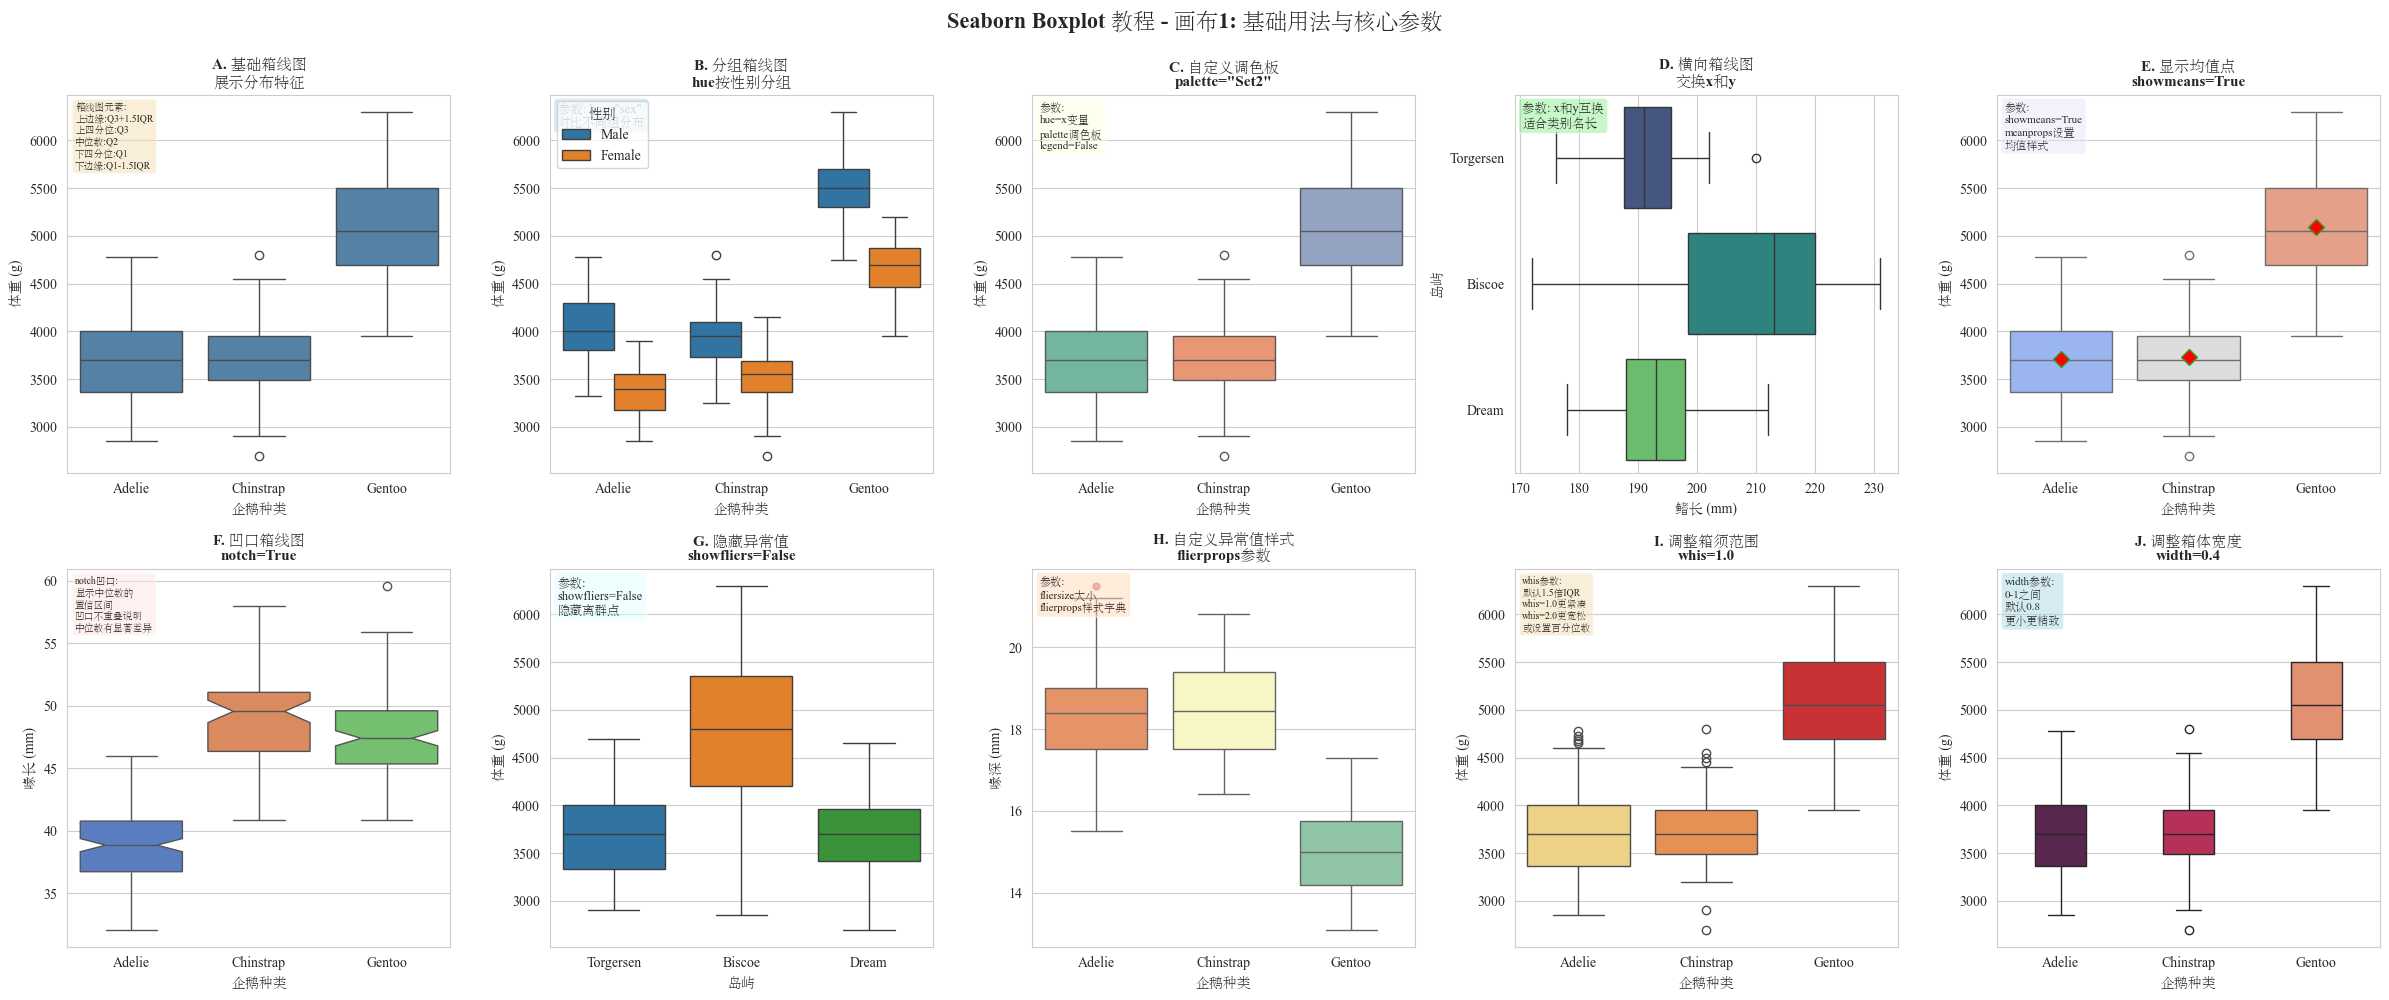

In [8]:
# ============================================================
# 画布 1: 基础用法和核心参数
# ============================================================
fig1, axes1 = plt.subplots(2, 5, figsize=(24, 10))  # 创建2行5列子图布局，总画布大小24x10英寸
fig1.suptitle('Seaborn Boxplot 教程 - 画布1: 基础用法与核心参数',  # 设置整个画布的总标题
              fontsize=16,  # 总标题字体大小16
              fontweight='bold',  # 总标题加粗显示
              y=0.995)  # 总标题垂直位置略低于顶部（避免裁剪）

# ========== 子图 A：最基础的箱线图 ==========
ax = axes1[0, 0]  # 获取第1行第1列子图对象
sns.boxplot(data=penguins,  # 数据源：清洗后的企鹅数据集
            x='species',  # x轴变量：企鹅物种（分类变量）
            y='body_mass_g',  # y轴变量：体重（数值变量）
            ax=ax,  # 指定绘制到当前子图
            color='steelblue')  # 设置单一颜色为钢蓝色
ax.set_title('A. 基础箱线图\n展示分布特征', fontsize=11, fontweight='bold')  # 子图标题说明分布展示功能
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签：企鹅种类
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签：体重（克）
ax.text(0.02,  # 文本水平位置：左边距2%
        0.98,  # 文本垂直位置：顶部98%
        '箱线图元素:\n上边缘:Q3+1.5IQR\n上四分位:Q3\n中位数:Q2\n下四分位:Q1\n下边缘:Q1-1.5IQR',  # 箱线图5大元素及计算公式
        transform=ax.transAxes,  # 使用相对坐标系
        fontsize=7,  # 字体大小7（内容多）
        verticalalignment='top',  # 顶部对齐
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))  # 圆角浅黄色半透明背景框

# ========== 子图 B：添加hue分组 ==========
ax = axes1[0, 1]  # 获取第1行第2列子图对象
sns.boxplot(data=penguins,  # 数据源
            x='species',  # x轴：物种
            y='body_mass_g',  # y轴：体重
            hue='sex',  # hue参数：按性别分组
            ax=ax)  # 绘制到当前子图，自动配色
ax.set_title('B. 分组箱线图\nhue按性别分组', fontsize=11, fontweight='bold')  # 标题说明分组功能
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签
ax.legend(title='性别', loc='upper left')  # 图例：标题"性别"，位置左上角
ax.text(0.02,  # 文本位置
        0.98,
        '参数: hue="sex"\n对比不同组分布',  # 说明hue参数用于组间对比
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))  # 浅蓝色背景框

# ========== 子图 C：自定义调色板 ==========
ax = axes1[0, 2]  # 获取第1行第3列子图对象
sns.boxplot(data=penguins,  # 数据源
            x='species',  # x轴
            y='body_mass_g',  # y轴
            hue='species',  # hue：按物种分组（每个物种不同颜色）
            palette='Set2',  # 调色板：Set2（柔和色彩）
            legend=False,  # 隐藏图例（hue=x冗余）
            ax=ax)  # 绘制目标
ax.set_title('C. 自定义调色板\npalette="Set2"', fontsize=11, fontweight='bold')  # 标题说明调色板用法
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        '参数:\nhue=x变量\npalette调色板\nlegend=False',  # 新版boxplot用法要点
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))  # 浅黄色背景框

# ========== 子图 D：横向箱线图 ==========
ax = axes1[0, 3]  # 获取第1行第4列子图对象
sns.boxplot(data=penguins,  # 数据源
            x='flipper_length_mm',  # x轴：鳍长（数值变量）
            y='island',  # y轴：岛屿（分类变量）-交换实现横向
            hue='island',  # hue：按岛屿着色
            palette='viridis',  # 调色板：viridis（连续色彩）
            legend=False,  # 隐藏图例
            ax=ax)  # 绘制目标
ax.set_title('D. 横向箱线图\n交换x和y', fontsize=11, fontweight='bold')  # 标题说明横向方法
ax.set_xlabel('鳍长 (mm)', fontsize=10)  # x轴标签
ax.set_ylabel('岛屿', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        '参数: x和y互换\n适合类别名长',  # 说明横向适用场景
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))  # 浅绿色背景框

# ========== 子图 E：显示均值 ==========
ax = axes1[0, 4]  # 获取第1行第5列子图对象
sns.boxplot(data=penguins,  # 数据源
            x='species',  # x轴
            y='body_mass_g',  # y轴
            hue='species',  # 分组
            palette='coolwarm',  # 冷暖色系调色板
            legend=False,  # 隐藏图例
            showmeans=True,  # 显示均值点（默认显示中位数）
            meanprops=dict(marker='D',  # 均值标记：菱形
                           markerfacecolor='red',  # 均值填充色：红色
                           markersize=8),  # 均值点大小：8点
            ax=ax)  # 绘制目标
ax.set_title('E. 显示均值点\nshowmeans=True', fontsize=11, fontweight='bold')  # 标题说明均值功能
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        '参数:\nshowmeans=True\nmeanprops设置\n均值样式',  # 说明均值参数
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.5))  # 淡紫色背景框

# ========== 子图 F：凹口箱线图 ==========
ax = axes1[1, 0]  # 获取第2行第1列子图对象
sns.boxplot(data=penguins,  # 数据源
            x='species',  # x轴
            y='bill_length_mm',  # y轴：喙长
            hue='species',  # 分组
            palette='muted',  # 柔和色彩调色板
            legend=False,  # 隐藏图例
            notch=True,  # 中位数处创建凹口（显示置信区间）
            ax=ax)  # 绘制目标
ax.set_title('F. 凹口箱线图\nnotch=True', fontsize=11, fontweight='bold')  # 标题说明凹口功能
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('喙长 (mm)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'notch凹口:\n显示中位数的\n置信区间\n凹口不重叠说明\n中位数有显著差异',  # 凹口统计学意义
        transform=ax.transAxes,
        fontsize=7,  # 字体小（内容多）
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.5))  # 玫瑰色背景框

# ========== 子图 G：隐藏异常值 ==========
ax = axes1[1, 1]  # 获取第2行第2列子图对象
sns.boxplot(data=penguins,  # 数据源
            x='island',  # x轴：岛屿
            y='body_mass_g',  # y轴：体重
            hue='island',  # 分组
            palette='tab10',  # 10色分类调色板
            legend=False,  # 隐藏图例
            showfliers=False,  # 隐藏异常值点
            ax=ax)  # 绘制目标
ax.set_title('G. 隐藏异常值\nshowfliers=False', fontsize=11, fontweight='bold')  # 标题说明隐藏功能
ax.set_xlabel('岛屿', fontsize=10)  # x轴标签
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        '参数:\nshowfliers=False\n隐藏离群点',  # 说明隐藏参数
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.5))  # 浅青色背景框

# ========== 子图 H：调整异常值样式 ==========
ax = axes1[1, 2]  # 获取第2行第3列子图对象
sns.boxplot(data=penguins,  # 数据源
            x='species',  # x轴
            y='bill_depth_mm',  # y轴：喙深
            hue='species',  # 分组
            palette='Spectral',  # 光谱色调色板
            legend=False,  # 隐藏图例
            fliersize=8,  # 异常值默认大小：8点
            flierprops=dict(marker='o',  # 异常值形状：圆形
                            markerfacecolor='red',  # 异常值填充：红色
                            markersize=5,  # 异常值大小：5点
                            alpha=0.5),  # 异常值透明度：50%
            ax=ax)  # 绘制目标
ax.set_title('H. 自定义异常值样式\nflierprops参数', fontsize=11, fontweight='bold')  # 标题说明自定义
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('喙深 (mm)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        '参数:\nfliersize大小\nflierprops样式字典',  # 说明异常值参数
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='peachpuff', alpha=0.5))  # 桃色背景框

# ========== 子图 I：调整箱须范围whis ==========
ax = axes1[1, 3]  # 获取第2行第4列子图对象
sns.boxplot(data=penguins,  # 数据源
            x='species',  # x轴
            y='body_mass_g',  # y轴
            hue='species',  # 分组
            palette='YlOrRd',  # 黄-橙-红渐变调色板
            legend=False,  # 隐藏图例
            whis=1.0,  # 箱须范围：1.0倍IQR（默认1.5）
            ax=ax)  # 绘制目标
ax.set_title('I. 调整箱须范围\nwhis=1.0', fontsize=11, fontweight='bold')  # 标题说明箱须调整
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'whis参数:\n默认1.5倍IQR\nwhis=1.0更紧凑\nwhis=2.0更宽松\n或设置百分位数',  # whis参数详解
        transform=ax.transAxes,
        fontsize=7,  # 字体小（内容多）
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))  # 浅黄色背景框

# ========== 子图 J：调整箱体宽度 ==========
ax = axes1[1, 4]  # 获取第2行第5列子图对象
sns.boxplot(data=penguins,  # 数据源
            x='species',  # x轴
            y='body_mass_g',  # y轴
            hue='species',  # 分组
            palette='rocket',  # rocket红黑渐变调色板
            legend=False,  # 隐藏图例
            width=0.4,  # 箱体宽度：0.4（默认0.8）
            ax=ax)  # 绘制目标
ax.set_title('J. 调整箱体宽度\nwidth=0.4', fontsize=11, fontweight='bold')  # 标题说明宽度调整
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'width参数:\n0-1之间\n默认0.8\n更小更精致',  # width参数说明
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))  # 浅蓝色背景框

plt.tight_layout()  # 自动调整子图间距，避免重叠
plt.show()  # 显示画布1的10个子图

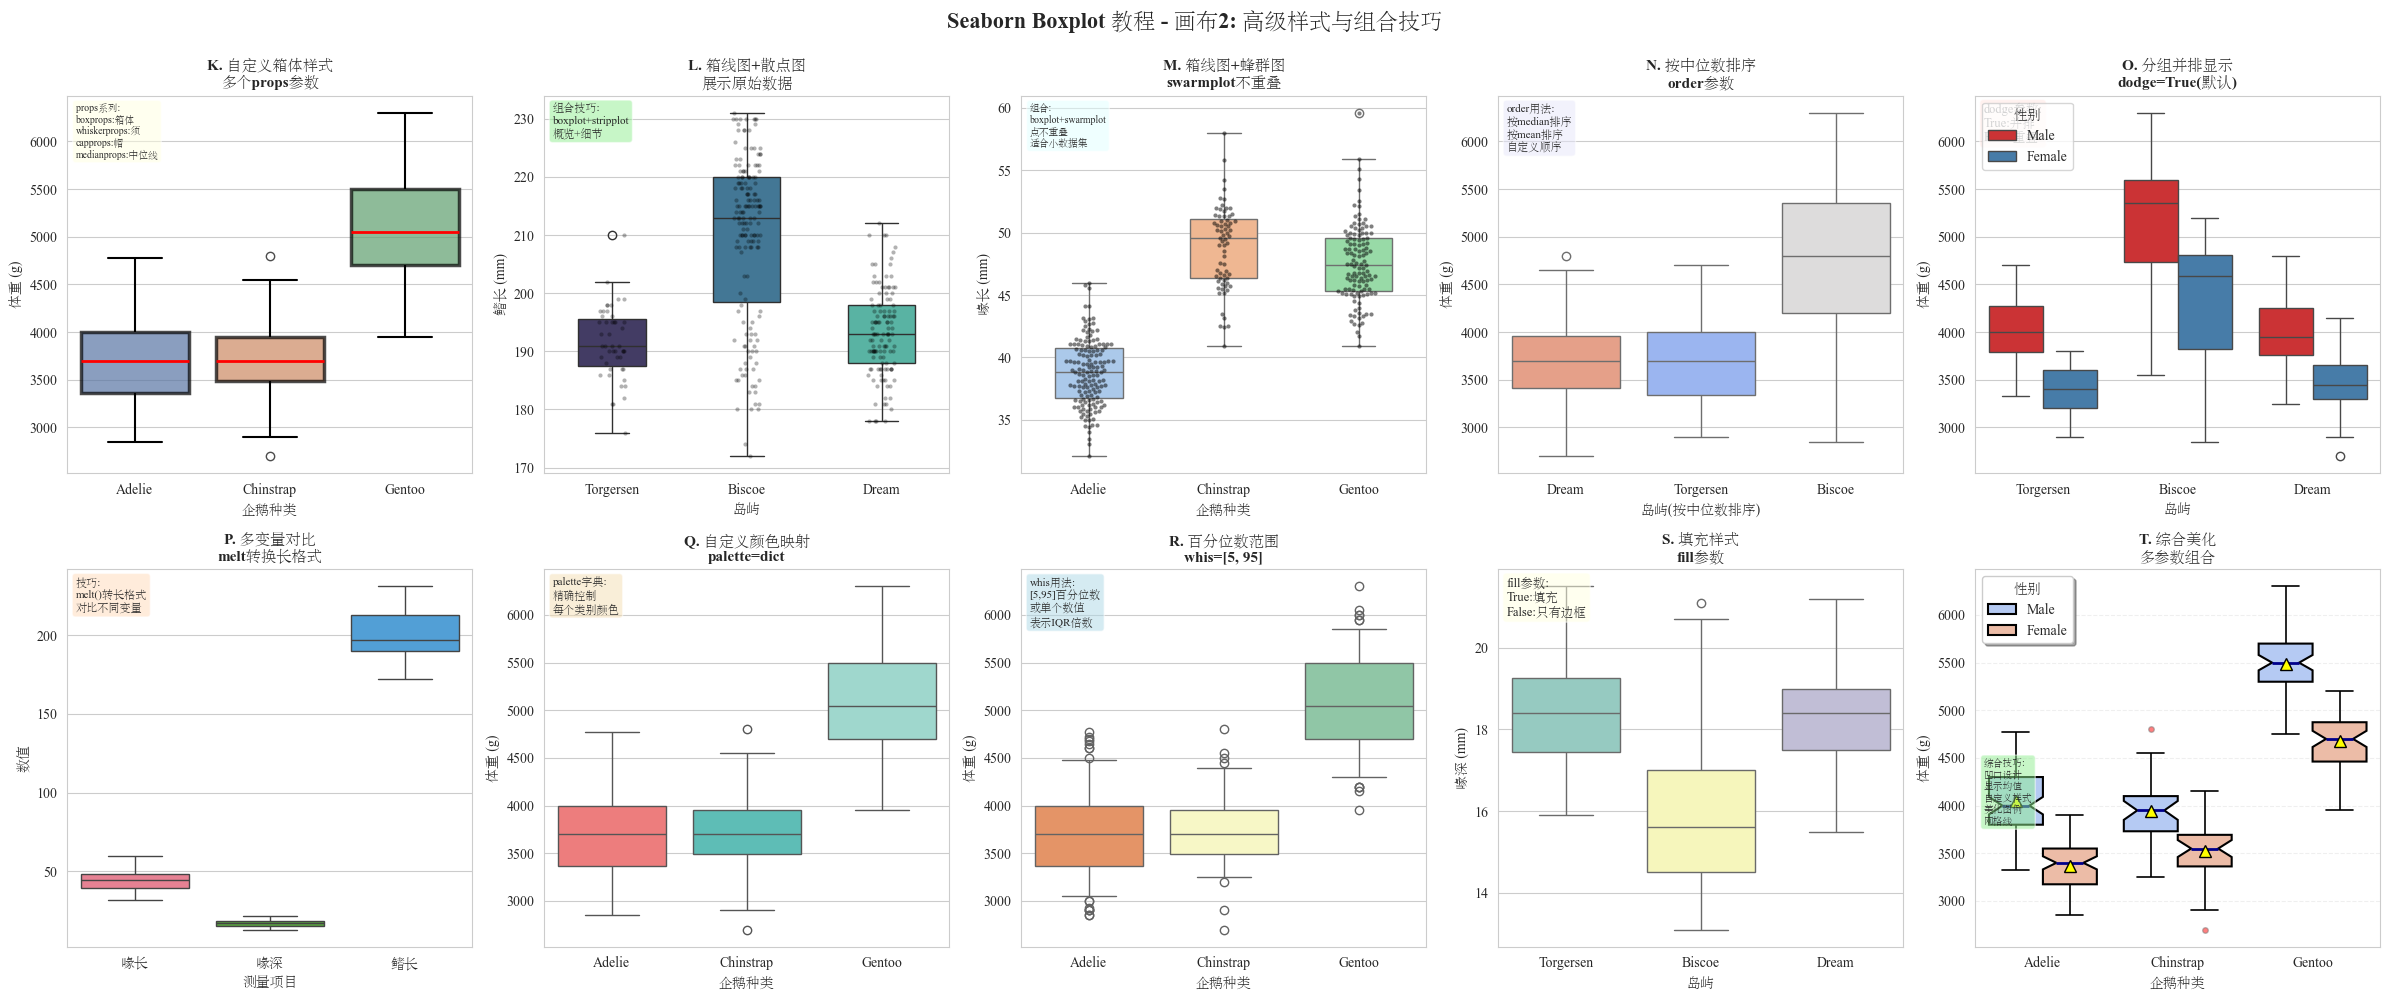

In [9]:
# ============================================================
# 画布 2: 高级样式和组合技巧
# ============================================================
fig2, axes2 = plt.subplots(2, 5, figsize=(24, 10))  # 创建2行5列子图布局，总画布大小24x10英寸
fig2.suptitle('Seaborn Boxplot 教程 - 画布2: 高级样式与组合技巧',  # 设置整个画布的总标题
              fontsize=16,  # 总标题字体大小16
              fontweight='bold',  # 总标题加粗显示
              y=0.995)  # 总标题垂直位置略低于顶部（避免裁剪）

# ========== 子图 K：自定义箱体样式 ==========
ax = axes2[0, 0]  # 获取第1行第1列子图对象
sns.boxplot(data=penguins,  # 数据源
            x='species',  # x轴：物种
            y='body_mass_g',  # y轴：体重
            hue='species',  # 分组：按物种着色
            palette='deep',  # deep深色调色板
            legend=False,  # 隐藏图例
            linewidth=2.5,  # 所有线条默认宽度2.5点
            ax=ax,  # 绘制目标
            boxprops=dict(alpha=0.7,  # 箱体透明度70%
                          edgecolor='black'),  # 箱体边框：黑色
            whiskerprops=dict(color='black',  # 箱须颜色：黑色
                              linewidth=1.5),  # 箱须线宽：1.5点
            capprops=dict(color='black',  # 箱须端帽颜色：黑色
                          linewidth=1.5),  # 端帽线宽：1.5点
            medianprops=dict(color='red',  # 中位数线颜色：红色
                             linewidth=2))  # 中位数线宽：2点
ax.set_title('K. 自定义箱体样式\n多个props参数', fontsize=11, fontweight='bold')  # 标题说明自定义样式
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'props系列:\nboxprops:箱体\nwhiskerprops:须\ncapprops:帽\nmedianprops:中位线',  # 4大props参数说明
        transform=ax.transAxes,
        fontsize=7,  # 字体小（内容多）
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))  # 浅黄色背景框

# ========== 子图 L：箱线图+散点图 ==========
ax = axes2[0, 1]  # 获取第1行第2列子图对象
sns.boxplot(data=penguins,  # 数据源
            x='island',  # x轴：岛屿
            y='flipper_length_mm',  # y轴：鳍长
            hue='island',  # 分组：按岛屿着色
            palette='mako',  # mako蓝绿渐变调色板
            legend=False,  # 隐藏图例
            width=0.5,  # 箱体宽度：0.5
            ax=ax)  # 绘制箱线图
sns.stripplot(data=penguins,  # 数据源
              x='island',  # x轴：岛屿
              y='flipper_length_mm',  # y轴：鳍长
              color='black',  # 散点颜色：黑色
              alpha=0.3,  # 散点透明度30%
              size=3,  # 散点大小：3点
              ax=ax)  # 叠加到同一子图
ax.set_title('L. 箱线图+散点图\n展示原始数据', fontsize=11, fontweight='bold')  # 标题说明组合效果
ax.set_xlabel('岛屿', fontsize=10)  # x轴标签
ax.set_ylabel('鳍长 (mm)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        '组合技巧:\nboxplot+stripplot\n概览+细节',  # 说明组合优势
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))  # 浅绿色背景框

# ========== 子图 M：箱线图+蜂群图 ==========
ax = axes2[0, 2]  # 获取第1行第3列子图对象
sns.boxplot(data=penguins,  # 数据源
            x='species',  # x轴：物种
            y='bill_length_mm',  # y轴：喙长
            hue='species',  # 分组
            palette='pastel',  # 柔和色彩调色板
            legend=False,  # 隐藏图例
            width=0.5,  # 箱体宽度：0.5
            ax=ax)  # 绘制箱线图
sns.swarmplot(data=penguins,  # 数据源
              x='species',  # x轴：物种
              y='bill_length_mm',  # y轴：喙长
              color='black',  # 蜂群点颜色：黑色
              alpha=0.5,  # 透明度50%
              size=3,  # 点大小：3点
              ax=ax)  # 叠加蜂群图（点不重叠）
ax.set_title('M. 箱线图+蜂群图\nswarmplot不重叠', fontsize=11, fontweight='bold')  # 标题说明蜂群特点
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('喙长 (mm)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        '组合:\nboxplot+swarmplot\n点不重叠\n适合小数据集',  # 说明适用场景
        transform=ax.transAxes,
        fontsize=7,  # 字体小（内容多）
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.5))  # 浅青色背景框

# ========== 子图 N：按中位数排序 ==========
ax = axes2[0, 3]  # 获取第1行第4列子图对象
# 计算中位数排序
island_order = penguins.groupby('island')['body_mass_g'].median().sort_values().index  # 按岛屿分组，计算体重中位数，升序排序，返回索引
sns.boxplot(data=penguins,  # 数据源
            x='island',  # x轴：岛屿
            y='body_mass_g',  # y轴：体重
            order=island_order,  # order参数：按中位数排序
            hue='island',  # 分组
            palette='coolwarm',  # 冷暖色系调色板
            legend=False,  # 隐藏图例
            ax=ax)  # 绘制目标
ax.set_title('N. 按中位数排序\norder参数', fontsize=11, fontweight='bold')  # 标题说明排序依据
ax.set_xlabel('岛屿(按中位数排序)', fontsize=10)  # x轴标签说明排序方法
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'order用法:\n按median排序\n按mean排序\n自定义顺序',  # 说明order多种排序方法
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.5))  # 淡紫色背景框

# ========== 子图 O：dodge控制分组位置 ==========
ax = axes2[0, 4]  # 获取第1行第5列子图对象
sns.boxplot(data=penguins,  # 数据源
            x='island',  # x轴：岛屿
            y='body_mass_g',  # y轴：体重
            hue='sex',  # 分组：按性别
            dodge=True,  # dodge=True：分组并排显示（默认）
            palette='Set1',  # Set1分类调色板
            ax=ax)  # 绘制目标
ax.set_title('O. 分组并排显示\ndodge=True(默认)', fontsize=11, fontweight='bold')  # 标题说明并排效果
ax.set_xlabel('岛屿', fontsize=10)  # x轴标签
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签
ax.legend(title='性别', loc='upper left')  # 图例：性别，左上角
ax.text(0.02,  # 文本位置
        0.98,
        'dodge参数:\nTrue:并排\nFalse:重叠',  # 说明dodge两种效果
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.5))  # 玫瑰色背景框

# ========== 子图 P：多个变量对比 ==========
ax = axes2[1, 0]  # 获取第2行第1列子图对象
# 准备数据：选择数值列
numeric_data = penguins[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']].copy()  # 选择3个数值列
numeric_data.columns = ['喙长', '喙深', '鳍长']  # 重命名列为中文
# 转换为长格式
melted = numeric_data.melt(var_name='测量项', value_name='数值')  # melt()：宽格式→长格式，var_name=变量名列，value_name=数值列
sns.boxplot(data=melted,  # 长格式数据
            x='测量项',  # x轴：测量项目
            y='数值',  # y轴：测量数值
            hue='测量项',  # 分组：按测量项目着色
            palette='husl',  # husl均匀色彩调色板
            legend=False,  # 隐藏图例
            ax=ax)  # 绘制目标
ax.set_title('P. 多变量对比\nmelt转换长格式', fontsize=11, fontweight='bold')  # 标题说明数据转换
ax.set_xlabel('测量项目', fontsize=10)  # x轴标签
ax.set_ylabel('数值', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        '技巧:\nmelt()转长格式\n对比不同变量',  # 说明melt()技巧
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='peachpuff', alpha=0.5))  # 桃色背景框

# ========== 子图 Q：自定义颜色字典 ==========
ax = axes2[1, 1]  # 获取第2行第2列子图对象
custom_colors = {  # 自定义颜色字典：物种→十六进制颜色
    'Adelie': '#FF6B6B',  # 阿德利企鹅：珊瑚红
    'Chinstrap': '#4ECDC4',  # 帽带企鹅：青绿色
    'Gentoo': '#95E1D3'  # 巴布亚企鹅：浅青色
}
sns.boxplot(data=penguins,  # 数据源
            x='species',  # x轴
            y='body_mass_g',  # y轴
            hue='species',  # 分组
            palette=custom_colors,  # 使用自定义颜色字典
            legend=False,  # 隐藏图例
            ax=ax)  # 绘制目标
ax.set_title('Q. 自定义颜色映射\npalette=dict', fontsize=11, fontweight='bold')  # 标题说明字典用法
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'palette字典:\n精确控制\n每个类别颜色',  # 说明字典精确控制优势
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))  # 浅黄色背景框

# ========== 子图 R：设置百分位数范围 ==========
ax = axes2[1, 2]  # 获取第2行第3列子图对象
sns.boxplot(data=penguins,  # 数据源
            x='species',  # x轴
            y='body_mass_g',  # y轴
            hue='species',  # 分组
            palette='Spectral',  # 光谱色调色板
            legend=False,  # 隐藏图例
            whis=[5, 95],  # whis=[5,95]：箱须为5%-95%百分位数
            ax=ax)  # 绘制目标
ax.set_title('R. 百分位数范围\nwhis=[5, 95]', fontsize=11, fontweight='bold')  # 标题说明百分位用法
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'whis用法:\n[5,95]百分位数\n或单个数值\n表示IQR倍数',  # whis两种用法说明
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))  # 浅蓝色背景框

# ========== 子图 S：填充样式和透明度 ==========
ax = axes2[1, 3]  # 获取第2行第4列子图对象
sns.boxplot(data=penguins,  # 数据源
            x='island',  # x轴：岛屿
            y='bill_depth_mm',  # y轴：喙深
            hue='island',  # 分组
            palette='Set3',  # Set3分类调色板
            legend=False,  # 隐藏图例
            fill=True,  # fill=True：填充箱体（默认）
            ax=ax)  # 绘制目标
ax.set_title('S. 填充样式\nfill参数', fontsize=11, fontweight='bold')  # 标题说明填充功能
ax.set_xlabel('岛屿', fontsize=10)  # x轴标签
ax.set_ylabel('喙深 (mm)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'fill参数:\nTrue:填充\nFalse:只有边框',  # 说明fill参数效果
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))  # 浅黄色背景框

# ========== 子图 T：综合应用 ==========
ax = axes2[1, 4]  # 获取第2行第5列子图对象
sns.boxplot(data=penguins,  # 数据源
            x='species',  # x轴：物种
            y='body_mass_g',  # y轴：体重
            hue='sex',  # 分组：性别
            palette='coolwarm',  # 冷暖色系调色板
            ax=ax,  # 绘制目标
            notch=True,  # 凹口中位数置信区间
            showmeans=True,  # 显示均值点
            meanprops=dict(marker='^',  # 均值标记：三角形
                           markerfacecolor='yellow',  # 均值填充：黄色
                           markeredgecolor='black',  # 均值边框：黑色
                           markersize=8),  # 均值大小：8点
            boxprops=dict(edgecolor='black',  # 箱体边框：黑色
                          linewidth=1.5),  # 箱体线宽：1.5点
            medianprops=dict(color='darkblue',  # 中位数线：深蓝色
                             linewidth=2),  # 中位数线宽：2点
            whiskerprops=dict(color='black',  # 箱须：黑色
                              linewidth=1.2),  # 箱须线宽：1.2点
            capprops=dict(color='black',  # 端帽：黑色
                          linewidth=1.2),  # 端帽线宽：1.2点
            flierprops=dict(marker='o',  # 异常值：圆形
                            markerfacecolor='red',  # 异常值填充：红色
                            markersize=4,  # 异常值大小：4点
                            alpha=0.5))  # 异常值透明度：50%
ax.set_title('T. 综合美化\n多参数组合', fontsize=11, fontweight='bold')  # 标题说明综合应用
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签
ax.legend(title='性别', frameon=True, fancybox=True, shadow=True)  # 美化图例：边框、圆角、阴影
ax.grid(axis='y', alpha=0.3, linestyle='--')  # y轴虚线网格，透明度30%
ax.text(0.02,  # 文本位置（垂直居中）
        0.50,
        '综合技巧:\n凹口设计\n显示均值\n自定义样式\n美化图例\n网格线',  # 总结5大美化技巧
        transform=ax.transAxes,
        fontsize=7,  # 字体小（内容多）
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))  # 浅绿色背景框

plt.tight_layout()  # 自动调整子图间距，避免重叠
plt.show()  # 显示画布2的10个子图

In [ ]:

# ============================================================
# 箱线图元素说明
# ============================================================
print("\n" + "=" * 60)
print("箱线图(Boxplot)元素解读")
print("=" * 60)
print("""
箱线图的五个关键数值（五数概括）:
1. 最小值: Q1 - 1.5×IQR (不含异常值)
2. 下四分位数 Q1: 25%分位数
3. 中位数 Q2: 50%分位数
4. 上四分位数 Q3: 75%分位数  
5. 最大值: Q3 + 1.5×IQR (不含异常值)

其中 IQR = Q3 - Q1 (四分位距)

异常值定义:
- 小于 Q1 - 1.5×IQR 的点
- 大于 Q3 + 1.5×IQR 的点
""")

# ============================================================
# 打印重要参数总结
# ============================================================
print("\n" + "=" * 60)
print("Seaborn boxplot 核心参数总结 (v0.13.2+)")
print("=" * 60)
print("""
1. 基础参数:
   - data: 数据源(DataFrame)
   - x, y: 坐标轴变量
   - hue: 分组变量
   - order, hue_order: 控制显示顺序

2. 箱体控制:
   - width: 箱体宽度(0-1，默认0.8)
   - notch: 凹口显示(True/False)
   - showmeans: 显示均值点(True/False)
   - showfliers: 显示异常值(True/False，默认True)

3. 统计参数:
   - whis: 箱须范围
     * 数值: IQR倍数(默认1.5)
     * 列表: [下百分位, 上百分位]，如[5, 95]



5. 颜色参数:
   - palette: 调色板(需配合hue)
   - color: 单一颜色
   - fill: 是否填充(True/False)

6. 布局参数:
   - dodge: 分组是否并排(True/False)
   - legend: 是否显示图例
   - linewidth: 全局线宽

7. 常用组合技巧:
   - boxplot + stripplot: 展示分布+原始数据
   - boxplot + swarmplot: 不重叠点图(小数据集)
   - 使用melt()对比多个数值变量
   - 使用order按统计量排序

8. 使用场景:
   ✓ 对比多组数据的分布特征
   ✓ 识别异常值
   ✓ 查看数据的对称性和偏态
   ✓ 比较中位数和四分位数
   ✓ 评估数据的离散程度
""")


箱线图(Boxplot)元素解读

箱线图的五个关键数值（五数概括）:
1. 最小值: Q1 - 1.5×IQR (不含异常值)
2. 下四分位数 Q1: 25%分位数
3. 中位数 Q2: 50%分位数
4. 上四分位数 Q3: 75%分位数  
5. 最大值: Q3 + 1.5×IQR (不含异常值)

其中 IQR = Q3 - Q1 (四分位距)

异常值定义:
- 小于 Q1 - 1.5×IQR 的点
- 大于 Q3 + 1.5×IQR 的点


Seaborn boxplot 核心参数总结 (v0.13.2+)

1. 基础参数:
   - data: 数据源(DataFrame)
   - x, y: 坐标轴变量
   - hue: 分组变量
   - order, hue_order: 控制显示顺序

2. 箱体控制:
   - width: 箱体宽度(0-1，默认0.8)
   - notch: 凹口显示(True/False)
   - showmeans: 显示均值点(True/False)
   - showfliers: 显示异常值(True/False，默认True)

3. 统计参数:
   - whis: 箱须范围
     * 数值: IQR倍数(默认1.5)
     * 列表: [下百分位, 上百分位]，如[5, 95]

4. 样式参数(props系列):
   - boxprops: 箱体样式字典
   - whiskerprops: 箱须样式字典
   - capprops: 箱须端点样式字典
   - medianprops: 中位线样式字典
   - meanprops: 均值点样式字典
   - flierprops: 异常值样式字典

5. 颜色参数:
   - palette: 调色板(需配合hue)
   - color: 单一颜色
   - fill: 是否填充(True/False)

6. 布局参数:
   - dodge: 分组是否并排(True/False)
   - legend: 是否显示图例
   - linewidth: 全局线宽

7. 常用组合技巧:
   - boxplot + stripplot: 展示分布+原始数据
   - boxplot + swarmplot: 不重叠点图(小

## 小提琴图

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# 加载多个数据集
penguins = sns.load_dataset('penguins').dropna()
tips = sns.load_dataset('tips')
iris = sns.load_dataset('iris')

print(f"Penguins数据集形状: {penguins.shape}")
print(f"Tips数据集形状: {tips.shape}")

Penguins数据集形状: (333, 7)
Tips数据集形状: (244, 7)


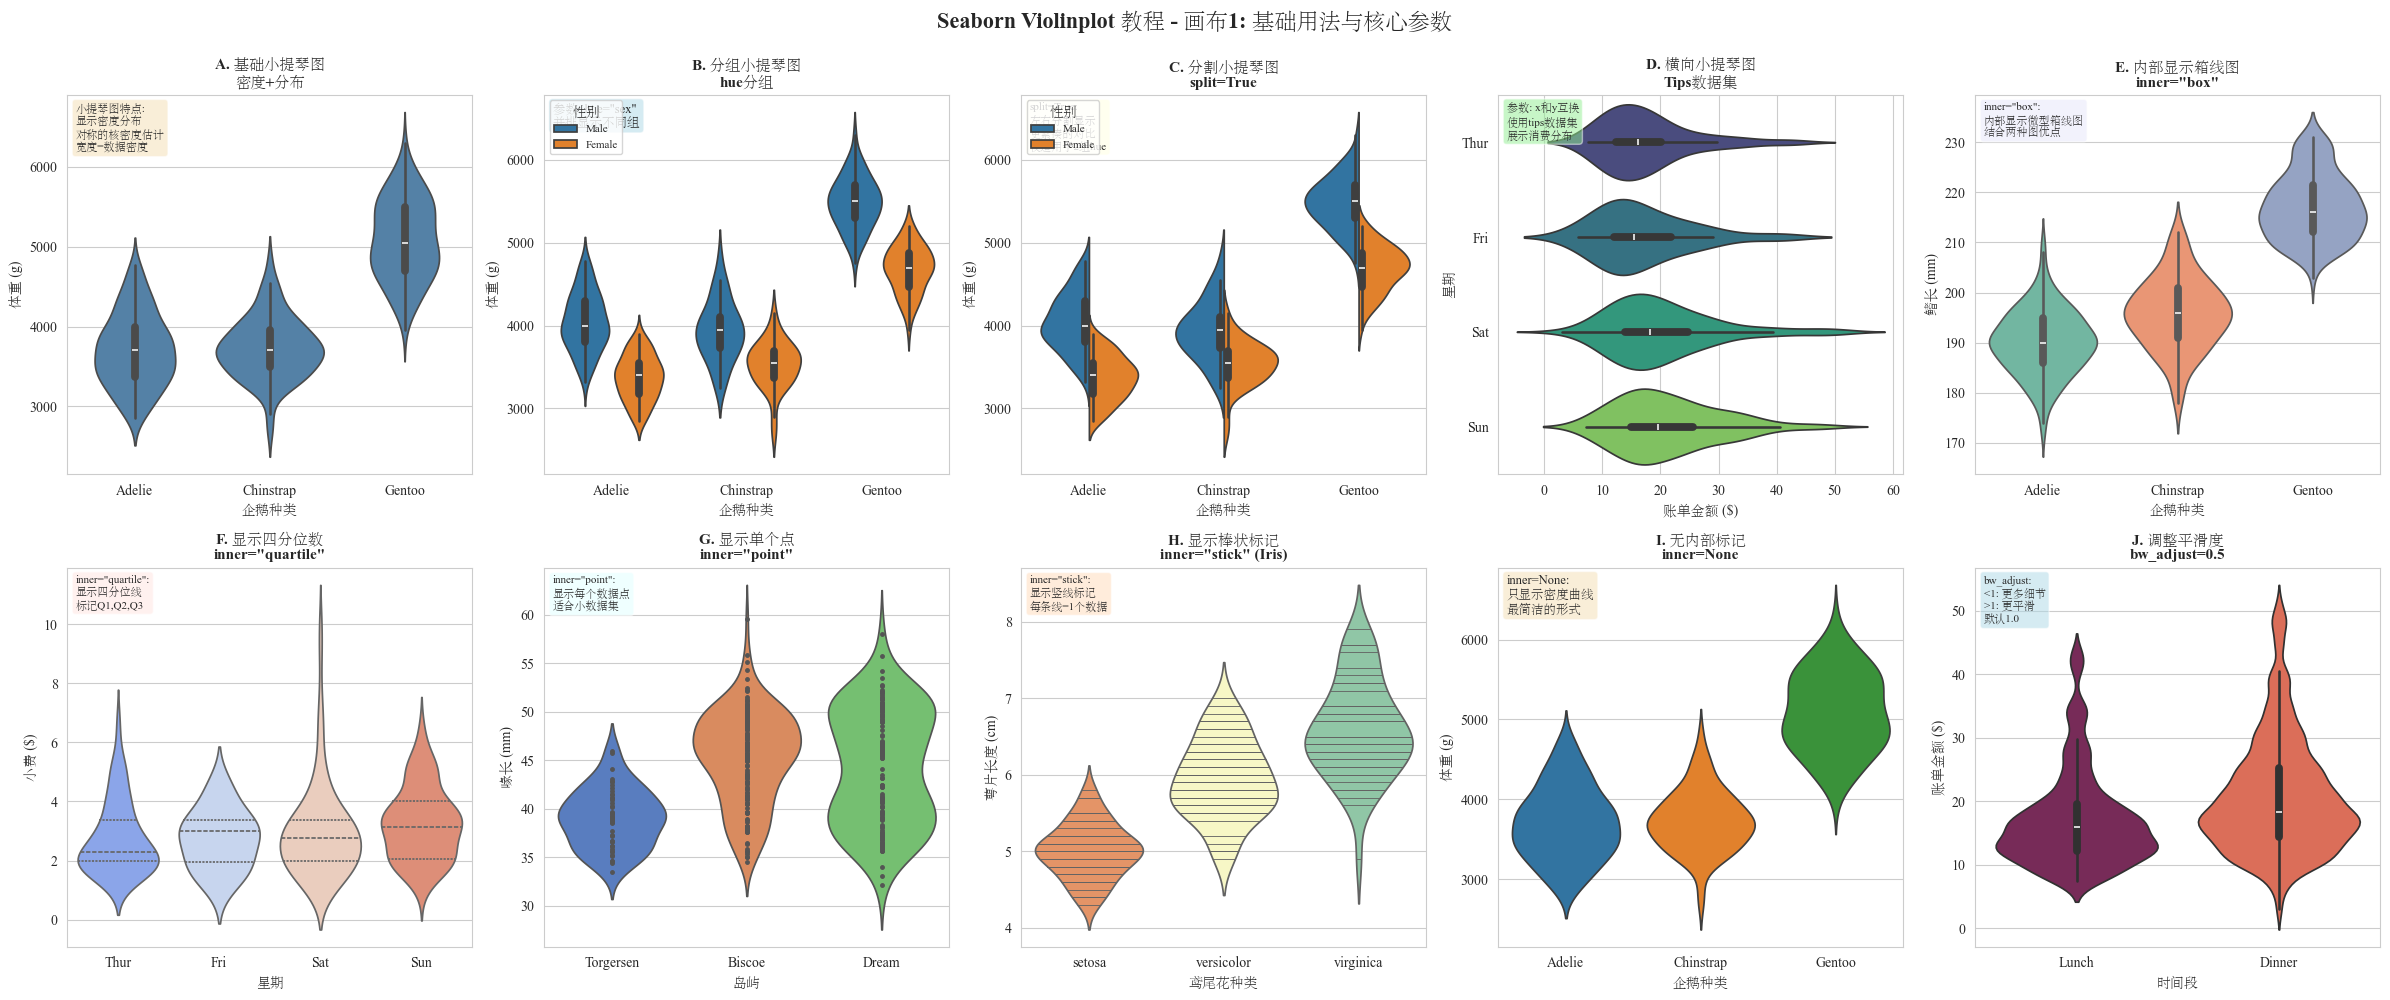

In [13]:
# ============================================================
# 画布 1: 基础用法和核心参数
# ============================================================
fig1, axes1 = plt.subplots(2, 5, figsize=(24, 10))  # 创建2行5列子图布局，总画布大小24x10英寸
fig1.suptitle('Seaborn Violinplot 教程 - 画布1: 基础用法与核心参数',  # 设置整个画布的总标题
              fontsize=16,  # 总标题字体大小16
              fontweight='bold',  # 总标题加粗显示
              y=0.995)  # 总标题垂直位置略低于顶部（避免裁剪）

# ========== 子图 A：最基础的小提琴图 ==========
ax = axes1[0, 0]  # 获取第1行第1列子图对象
sns.violinplot(data=penguins,  # 数据源：企鹅数据集
               x='species',  # x轴：企鹅物种（分类变量）
               y='body_mass_g',  # y轴：体重（数值变量）
               ax=ax,  # 指定绘制到当前子图
               color='steelblue')  # 设置单一颜色为钢蓝色
ax.set_title('A. 基础小提琴图\n密度+分布', fontsize=11, fontweight='bold')  # 子图标题说明密度分布功能
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签：企鹅种类
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签：体重（克）
ax.text(0.02,  # 文本水平位置：左边距2%
        0.98,  # 文本垂直位置：顶部98%
        '小提琴图特点:\n显示密度分布\n对称的核密度估计\n宽度=数据密度',  # 详细说明小提琴图核心特点
        transform=ax.transAxes,  # 使用相对坐标系
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 顶部对齐
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))  # 圆角浅黄色半透明背景框

# ========== 子图 B：添加hue分组 ==========
ax = axes1[0, 1]  # 获取第1行第2列子图对象
sns.violinplot(data=penguins,  # 数据源
               x='species',  # x轴：物种
               y='body_mass_g',  # y轴：体重
               hue='sex',  # hue参数：按性别分组，并排显示
               ax=ax)  # 绘制到当前子图，自动配色
ax.set_title('B. 分组小提琴图\nhue分组', fontsize=11, fontweight='bold')  # 标题说明分组功能
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签
ax.legend(title='性别', loc='upper left', fontsize=8)  # 图例：标题"性别"，左上角，字体8
ax.text(0.02,  # 文本位置
        0.98,
        '参数: hue="sex"\n并排显示不同组',  # 说明hue参数并排显示效果
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))  # 浅蓝色背景框

# ========== 子图 C：split分割显示 ==========
ax = axes1[0, 2]  # 获取第1行第3列子图对象
sns.violinplot(data=penguins,  # 数据源
               x='species',  # x轴：物种
               y='body_mass_g',  # y轴：体重
               hue='sex',  # hue：按性别分组
               split=True,  # split=True：左右分割显示（仅限2组hue）
               ax=ax)  # 绘制到当前子图，自动配色
ax.set_title('C. 分割小提琴图\nsplit=True', fontsize=11, fontweight='bold')  # 标题说明分割功能
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签
ax.legend(title='性别', loc='upper left', fontsize=8)  # 图例设置
ax.text(0.02,  # 文本位置
        0.98,
        'split=True:\n左右分割显示\n更紧凑的对比\n仅适用于2组hue',  # 说明split适用条件和优势
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))  # 浅黄色背景框

# ========== 子图 D：横向小提琴图 ==========
ax = axes1[0, 3]  # 获取第1行第4列子图对象
sns.violinplot(data=tips,  # 数据源：tips小费数据集
               x='total_bill',  # x轴：账单总额（数值）
               y='day',  # y轴：星期（分类）-交换实现横向
               hue='day',  # hue：按星期着色
               palette='viridis',  # viridis连续色彩调色板
               legend=False,  # 隐藏图例
               ax=ax)  # 绘制到当前子图
ax.set_title('D. 横向小提琴图\nTips数据集', fontsize=11, fontweight='bold')  # 标题说明横向和数据集
ax.set_xlabel('账单金额 ($)', fontsize=10)  # x轴标签：美元
ax.set_ylabel('星期', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        '参数: x和y互换\n使用tips数据集\n展示消费分布',  # 说明横向参数和应用场景
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))  # 浅绿色背景框

# ========== 子图 E：inner参数 - box ==========
ax = axes1[0, 4]  # 获取第1行第5列子图对象
sns.violinplot(data=penguins,  # 数据源
               x='species',  # x轴：物种
               y='flipper_length_mm',  # y轴：鳍长
               hue='species',  # 分组：按物种着色
               palette='Set2',  # Set2柔和色彩调色板
               legend=False,  # 隐藏图例
               inner='box',  # inner="box"：内部显示微型箱线图
               ax=ax)  # 绘制目标
ax.set_title('E. 内部显示箱线图\ninner="box"', fontsize=11, fontweight='bold')  # 标题说明内部箱线
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('鳍长 (mm)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'inner="box":\n内部显示微型箱线图\n结合两种图优点',  # 说明箱线+密度组合优势
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.5))  # 淡紫色背景框

# ========== 子图 F：inner参数 - quartile ==========
ax = axes1[1, 0]  # 获取第2行第1列子图对象
sns.violinplot(data=tips,  # 数据源：tips数据集
               x='day',  # x轴：星期
               y='tip',  # y轴：小费
               hue='day',  # 分组：按星期
               palette='coolwarm',  # 冷暖色系调色板
               legend=False,  # 隐藏图例
               inner='quartile',  # inner="quartile"：显示Q1、Q2、Q3四分位线
               ax=ax)  # 绘制目标
ax.set_title('F. 显示四分位数\ninner="quartile"', fontsize=11, fontweight='bold')  # 标题说明四分位显示
ax.set_xlabel('星期', fontsize=10)  # x轴标签
ax.set_ylabel('小费 ($)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'inner="quartile":\n显示四分位线\n标记Q1,Q2,Q3',  # 说明四分位线标记
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.5))  # 玫瑰色背景框

# ========== 子图 G：inner参数 - point ==========
ax = axes1[1, 1]  # 获取第2行第2列子图对象
sns.violinplot(data=penguins,  # 数据源
               x='island',  # x轴：岛屿
               y='bill_length_mm',  # y轴：喙长
               hue='island',  # 分组：按岛屿
               palette='muted',  # 柔和色彩调色板
               legend=False,  # 隐藏图例
               inner='point',  # inner="point"：显示每个原始数据点
               ax=ax)  # 绘制目标
ax.set_title('G. 显示单个点\ninner="point"', fontsize=11, fontweight='bold')  # 标题说明数据点显示
ax.set_xlabel('岛屿', fontsize=10)  # x轴标签
ax.set_ylabel('喙长 (mm)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'inner="point":\n显示每个数据点\n适合小数据集',  # 说明适用场景
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.5))  # 浅青色背景框

# ========== 子图 H：inner参数 - stick ==========
ax = axes1[1, 2]  # 获取第2行第3列子图对象
sns.violinplot(data=iris,  # 数据源：iris鸢尾花数据集
               x='species',  # x轴：花种
               y='sepal_length',  # y轴：萼片长度
               hue='species',  # 分组：按花种
               palette='Spectral',  # 光谱色调色板
               legend=False,  # 隐藏图例
               inner='stick',  # inner="stick"：每条竖线代表1个数据点
               ax=ax)  # 绘制目标
ax.set_title('H. 显示棒状标记\ninner="stick" (Iris)', fontsize=11, fontweight='bold')  # 标题说明棒状标记
ax.set_xlabel('鸢尾花种类', fontsize=10)  # x轴标签
ax.set_ylabel('萼片长度 (cm)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'inner="stick":\n显示竖线标记\n每条线=1个数据',  # 说明棒状标记含义
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='peachpuff', alpha=0.5))  # 桃色背景框

# ========== 子图 I：inner参数 - None ==========
ax = axes1[1, 3]  # 获取第2行第4列子图对象
sns.violinplot(data=penguins,  # 数据源
               x='species',  # x轴：物种
               y='body_mass_g',  # y轴：体重
               hue='species',  # 分组
               palette='tab10',  # 10色分类调色板
               legend=False,  # 隐藏图例
               inner=None,  # inner=None：不显示任何内部标记
               ax=ax)  # 绘制目标
ax.set_title('I. 无内部标记\ninner=None', fontsize=11, fontweight='bold')  # 标题说明纯密度显示
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'inner=None:\n只显示密度曲线\n最简洁的形式',  # 说明最简洁形式
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))  # 浅黄色背景框

# ========== 子图 J：调整带宽 bw_adjust ==========
ax = axes1[1, 4]  # 获取第2行第5列子图对象
sns.violinplot(data=tips,  # 数据源：tips数据集
               x='time',  # x轴：时间段（午餐/晚餐）
               y='total_bill',  # y轴：账单总额
               hue='time',  # 分组：按时间段
               palette='rocket',  # rocket红黑渐变调色板
               legend=False,  # 隐藏图例
               bw_adjust=0.5,  # bw_adjust=0.5：带宽调整为默认的50%（更细节）
               ax=ax)  # 绘制目标
ax.set_title('J. 调整平滑度\nbw_adjust=0.5', fontsize=11, fontweight='bold')  # 标题说明平滑度调整
ax.set_xlabel('时间段', fontsize=10)  # x轴标签
ax.set_ylabel('账单金额 ($)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'bw_adjust:\n<1: 更多细节\n>1: 更平滑\n默认1.0',  # 详细说明带宽调整效果
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))  # 浅蓝色背景框

plt.tight_layout()  # 自动调整子图间距，避免重叠
plt.show()  # 显示画布1的10个子图

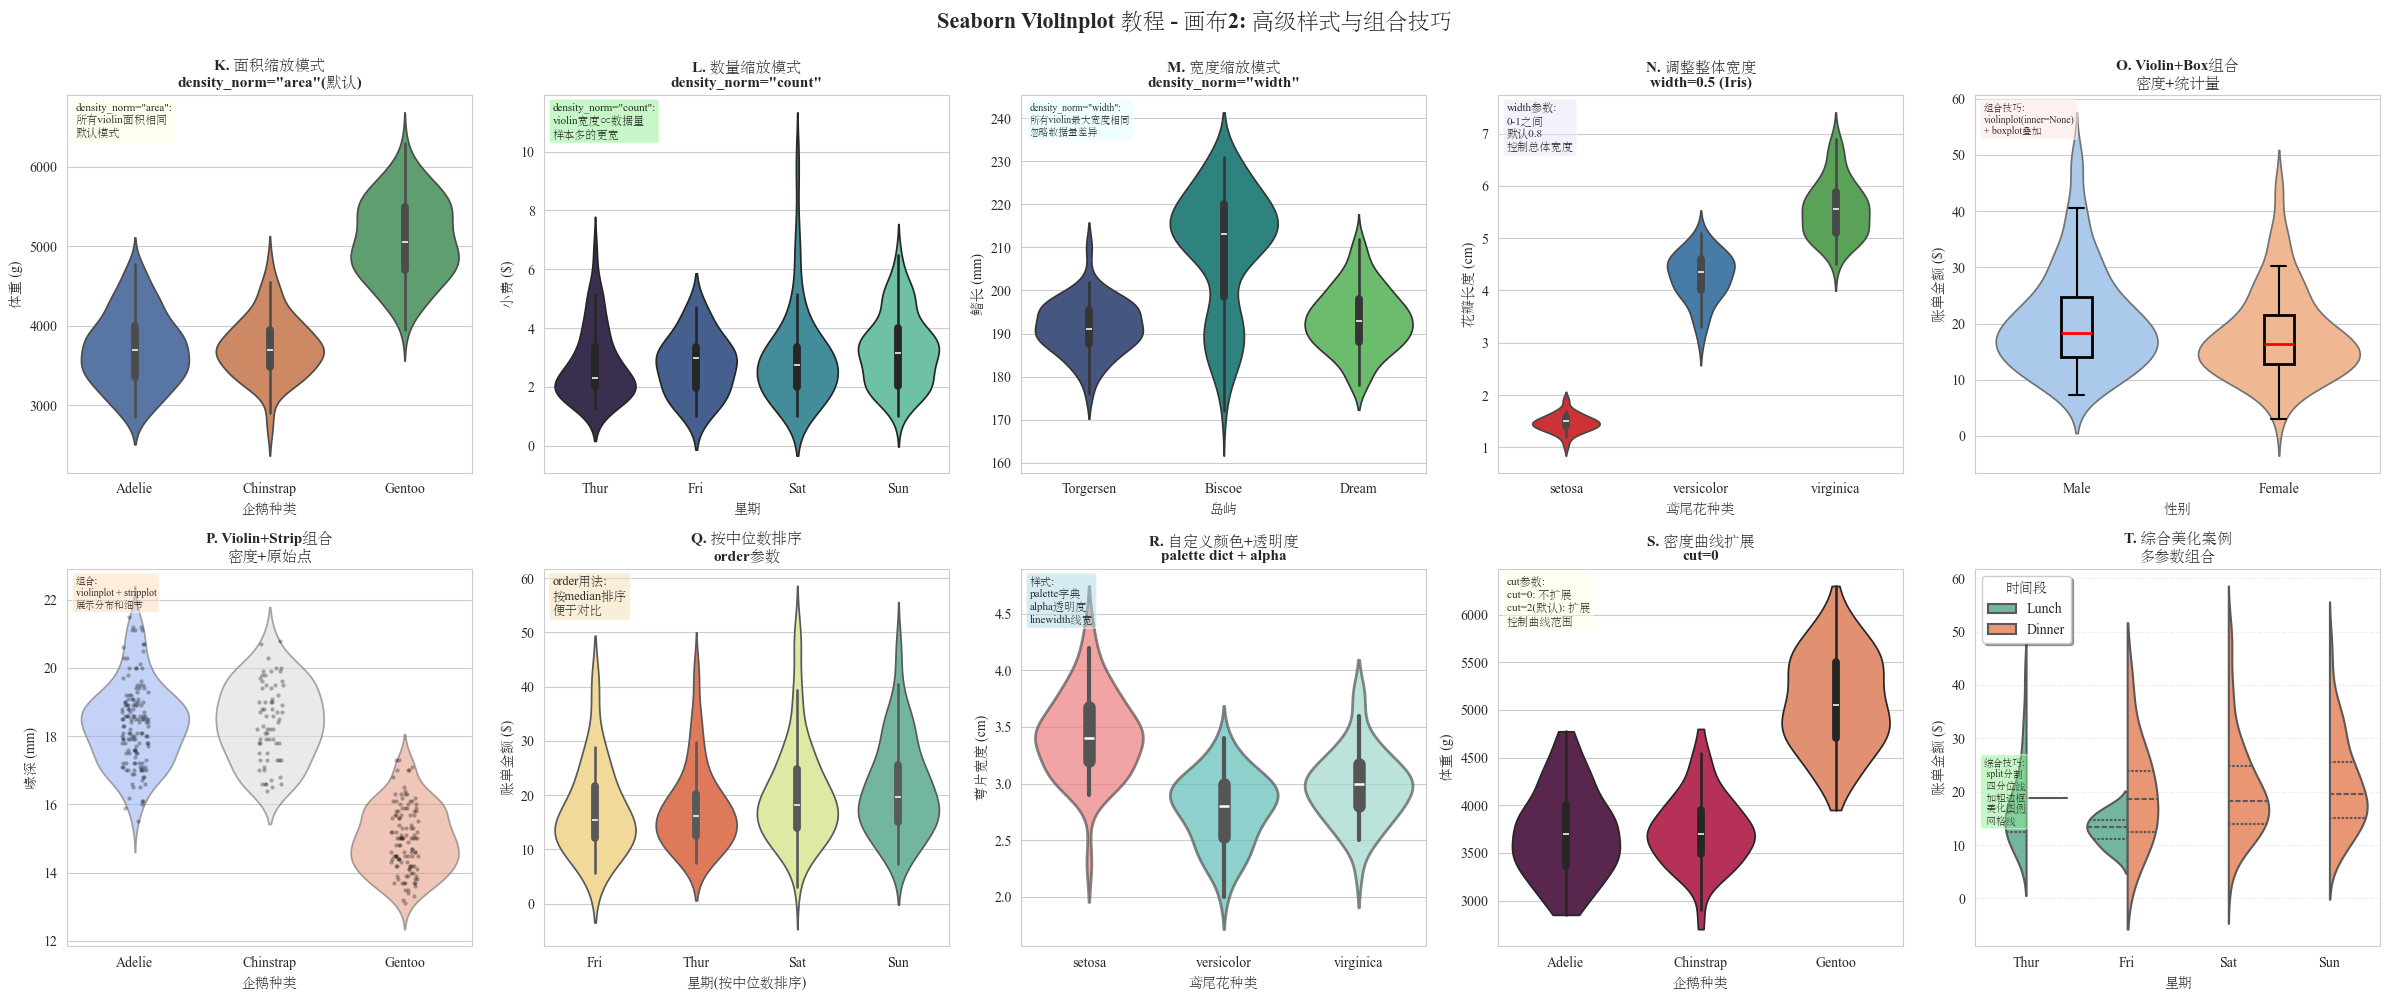

In [ ]:
# ============================================================
# 画布 2: 高级样式和组合技巧
# ============================================================
fig2, axes2 = plt.subplots(2, 5, figsize=(24, 10))  # 创建2行5列子图布局，总画布大小24x10英寸
fig2.suptitle('Seaborn Violinplot 教程 - 画布2: 高级样式与组合技巧',  # 设置整个画布的总标题
              fontsize=16,  # 总标题字体大小16
              fontweight='bold',  # 总标题加粗显示
              y=0.995)  # 总标题垂直位置略低于顶部（避免裁剪）

# ========== 子图 K：density_norm参数 - area ==========
ax = axes2[0, 0]  # 获取第1行第1列子图对象
sns.violinplot(data=penguins,  # 数据源：企鹅数据集
               x='species',  # x轴：物种
               y='body_mass_g',  # y轴：体重
               hue='species',  # 分组：按物种着色
               palette='deep',  # deep深色调色板
               legend=False,  # 隐藏图例
               density_norm='area',  # density_norm="area"：所有小提琴面积相同（默认）
               ax=ax)  # 绘制目标
ax.set_title('K. 面积缩放模式\ndensity_norm="area"(默认)', fontsize=11, fontweight='bold')  # 标题说明面积缩放
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'density_norm="area":\n所有violin面积相同\n默认模式',  # 说明面积缩放特点
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))  # 浅黄色背景框

# ========== 子图 L：density_norm参数 - count ==========
ax = axes2[0, 1]  # 获取第1行第2列子图对象
sns.violinplot(data=tips,  # 数据源：tips小费数据集
               x='day',  # x轴：星期
               y='tip',  # y轴：小费
               hue='day',  # 分组：按星期
               palette='mako',  # mako蓝绿渐变调色板
               legend=False,  # 隐藏图例
               scale='count',  # density_norm="count"：宽度正比于数据量
               ax=ax)  # 绘制目标
ax.set_title('L. 数量缩放模式\ndensity_norm="count"', fontsize=11, fontweight='bold')  # 标题说明数量缩放
ax.set_xlabel('星期', fontsize=10)  # x轴标签
ax.set_ylabel('小费 ($)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'density_norm="count":\nviolin宽度∝数据量\n样本多的更宽',  # 说明数量缩放效果
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))  # 浅绿色背景框

# ========== 子图 M：density_norm参数 - width ==========
ax = axes2[0, 2]  # 获取第1行第3列子图对象
sns.violinplot(data=penguins,  # 数据源
               x='island',  # x轴：岛屿
               y='flipper_length_mm',  # y轴：鳍长
               hue='island',  # 分组：按岛屿
               palette='viridis',  # viridis连续色彩调色板
               legend=False,  # 隐藏图例
               scale='width',  # density_norm="width"：所有小提琴最大宽度相同
               ax=ax)  # 绘制目标
ax.set_title('M. 宽度缩放模式\ndensity_norm="width"', fontsize=11, fontweight='bold')  # 标题说明宽度缩放
ax.set_xlabel('岛屿', fontsize=10)  # x轴标签
ax.set_ylabel('鳍长 (mm)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'density_norm="width":\n所有violin最大宽度相同\n忽略数据量差异',  # 说明宽度缩放特点
        transform=ax.transAxes,
        fontsize=7,  # 字体小（内容多）
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.5))  # 浅青色背景框

# ========== 子图 N：调整整体宽度 ==========
ax = axes2[0, 3]  # 获取第1行第4列子图对象
sns.violinplot(data=iris,  # 数据源：iris鸢尾花数据集
               x='species',  # x轴：花种
               y='petal_length',  # y轴：花瓣长度
               hue='species',  # 分组：按花种
               palette='Set1',  # Set1分类调色板
               legend=False,  # 隐藏图例
               width=0.5,  # width=0.5：整体宽度调整为默认的62.5%（默认0.8）
               ax=ax)  # 绘制目标
ax.set_title('N. 调整整体宽度\nwidth=0.5 (Iris)', fontsize=11, fontweight='bold')  # 标题说明宽度调整
ax.set_xlabel('鸢尾花种类', fontsize=10)  # x轴标签
ax.set_ylabel('花瓣长度 (cm)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'width参数:\n0-1之间\n默认0.8\n控制总体宽度',  # 说明width参数范围
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.5))  # 淡紫色背景框

# ========== 子图 O：小提琴图+箱线图组合 ==========
ax = axes2[0, 4]  # 获取第1行第5列子图对象
sns.violinplot(data=tips,  # 数据源：tips数据集
               x='sex',  # x轴：性别
               y='total_bill',  # y轴：账单总额
               hue='sex',  # 分组：按性别
               palette='pastel',  # 柔和色彩调色板
               legend=False,  # 隐藏图例
               inner=None,  # inner=None：小提琴不显示内部标记
               ax=ax)  # 绘制小提琴图
sns.boxplot(data=tips,  # 数据源
            x='sex',  # x轴
            y='total_bill',  # y轴
            width=0.15,  # 箱线图宽度：0.15（较窄）
            showfliers=False,  # 隐藏异常值
            boxprops=dict(facecolor='none',  # 箱体无填充
                          edgecolor='black',  # 箱体边框：黑色
                          linewidth=2),  # 箱体线宽：2点
            whiskerprops=dict(color='black',  # 箱须：黑色
                              linewidth=1.5),  # 箱须线宽：1.5点
            capprops=dict(color='black',  # 端帽：黑色
                          linewidth=1.5),  # 端帽线宽：1.5点
            medianprops=dict(color='red',  # 中位数线：红色
                             linewidth=2),  # 中位数线宽：2点
            ax=ax)  # 叠加到同一子图
ax.set_title('O. Violin+Box组合\n密度+统计量', fontsize=11, fontweight='bold')  # 标题说明组合效果
ax.set_xlabel('性别', fontsize=10)  # x轴标签
ax.set_ylabel('账单金额 ($)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        '组合技巧:\nviolinplot(inner=None)\n+ boxplot叠加',  # 说明组合实现方法
        transform=ax.transAxes,
        fontsize=7,  # 字体小（内容多）
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.5))  # 玫瑰色背景框

# ========== 子图 P：小提琴图+散点图 ==========
ax = axes2[1, 0]  # 获取第2行第1列子图对象
sns.violinplot(data=penguins,  # 数据源
               x='species',  # x轴：物种
               y='bill_depth_mm',  # y轴：喙深
               hue='species',  # 分组
               palette='coolwarm',  # 冷暖色系调色板
               legend=False,  # 隐藏图例
               inner=None,  # 无内部标记
               alpha=0.6,  # 小提琴透明度：60%
               ax=ax)  # 绘制小提琴图
sns.stripplot(data=penguins,  # 数据源
              x='species',  # x轴
              y='bill_depth_mm',  # y轴
              color='black',  # 散点颜色：黑色
              alpha=0.3,  # 散点透明度：30%
              size=3,  # 散点大小：3点
              ax=ax)  # 叠加散点图
ax.set_title('P. Violin+Strip组合\n密度+原始点', fontsize=11, fontweight='bold')  # 标题说明组合效果
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('喙深 (mm)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        '组合:\nviolinplot + stripplot\n展示分布和细节',  # 说明组合优势
        transform=ax.transAxes,
        fontsize=7,  # 字体小（内容多）
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='peachpuff', alpha=0.5))  # 桃色背景框

# ========== 子图 Q：按中位数排序 ==========
ax = axes2[1, 1]  # 获取第2行第2列子图对象
day_order = tips.groupby('day', observed=True)['total_bill'].median().sort_values().index  # 按星期分组，计算账单中位数，升序排序，返回索引
sns.violinplot(data=tips,  # 数据源
               x='day',  # x轴：星期
               y='total_bill',  # y轴：账单总额
               order=day_order,  # order参数：按中位数排序
               hue='day',  # 分组
               palette='Spectral',  # 光谱色调色板
               legend=False,  # 隐藏图例
               ax=ax)  # 绘制目标
ax.set_title('Q. 按中位数排序\norder参数', fontsize=11, fontweight='bold')  # 标题说明排序依据
ax.set_xlabel('星期(按中位数排序)', fontsize=10)  # x轴标签说明排序方法
ax.set_ylabel('账单金额 ($)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'order用法:\n按median排序\n便于对比',  # 说明排序优势
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))  # 浅黄色背景框

# ========== 子图 R：自定义颜色和透明度 ==========
ax = axes2[1, 2]  # 获取第2行第3列子图对象
custom_colors = {  # 自定义颜色字典：花种→十六进制颜色
    'setosa': '#FF6B6B',  # 山茶花：珊瑚红
    'versicolor': '#4ECDC4',  # 变色鸢尾：青绿色
    'virginica': '#95E1D3'  # 弗吉尼亚鸢尾：浅青色
}
sns.violinplot(data=iris,  # 数据源
               x='species',  # x轴：花种
               y='sepal_width',  # y轴：萼片宽度
               hue='species',  # 分组
               palette=custom_colors,  # 使用自定义颜色字典
               legend=False,  # 隐藏图例
               alpha=0.7,  # 透明度：70%
               linewidth=2,  # 边框线宽：2点
               ax=ax)  # 绘制目标
ax.set_title('R. 自定义颜色+透明度\npalette dict + alpha', fontsize=11, fontweight='bold')  # 标题说明样式定制
ax.set_xlabel('鸢尾花种类', fontsize=10)  # x轴标签
ax.set_ylabel('萼片宽度 (cm)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        '样式:\npalette字典\nalpha透明度\nlinewidth线宽',  # 说明3大样式参数
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))  # 浅蓝色背景框

# ========== 子图 S：cut参数控制扩展 ==========
ax = axes2[1, 3]  # 获取第2行第4列子图对象
sns.violinplot(data=penguins,  # 数据源
               x='species',  # x轴
               y='body_mass_g',  # y轴
               hue='species',  # 分组
               palette='rocket',  # rocket红黑渐变调色板
               legend=False,  # 隐藏图例
               cut=0,  # cut=0：不扩展密度曲线（默认cut=2）
               ax=ax)  # 绘制目标
ax.set_title('S. 密度曲线扩展\ncut=0', fontsize=11, fontweight='bold')  # 标题说明曲线扩展控制
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'cut参数:\ncut=0: 不扩展\ncut=2(默认): 扩展\n控制曲线范围',  # 说明cut参数效果
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))  # 浅黄色背景框

# ========== 子图 T：综合应用 - 精美报表 ==========
ax = axes2[1, 4]  # 获取第2行第5列子图对象
sns.violinplot(data=tips,  # 数据源
               x='day',  # x轴：星期
               y='total_bill',  # y轴：账单总额
               hue='time',  # 分组：时间段（午餐/晚餐）
               split=True,  # split=True：左右分割显示
               palette='Set2',  # Set2柔和色彩调色板
               inner='quartile',  # inner="quartile"：显示四分位线
               linewidth=1.5,  # 边框线宽：1.5点
               ax=ax)  # 绘制目标
ax.set_title('T. 综合美化案例\n多参数组合', fontsize=11, fontweight='bold')  # 标题说明综合应用
ax.set_xlabel('星期', fontsize=10)  # x轴标签
ax.set_ylabel('账单金额 ($)', fontsize=10)  # y轴标签
ax.legend(title='时间段',  # 图例标题
          frameon=True,  # 显示边框
          fancybox=True,  # 圆角边框
          shadow=True,  # 阴影效果
          loc='upper left')  # 左上角位置
ax.grid(axis='y', alpha=0.3, linestyle='--')  # y轴虚线网格，透明度30%
ax.text(0.02,  # 文本位置（垂直居中）
        0.50,
        '综合技巧:\n split分割\n 四分位线\n 加粗边框\n 美化图例\n 网格线',  # 总结5大美化技巧
        transform=ax.transAxes,
        fontsize=7,  # 字体小（内容多）
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))  # 浅绿色背景框

plt.tight_layout()  # 自动调整子图间距，避免重叠
plt.show()  # 显示画布2的10个子图

In [15]:

# ============================================================
# 小提琴图 vs 箱线图对比
# ============================================================
print("\n" + "="*60)
print("小提琴图(Violinplot) vs 箱线图(Boxplot)")
print("="*60)
print("""
相同点:
- 都能显示数据的分布特征
- 都能对比多组数据

不同点:
┌─────────────┬──────────────────┬──────────────────┐
│   特性      │   箱线图         │   小提琴图       │
├─────────────┼──────────────────┼──────────────────┤
│ 分布形状    │   不显示         │   显示密度曲线   │
│ 多峰分布    │   无法识别       │   可以识别       │
│ 数据细节    │   五数概括       │   完整分布信息   │
│ 异常值      │   明确标注       │   融入分布中     │
│ 图形复杂度  │   简单直观       │   信息更丰富     │
│ 适用场景    │   快速概览       │   详细分析       │
└─────────────┴──────────────────┴──────────────────┘

选择建议:
- 数据分布复杂、有多峰 → 小提琴图
- 需要突出异常值 → 箱线图
- 快速对比统计量 → 箱线图
- 展示完整分布特征 → 小提琴图
- 报告演示 → 两者结合
""")

# ============================================================
# 打印重要参数总结
# ============================================================
print("\n" + "="*60)
print("Seaborn violinplot 核心参数总结 (v0.13.2+)")
print("="*60)
print("""
1. 基础参数:
   - data: 数据源(DataFrame)
   - x, y: 坐标轴变量
   - hue: 分组变量
   - order, hue_order: 控制显示顺序

2. 分布显示:
   - inner: 内部显示方式
     * "box": 微型箱线图(默认)
     * "quartile": 四分位线
     * "point": 单个数据点
     * "stick": 棒状标记
     * None: 无标记
   - split: 分割显示(True/False，仅2组hue)

3. 密度估计:
   - bw_method: 带宽计算方法('scott'/'silverman')
   - bw_adjust: 带宽调整因子(默认1.0)
     * <1: 更多细节，不平滑
     * >1: 更平滑，更简化
   - cut: 曲线扩展距离(默认2)
   - gridsize: 核密度估计的网格点数(默认100)

4. 缩放模式:
   - density_norm: violin密度归一化方式
     * "area": 面积相同(默认)
     * "count": 宽度∝数据量
     * "width": 最大宽度相同
   - width: 整体宽度(0-1，默认0.8)

5. 样式参数:
   - palette: 调色板(需配合hue)
   - color: 单一颜色
   - saturation: 饱和度(0-1)
   - alpha: 透明度(0-1)
   - linewidth: 边框线宽

6. 布局参数:
   - dodge: 分组是否并排(True/False)
   - legend: 是否显示图例

7. 常用组合:
   - violinplot(inner=None) + boxplot: 密度+统计
   - violinplot + stripplot: 密度+原始点
   - violinplot + swarmplot: 密度+不重叠点
   - split=True: 左右对比(仅2组)

8. 三个数据集使用场景:
   - Penguins: 生物测量数据，多个数值变量
   - Tips: 消费数据，适合分类对比
   - Iris: 经典分类数据，多特征对比

9. 使用场景:
   ✓ 识别数据分布形状（单峰/多峰/偏态）
   ✓ 对比多组数据的分布差异
   ✓ 查看数据密度集中区域
   ✓ 展示完整的数据分布信息
   ✓ 发现数据的模式和异常模式
""")


小提琴图(Violinplot) vs 箱线图(Boxplot)

相同点:
- 都能显示数据的分布特征
- 都能对比多组数据

不同点:
┌─────────────┬──────────────────┬──────────────────┐
│   特性      │   箱线图         │   小提琴图       │
├─────────────┼──────────────────┼──────────────────┤
│ 分布形状    │   不显示         │   显示密度曲线   │
│ 多峰分布    │   无法识别       │   可以识别       │
│ 数据细节    │   五数概括       │   完整分布信息   │
│ 异常值      │   明确标注       │   融入分布中     │
│ 图形复杂度  │   简单直观       │   信息更丰富     │
│ 适用场景    │   快速概览       │   详细分析       │
└─────────────┴──────────────────┴──────────────────┘

选择建议:
- 数据分布复杂、有多峰 → 小提琴图
- 需要突出异常值 → 箱线图
- 快速对比统计量 → 箱线图
- 展示完整分布特征 → 小提琴图
- 报告演示 → 两者结合


Seaborn violinplot 核心参数总结 (v0.13.2+)

1. 基础参数:
   - data: 数据源(DataFrame)
   - x, y: 坐标轴变量
   - hue: 分组变量
   - order, hue_order: 控制显示顺序

2. 分布显示:
   - inner: 内部显示方式
     * "box": 微型箱线图(默认)
     * "quartile": 四分位线
     * "point": 单个数据点
     * "stick": 棒状标记
     * None: 无标记
   - split: 分割显示(True/False，仅2组hue)

3. 密度估计:
   - bw_method: 带宽计算方法('scott'/'silverman')
   - bw_adjust: 带宽调整

## stripplot

Penguins数据集形状: (333, 7)
Tips数据集形状: (244, 7)

Stripplot特点: 显示每个原始数据点
适合小到中等规模的数据集


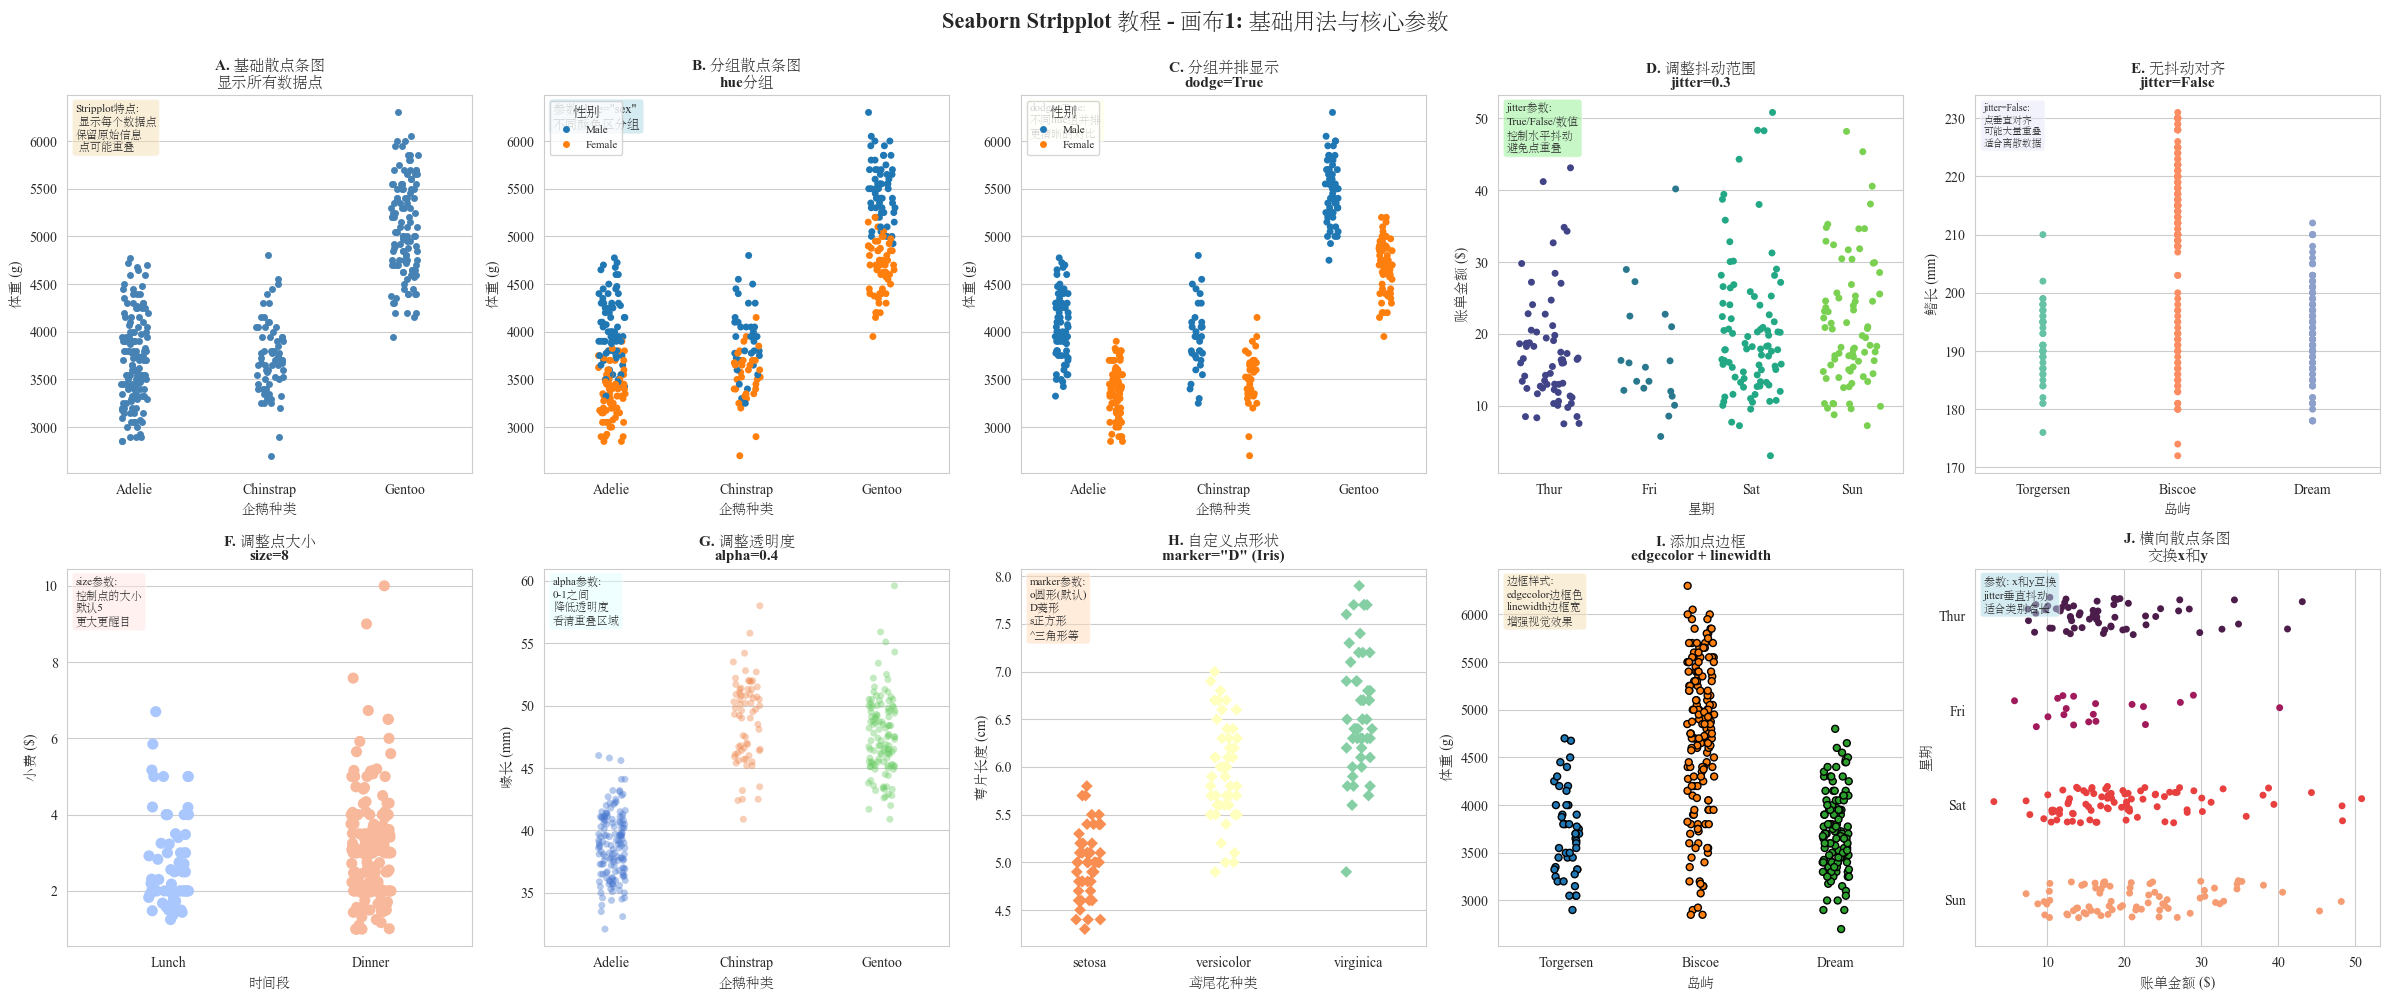

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 加载多个数据集
penguins = sns.load_dataset('penguins').dropna()  # 加载企鹅数据集并删除缺失值
tips = sns.load_dataset('tips')  # 加载tips小费数据集
iris = sns.load_dataset('iris')  # 加载iris鸢尾花数据集

print(f"Penguins数据集形状: {penguins.shape}")  # 输出企鹅数据集行数×列数
print(f"Tips数据集形状: {tips.shape}")  # 输出tips数据集行数×列数
print(f"\nStripplot特点: 显示每个原始数据点")  # 说明stripplot核心特点
print("适合小到中等规模的数据集")  # 说明适用数据规模

# ============================================================
# 画布 1: 基础用法和核心参数
# ============================================================
fig1, axes1 = plt.subplots(2, 5, figsize=(24, 10))  # 创建2行5列子图布局，总画布大小24x10英寸
fig1.suptitle('Seaborn Stripplot 教程 - 画布1: 基础用法与核心参数',  # 设置整个画布的总标题
              fontsize=16,  # 总标题字体大小16
              fontweight='bold',  # 总标题加粗显示
              y=0.995)  # 总标题垂直位置略低于顶部（避免裁剪）

# ========== 子图 A：最基础的散点条图 ==========
ax = axes1[0, 0]  # 获取第1行第1列子图对象
sns.stripplot(data=penguins,  # 数据源：企鹅数据集
              x='species',  # x轴：企鹅物种（分类变量）
              y='body_mass_g',  # y轴：体重（数值变量）
              ax=ax,  # 指定绘制到当前子图
              color='steelblue')  # 设置单一颜色为钢蓝色
ax.set_title('A. 基础散点条图\n显示所有数据点', fontsize=11, fontweight='bold')  # 子图标题说明显示所有数据
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签：企鹅种类
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签：体重（克）
ax.text(0.02,  # 文本水平位置：左边距2%
        0.98,  # 文本垂直位置：顶部98%
        'Stripplot特点:\n 显示每个数据点\n保留原始信息\n 点可能重叠',  # 详细说明stripplot核心特点
        transform=ax.transAxes,  # 使用相对坐标系
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 顶部对齐
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))  # 圆角浅黄色半透明背景框

# ========== 子图 B：添加hue分组 ==========
ax = axes1[0, 1]  # 获取第1行第2列子图对象
sns.stripplot(data=penguins,  # 数据源
              x='species',  # x轴：物种
              y='body_mass_g',  # y轴：体重
              hue='sex',  # hue参数：按性别分组，不同颜色
              ax=ax)  # 绘制到当前子图，自动配色
ax.set_title('B. 分组散点条图\nhue分组', fontsize=11, fontweight='bold')  # 标题说明分组功能
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签
ax.legend(title='性别', loc='upper left', fontsize=8)  # 图例：标题"性别"，左上角，字体8
ax.text(0.02,  # 文本位置
        0.98,
        '参数: hue="sex"\n不同颜色区分组',  # 说明hue参数颜色分组效果
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))  # 浅蓝色背景框

# ========== 子图 C：dodge参数分开显示 ==========
ax = axes1[0, 2]  # 获取第1行第3列子图对象
sns.stripplot(data=penguins,  # 数据源
              x='species',  # x轴：物种
              y='body_mass_g',  # y轴：体重
              hue='sex',  # hue：按性别分组
              dodge=True,  # dodge=True：不同hue组水平并排显示
              ax=ax)  # 绘制到当前子图，自动配色
ax.set_title('C. 分组并排显示\ndodge=True', fontsize=11, fontweight='bold')  # 标题说明并排效果
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签
ax.legend(title='性别', loc='upper left', fontsize=8)  # 图例设置
ax.text(0.02,  # 文本位置
        0.98,
        'dodge=True:\n不同hue组并排\n更清晰的对比',  # 说明dodge并排优势
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))  # 浅黄色背景框

# ========== 子图 D：jitter参数控制抖动 ==========
ax = axes1[0, 3]  # 获取第1行第4列子图对象
sns.stripplot(data=tips,  # 数据源：tips小费数据集
              x='day',  # x轴：星期
              y='total_bill',  # y轴：账单总额
              hue='day',  # 分组：按星期着色
              palette='viridis',  # viridis连续色彩调色板
              legend=False,  # 隐藏图例
              jitter=0.3,  # jitter=0.3：水平抖动范围0.3（0-1之间）
              ax=ax)  # 绘制目标
ax.set_title('D. 调整抖动范围\njitter=0.3', fontsize=11, fontweight='bold')  # 标题说明抖动控制
ax.set_xlabel('星期', fontsize=10)  # x轴标签
ax.set_ylabel('账单金额 ($)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'jitter参数:\nTrue/False/数值\n控制水平抖动\n避免点重叠',  # 说明jitter三种用法
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))  # 浅绿色背景框

# ========== 子图 E：jitter=False无抖动 ==========
ax = axes1[0, 4]  # 获取第1行第5列子图对象
sns.stripplot(data=penguins,  # 数据源
              x='island',  # x轴：岛屿
              y='flipper_length_mm',  # y轴：鳍长
              hue='island',  # 分组：按岛屿
              palette='Set2',  # Set2柔和色彩调色板
              legend=False,  # 隐藏图例
              jitter=False,  # jitter=False：无水平抖动，点垂直对齐
              ax=ax)  # 绘制目标
ax.set_title('E. 无抖动对齐\njitter=False', fontsize=11, fontweight='bold')  # 标题说明无抖动效果
ax.set_xlabel('岛屿', fontsize=10)  # x轴标签
ax.set_ylabel('鳍长 (mm)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'jitter=False:\n点垂直对齐\n可能大量重叠\n适合离散数据',  # 说明无抖动特点和适用场景
        transform=ax.transAxes,
        fontsize=7,  # 字体小（内容多）
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.5))  # 淡紫色背景框

# ========== 子图 F：调整点的大小 ==========
ax = axes1[1, 0]  # 获取第2行第1列子图对象
sns.stripplot(data=tips,  # 数据源
              x='time',  # x轴：时间段（午餐/晚餐）
              y='tip',  # y轴：小费
              hue='time',  # 分组：按时间段
              palette='coolwarm',  # 冷暖色系调色板
              legend=False,  # 隐藏图例
              size=8,  # size=8：点大小8点（默认5）
              ax=ax)  # 绘制目标
ax.set_title('F. 调整点大小\nsize=8', fontsize=11, fontweight='bold')  # 标题说明点大小调整
ax.set_xlabel('时间段', fontsize=10)  # x轴标签
ax.set_ylabel('小费 ($)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'size参数:\n控制点的大小\n默认5\n更大更醒目',  # 说明size参数效果
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.5))  # 玫瑰色背景框

# ========== 子图 G：调整透明度 ==========
ax = axes1[1, 1]  # 获取第2行第2列子图对象
sns.stripplot(data=penguins,  # 数据源
              x='species',  # x轴：物种
              y='bill_length_mm',  # y轴：喙长
              hue='species',  # 分组
              palette='muted',  # 柔和色彩调色板
              legend=False,  # 隐藏图例
              alpha=0.4,  # alpha=0.4：点透明度40%
              ax=ax)  # 绘制目标
ax.set_title('G. 调整透明度\nalpha=0.4', fontsize=11, fontweight='bold')  # 标题说明透明度调整
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('喙长 (mm)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'alpha参数:\n0-1之间\n降低透明度\n看清重叠区域',  # 说明alpha参数作用
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.5))  # 浅青色背景框

# ========== 子图 H：自定义点样式marker ==========
ax = axes1[1, 2]  # 获取第2行第3列子图对象
sns.stripplot(data=iris,  # 数据源：iris鸢尾花数据集
              x='species',  # x轴：花种
              y='sepal_length',  # y轴：萼片长度
              hue='species',  # 分组：按花种
              palette='Spectral',  # 光谱色调色板
              legend=False,  # 隐藏图例
              marker='D',  # marker='D'：菱形标记（默认'o'圆形）
              size=6,  # 点大小：6点
              ax=ax)  # 绘制目标
ax.set_title('H. 自定义点形状\nmarker="D" (Iris)', fontsize=11, fontweight='bold')  # 标题说明自定义形状
ax.set_xlabel('鸢尾花种类', fontsize=10)  # x轴标签
ax.set_ylabel('萼片长度 (cm)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'marker参数:\no圆形(默认)\nD菱形\ns正方形\n^三角形等',  # 列出常见marker形状
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='peachpuff', alpha=0.5))  # 桃色背景框

# ========== 子图 I：添加边框 ==========
ax = axes1[1, 3]  # 获取第2行第4列子图对象
sns.stripplot(data=penguins,  # 数据源
              x='island',  # x轴：岛屿
              y='body_mass_g',  # y轴：体重
              hue='island',  # 分组
              palette='tab10',  # 10色分类调色板
              legend=False,  # 隐藏图例
              edgecolor='black',  # edgecolor='black'：点边框颜色黑色
              linewidth=1,  # linewidth=1：边框线宽1点
              ax=ax)  # 绘制目标
ax.set_title('I. 添加点边框\nedgecolor + linewidth', fontsize=11, fontweight='bold')  # 标题说明边框设置
ax.set_xlabel('岛屿', fontsize=10)  # x轴标签
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        '边框样式:\nedgecolor边框色\nlinewidth边框宽\n增强视觉效果',  # 说明边框参数作用
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))  # 浅黄色背景框

# ========== 子图 J：横向散点条图 ==========
ax = axes1[1, 4]  # 获取第2行第5列子图对象
sns.stripplot(data=tips,  # 数据源
              x='total_bill',  # x轴：账单总额（数值）
              y='day',  # y轴：星期（分类）-交换实现横向
              hue='day',  # 分组：按星期
              palette='rocket',  # rocket红黑渐变调色板
              legend=False,  # 隐藏图例
              jitter=0.2,  # jitter=0.2：垂直抖动范围0.2
              size=5,  # 点大小：5点
              ax=ax)  # 绘制目标
ax.set_title('J. 横向散点条图\n交换x和y', fontsize=11, fontweight='bold')  # 标题说明横向实现
ax.set_xlabel('账单金额 ($)', fontsize=10)  # x轴标签
ax.set_ylabel('星期', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        '参数: x和y互换\njitter垂直抖动\n适合类别名长',  # 说明横向参数和适用场景
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))  # 浅蓝色背景框

plt.tight_layout()  # 自动调整子图间距，避免重叠
plt.show()  # 显示画布1的10个子图

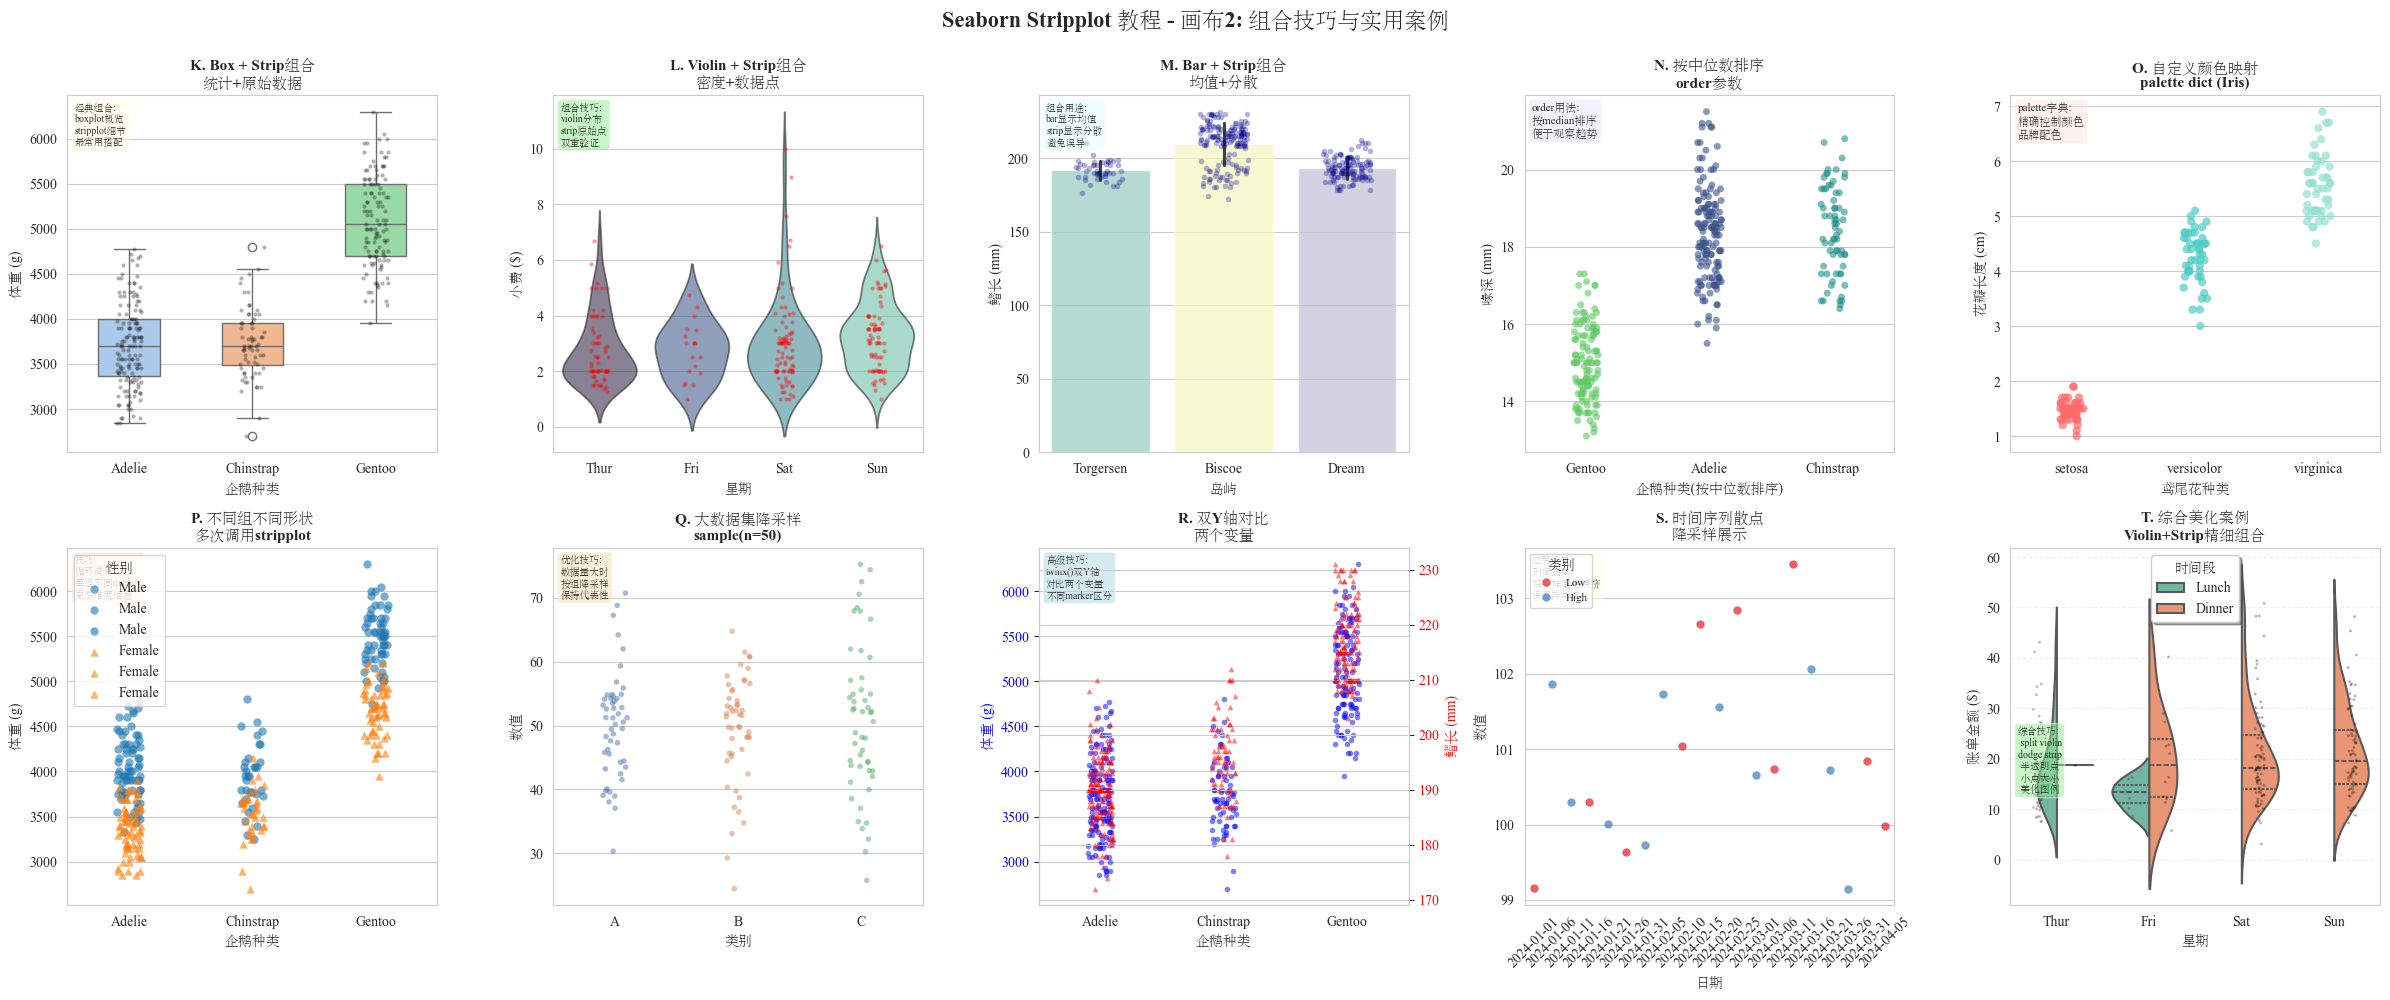

In [17]:
# ============================================================
# 画布 2: 组合技巧和实用案例
# ============================================================
fig2, axes2 = plt.subplots(2, 5, figsize=(24, 10))  # 创建2行5列子图布局，总画布大小24x10英寸
fig2.suptitle('Seaborn Stripplot 教程 - 画布2: 组合技巧与实用案例',  # 设置整个画布的总标题
              fontsize=16,  # 总标题字体大小16
              fontweight='bold',  # 总标题加粗显示
              y=0.995)  # 总标题垂直位置略低于顶部（避免裁剪）

# ========== 子图 K：Boxplot + Stripplot ==========
ax = axes2[0, 0]  # 获取第1行第1列子图对象
sns.boxplot(data=penguins,  # 数据源：企鹅数据集
            x='species',  # x轴：物种
            y='body_mass_g',  # y轴：体重
            hue='species',  # 分组：按物种着色
            palette='pastel',  # 柔和色彩调色板
            legend=False,  # 隐藏图例
            width=0.5,  # 箱体宽度：0.5
            ax=ax)  # 绘制箱线图
sns.stripplot(data=penguins,  # 数据源
              x='species',  # x轴
              y='body_mass_g',  # y轴
              color='black',  # 散点颜色：黑色
              alpha=0.3,  # 散点透明度：30%
              size=3,  # 散点大小：3点
              ax=ax)  # 叠加到同一子图
ax.set_title('K. Box + Strip组合\n统计+原始数据', fontsize=11, fontweight='bold')  # 标题说明经典组合
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        '经典组合:\nboxplot概览\nstripplot细节\n最常用搭配',  # 说明最常用组合优势
        transform=ax.transAxes,
        fontsize=7,  # 字体小（内容多）
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))  # 浅黄色背景框

# ========== 子图 L：Violin + Stripplot ==========
ax = axes2[0, 1]  # 获取第1行第2列子图对象
sns.violinplot(data=tips,  # 数据源：tips数据集
               x='day',  # x轴：星期
               y='tip',  # y轴：小费
               hue='day',  # 分组：按星期
               palette='mako',  # mako蓝绿渐变调色板
               legend=False,  # 隐藏图例
               inner=None,  # 无内部标记
               alpha=0.6,  # 小提琴透明度：60%
               ax=ax)  # 绘制小提琴图
sns.stripplot(data=tips,  # 数据源
              x='day',  # x轴
              y='tip',  # y轴
              color='red',  # 散点颜色：红色
              alpha=0.4,  # 散点透明度：40%
              size=3,  # 散点大小：3点
              ax=ax)  # 叠加散点图
ax.set_title('L. Violin + Strip组合\n密度+数据点', fontsize=11, fontweight='bold')  # 标题说明密度组合
ax.set_xlabel('星期', fontsize=10)  # x轴标签
ax.set_ylabel('小费 ($)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        '组合技巧:\nviolin分布\nstrip原始点\n双重验证',  # 说明双重验证优势
        transform=ax.transAxes,
        fontsize=7,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))  # 浅绿色背景框

# ========== 子图 M：Barplot + Stripplot ==========
ax = axes2[0, 2]  # 获取第1行第3列子图对象
sns.barplot(data=penguins,  # 数据源
            x='island',  # x轴：岛屿
            y='flipper_length_mm',  # y轴：鳍长
            hue='island',  # 分组：按岛屿
            palette='Set3',  # Set3分类调色板
            legend=False,  # 隐藏图例
            alpha=0.7,  # 柱状图透明度：70%
            errorbar='sd',  # 误差条：标准差
            ax=ax)  # 绘制柱状图
sns.stripplot(data=penguins,  # 数据源
              x='island',  # x轴
              y='flipper_length_mm',  # y轴
              color='darkblue',  # 散点颜色：深蓝色
              alpha=0.3,  # 散点透明度：30%
              size=4,  # 散点大小：4点
              jitter=0.2,  # 水平抖动：0.2
              ax=ax)  # 叠加散点图
ax.set_title('M. Bar + Strip组合\n均值+分散', fontsize=11, fontweight='bold')  # 标题说明均值分散组合
ax.set_xlabel('岛屿', fontsize=10)  # x轴标签
ax.set_ylabel('鳍长 (mm)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        '组合用途:\nbar显示均值\nstrip显示分散\n避免误导',  # 说明避免误导优势
        transform=ax.transAxes,
        fontsize=7,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.5))  # 浅青色背景框

# ========== 子图 N：按数值排序 ==========
ax = axes2[0, 3]  # 获取第1行第4列子图对象
species_order = penguins.groupby('species')['bill_depth_mm'].median().sort_values().index  # 按物种分组，计算喙深中位数，升序排序，返回索引
sns.stripplot(data=penguins,  # 数据源
              x='species',  # x轴：物种
              y='bill_depth_mm',  # y轴：喙深
              order=species_order,  # order参数：按中位数排序
              hue='species',  # 分组
              palette='viridis',  # viridis连续色彩调色板
              legend=False,  # 隐藏图例
              size=5,  # 散点大小：5点
              alpha=0.6,  # 透明度：60%
              ax=ax)  # 绘制目标
ax.set_title('N. 按中位数排序\norder参数', fontsize=11, fontweight='bold')  # 标题说明排序依据
ax.set_xlabel('企鹅种类(按中位数排序)', fontsize=10)  # x轴标签说明排序方法
ax.set_ylabel('喙深 (mm)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'order用法:\n按median排序\n便于观察趋势',  # 说明排序趋势观察优势
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.5))  # 淡紫色背景框

# ========== 子图 O：自定义颜色字典 ==========
ax = axes2[0, 4]  # 获取第1行第5列子图对象
custom_colors = {  # 自定义颜色字典：花种→十六进制颜色
    'setosa': '#FF6B6B',  # 山茶花：珊瑚红
    'versicolor': '#4ECDC4',  # 变色鸢尾：青绿色
    'virginica': '#95E1D3'  # 弗吉尼亚鸢尾：浅青色
}
sns.stripplot(data=iris,  # 数据源：iris数据集
              x='species',  # x轴：花种
              y='petal_length',  # y轴：花瓣长度
              hue='species',  # 分组
              palette=custom_colors,  # 使用自定义颜色字典
              legend=False,  # 隐藏图例
              size=6,  # 散点大小：6点
              alpha=0.7,  # 透明度：70%
              ax=ax)  # 绘制目标
ax.set_title('O. 自定义颜色映射\npalette dict (Iris)', fontsize=11, fontweight='bold')  # 标题说明字典配色
ax.set_xlabel('鸢尾花种类', fontsize=10)  # x轴标签
ax.set_ylabel('花瓣长度 (cm)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'palette字典:\n精确控制颜色\n品牌配色',  # 说明字典精确控制优势
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.5))  # 玫瑰色背景框

# ========== 子图 P：分组dodge + 不同marker ==========
ax = axes2[1, 0]  # 获取第2行第1列子图对象
# 分别绘制两个性别，使用不同marker
for sex, marker in zip(['Male', 'Female'], ['o', '^']):  # 循环：性别对应圆形/三角形
    data_subset = penguins[penguins['sex'] == sex]  # 筛选当前性别数据
    sns.stripplot(data=data_subset,  # 子集数据
                  x='species',  # x轴：物种
                  y='body_mass_g',  # y轴：体重
                  marker=marker,  # 当前性别标记形状
                  label=sex,  # 图例标签
                  size=6,  # 散点大小：6点
                  alpha=0.6,  # 透明度：60%
                  ax=ax)  # 叠加到同一子图
ax.set_title('P. 不同组不同形状\n多次调用stripplot', fontsize=11, fontweight='bold')  # 标题说明多维技巧
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签
ax.legend(title='性别', loc='upper left')  # 图例设置
ax.text(0.02,  # 文本位置
        0.98,
        '技巧:\n循环调用\n每组不同marker\n更多维度信息',  # 说明多维度编码技巧
        transform=ax.transAxes,
        fontsize=7,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='peachpuff', alpha=0.5))  # 桃色背景框

# ========== 子图 Q：大数据集降采样 ==========
ax = axes2[1, 1]  # 获取第2行第2列子图对象
# 创建大数据集
np.random.seed(42)  # 设置随机种子确保可重复
large_data = pd.DataFrame({  # 创建1000行大数据
    'category': np.random.choice(['A', 'B', 'C'], 1000),  # 随机类别
    'value': np.random.randn(1000) * 10 + 50  # 正态分布数值
})
# 降采样
sampled_data = large_data.groupby('category').sample(n=50, random_state=42)  # 每组随机抽取50个样本
sns.stripplot(data=sampled_data,  # 降采样数据
              x='category',  # x轴：类别
              y='value',  # y轴：数值
              hue='category',  # 分组
              palette='deep',  # deep深色调色板
              legend=False,  # 隐藏图例
              alpha=0.5,  # 透明度：50%
              size=4,  # 散点大小：4点
              ax=ax)  # 绘制目标
ax.set_title('Q. 大数据集降采样\nsample(n=50)', fontsize=11, fontweight='bold')  # 标题说明降采样
ax.set_xlabel('类别', fontsize=10)  # x轴标签
ax.set_ylabel('数值', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        '优化技巧:\n数据量大时\n按组降采样\n保持代表性',  # 说明降采样保持代表性
        transform=ax.transAxes,
        fontsize=7,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))  # 浅黄色背景框

# ========== 子图 R：双Y轴对比 ==========
ax = axes2[1, 2]  # 获取第2行第3列子图对象
ax_twin = ax.twinx()  # 创建右Y轴
# 左Y轴
sns.stripplot(data=penguins,  # 数据源
              x='species',  # x轴：物种
              y='body_mass_g',  # 左Y轴：体重
              color='blue',  # 蓝色散点
              alpha=0.5,  # 透明度：50%
              size=4,  # 散点大小：4点
              ax=ax)  # 绘制到左轴
ax.set_ylabel('体重 (g)', fontsize=10, color='blue')  # 左Y轴标签
ax.tick_params(axis='y', labelcolor='blue')  # 左Y轴刻度颜色
# 右Y轴
sns.stripplot(data=penguins,  # 数据源
              x='species',  # x轴
              y='flipper_length_mm',  # 右Y轴：鳍长
              color='red',  # 红色散点
              alpha=0.5,  # 透明度：50%
              size=4,  # 散点大小：4点
              marker='^',  # 三角形标记
              ax=ax_twin)  # 绘制到右轴
ax_twin.set_ylabel('鳍长 (mm)', fontsize=10, color='red')  # 右Y轴标签
ax_twin.tick_params(axis='y', labelcolor='red')  # 右Y轴刻度颜色
ax.set_title('R. 双Y轴对比\n两个变量', fontsize=11, fontweight='bold')  # 标题说明双变量对比
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.text(0.02,  # 文本位置
        0.98,
        '高级技巧:\ntwinx()双Y轴\n对比两个变量\n不同marker区分',  # 说明双Y轴技巧
        transform=ax.transAxes,
        fontsize=7,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))  # 浅蓝色背景框

# ========== 子图 S：时间序列散点 ==========
ax = axes2[1, 3]  # 获取第2行第4列子图对象
# 创建时间序列数据
dates = pd.date_range('2024-01-01', periods=100, freq='D')  # 2024年1月1日起100天日期
ts_data = pd.DataFrame({  # 创建时间序列DataFrame
    'date': dates,  # 日期列
    'value': np.cumsum(np.random.randn(100)) + 100,  # 累积和+随机游走
    'category': np.random.choice(['High', 'Low'], 100)  # 随机高低类别
})
# 只取部分点避免过密
ts_sample = ts_data.iloc[::5]  # 每5个取1个（降采样20个点）
sns.stripplot(data=ts_sample,  # 降采样数据
              x='date',  # x轴：日期
              y='value',  # y轴：数值
              hue='category',  # 分组：高低类别
              palette='Set1',  # Set1分类调色板
              size=6,  # 散点大小：6点
              alpha=0.7,  # 透明度：70%
              ax=ax)  # 绘制目标
ax.set_title('S. 时间序列散点\n降采样展示', fontsize=11, fontweight='bold')  # 标题说明时间序列
ax.set_xlabel('日期', fontsize=10)  # x轴标签
ax.set_ylabel('数值', fontsize=10)  # y轴标签
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)  # x轴标签旋转45度
ax.legend(title='类别', loc='upper left', fontsize=8)  # 图例设置
ax.text(0.02,  # 文本位置
        0.98,
        '应用场景:\n时间趋势\n降采样避免拥挤\n保留异常值',  # 说明时间序列应用
        transform=ax.transAxes,
        fontsize=7,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))  # 浅黄色背景框

# ========== 子图 T：综合美化案例 ==========
ax = axes2[1, 4]  # 获取第2行第5列子图对象
sns.violinplot(data=tips,  # 数据源
               x='day',  # x轴：星期
               y='total_bill',  # y轴：账单总额
               hue='time',  # 分组：时间段
               split=True,  # 左右分割显示
               palette='Set2',  # Set2柔和色彩调色板
               inner='quartile',  # 显示四分位线
               linewidth=1.5,  # 边框线宽：1.5点
               ax=ax)  # 绘制小提琴图
# 叠加stripplot，使用dodge匹配violin的分组
sns.stripplot(data=tips,  # 数据源
              x='day',  # x轴
              y='total_bill',  # y轴
              hue='time',  # 分组：时间段
              dodge=True,  # dodge=True：与violin分组对齐
              palette='dark:black',  # 深色黑色调色板
              alpha=0.3,  # 透明度：30%
              size=2,  # 小点大小：2点
              ax=ax,  # 叠加到同一子图
              legend=False)  # 隐藏重复图例
ax.set_title('T. 综合美化案例\nViolin+Strip精细组合', fontsize=11, fontweight='bold')  # 标题说明精细组合
ax.set_xlabel('星期', fontsize=10)  # x轴标签
ax.set_ylabel('账单金额 ($)', fontsize=10)  # y轴标签
ax.legend(title='时间段',  # 图例标题
          frameon=True,  # 显示边框
          fancybox=True,  # 圆角边框
          shadow=True)  # 阴影效果
ax.grid(axis='y', alpha=0.3, linestyle='--')  # y轴虚线网格，透明度30%
ax.text(0.02,  # 文本位置（垂直居中）
        0.50,
        '综合技巧:\n split violin\ndodge strip\n 半透明点\n 小点大小\n 美化图例',  # 总结5大美化技巧
        transform=ax.transAxes,
        fontsize=7,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))  # 浅绿色背景框

plt.tight_layout()  # 自动调整子图间距，避免重叠
plt.show()  # 显示画布2的10个子图

In [18]:
# ============================================================
# Stripplot使用场景说明
# ============================================================
print("\n" + "="*60)
print("Stripplot 使用场景分析")
print("="*60)
print("""
✅ 适合使用stripplot的场景:
1. 数据量较小(每组<200个点)
2. 需要展示每个原始数据点
3. 检查数据分布和异常值
4. 与其他图表组合使用
5. 需要保留完整数据信息

❌ 不适合使用stripplot的场景:
1. 数据量非常大(每组>500个点)
   - 解决方案: 降采样或使用swarmplot/violinplot
2. 数据严重重叠
   - 解决方案: 增加jitter、降低alpha、减小size
3. 只需要统计摘要
   - 解决方案: 使用boxplot或barplot

🔄 常见组合:
- boxplot + stripplot: 最常用，统计+细节
- violinplot + stripplot: 密度+数据点
- barplot + stripplot: 均值+分散性
""")

# ============================================================
# 与swarmplot对比
# ============================================================
print("\n" + "="*60)
print("Stripplot vs Swarmplot")
print("="*60)
print("""
┌──────────────┬────────────────┬────────────────┐
│   特性       │   Stripplot    │   Swarmplot    │
├──────────────┼────────────────┼────────────────┤
│ 点的排列     │   随机抖动     │   算法排列     │
│ 点是否重叠   │   可能重叠     │   不重叠       │
│ 数据量限制   │   中等规模     │   小规模       │
│ 计算速度     │   快           │   慢           │
│ 视觉美观度   │   一般         │   更美观       │
│ 准确度       │   略失真       │   精确         │
└──────────────┴────────────────┴────────────────┘

选择建议:
- 数据量<100: swarmplot更美观
- 数据量100-500: stripplot更实用
- 数据量>500: 考虑降采样或其他图表
- 性能要求高: stripplot
- 视觉要求高: swarmplot
""")

# ============================================================
# 打印重要参数总结
# ============================================================
print("\n" + "="*60)
print("Seaborn stripplot 核心参数总结 (v0.13.2+)")
print("="*60)
print("""
1. 基础参数:
   - data: 数据源(DataFrame)
   - x, y: 坐标轴变量
   - hue: 分组变量
   - order, hue_order: 控制显示顺序

2. 抖动控制:
   - jitter: 控制水平抖动
     * True: 默认抖动(0.2)
     * False: 不抖动，垂直对齐
     * 数值: 自定义抖动范围(0-0.5)

3. 点样式:
   - size: 点大小(默认5)
   - alpha: 透明度(0-1)
   - marker: 点形状('o', 'D', 's', '^'等)
   - edgecolor: 边框颜色
   - linewidth: 边框宽度

4. 颜色参数:
   - palette: 调色板(需配合hue)
   - color: 单一颜色
   - hue_norm: 颜色归一化

5. 布局参数:
   - dodge: hue组是否并排(True/False)
   - orient: 方向('v'/'h'，通常自动检测)
   - legend: 是否显示图例

6. 常用组合搭配:
   - boxplot + stripplot: 统计摘要 + 原始数据
   - violinplot + stripplot: 密度分布 + 数据点
   - barplot + stripplot: 均值 + 数据分散
   - 多次调用stripplot: 不同组不同样式

7. 性能优化技巧:
   - 大数据集: 使用groupby().sample()降采样
   - 降低alpha: 看清重叠区域
   - 减小size: 减少遮挡
   - 增加jitter: 减少重叠

8. 使用场景:
   ✓ 展示原始数据分布
   ✓ 识别异常值和模式
   ✓ 验证统计摘要的合理性
   ✓ 小到中等规模数据集
   ✓ 与其他图表组合验证
""")


Stripplot 使用场景分析

✅ 适合使用stripplot的场景:
1. 数据量较小(每组<200个点)
2. 需要展示每个原始数据点
3. 检查数据分布和异常值
4. 与其他图表组合使用
5. 需要保留完整数据信息

❌ 不适合使用stripplot的场景:
1. 数据量非常大(每组>500个点)
   - 解决方案: 降采样或使用swarmplot/violinplot
2. 数据严重重叠
   - 解决方案: 增加jitter、降低alpha、减小size
3. 只需要统计摘要
   - 解决方案: 使用boxplot或barplot

🔄 常见组合:
- boxplot + stripplot: 最常用，统计+细节
- violinplot + stripplot: 密度+数据点
- barplot + stripplot: 均值+分散性


Stripplot vs Swarmplot

┌──────────────┬────────────────┬────────────────┐
│   特性       │   Stripplot    │   Swarmplot    │
├──────────────┼────────────────┼────────────────┤
│ 点的排列     │   随机抖动     │   算法排列     │
│ 点是否重叠   │   可能重叠     │   不重叠       │
│ 数据量限制   │   中等规模     │   小规模       │
│ 计算速度     │   快           │   慢           │
│ 视觉美观度   │   一般         │   更美观       │
│ 准确度       │   略失真       │   精确         │
└──────────────┴────────────────┴────────────────┘

选择建议:
- 数据量<100: swarmplot更美观
- 数据量100-500: stripplot更实用
- 数据量>500: 考虑降采样或其他图表
- 性能要求高: stripplot
- 视觉要求高: swarmplot


Seaborn stripplot 核心参数

## swarmplot

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings

# 加载数据集
penguins = sns.load_dataset('penguins').dropna()
tips = sns.load_dataset('tips')

print(f"Penguins数据集形状: {penguins.shape}")
print(f"\nSwarmplot特点: 蜂群图，点不重叠")
print("适合小规模数据集，视觉效果最佳")
print("\n各组样本量:")
print(penguins.groupby('species').size())

Penguins数据集形状: (333, 7)

Swarmplot特点: 蜂群图，点不重叠
适合小规模数据集，视觉效果最佳

各组样本量:
species
Adelie       146
Chinstrap     68
Gentoo       119
dtype: int64


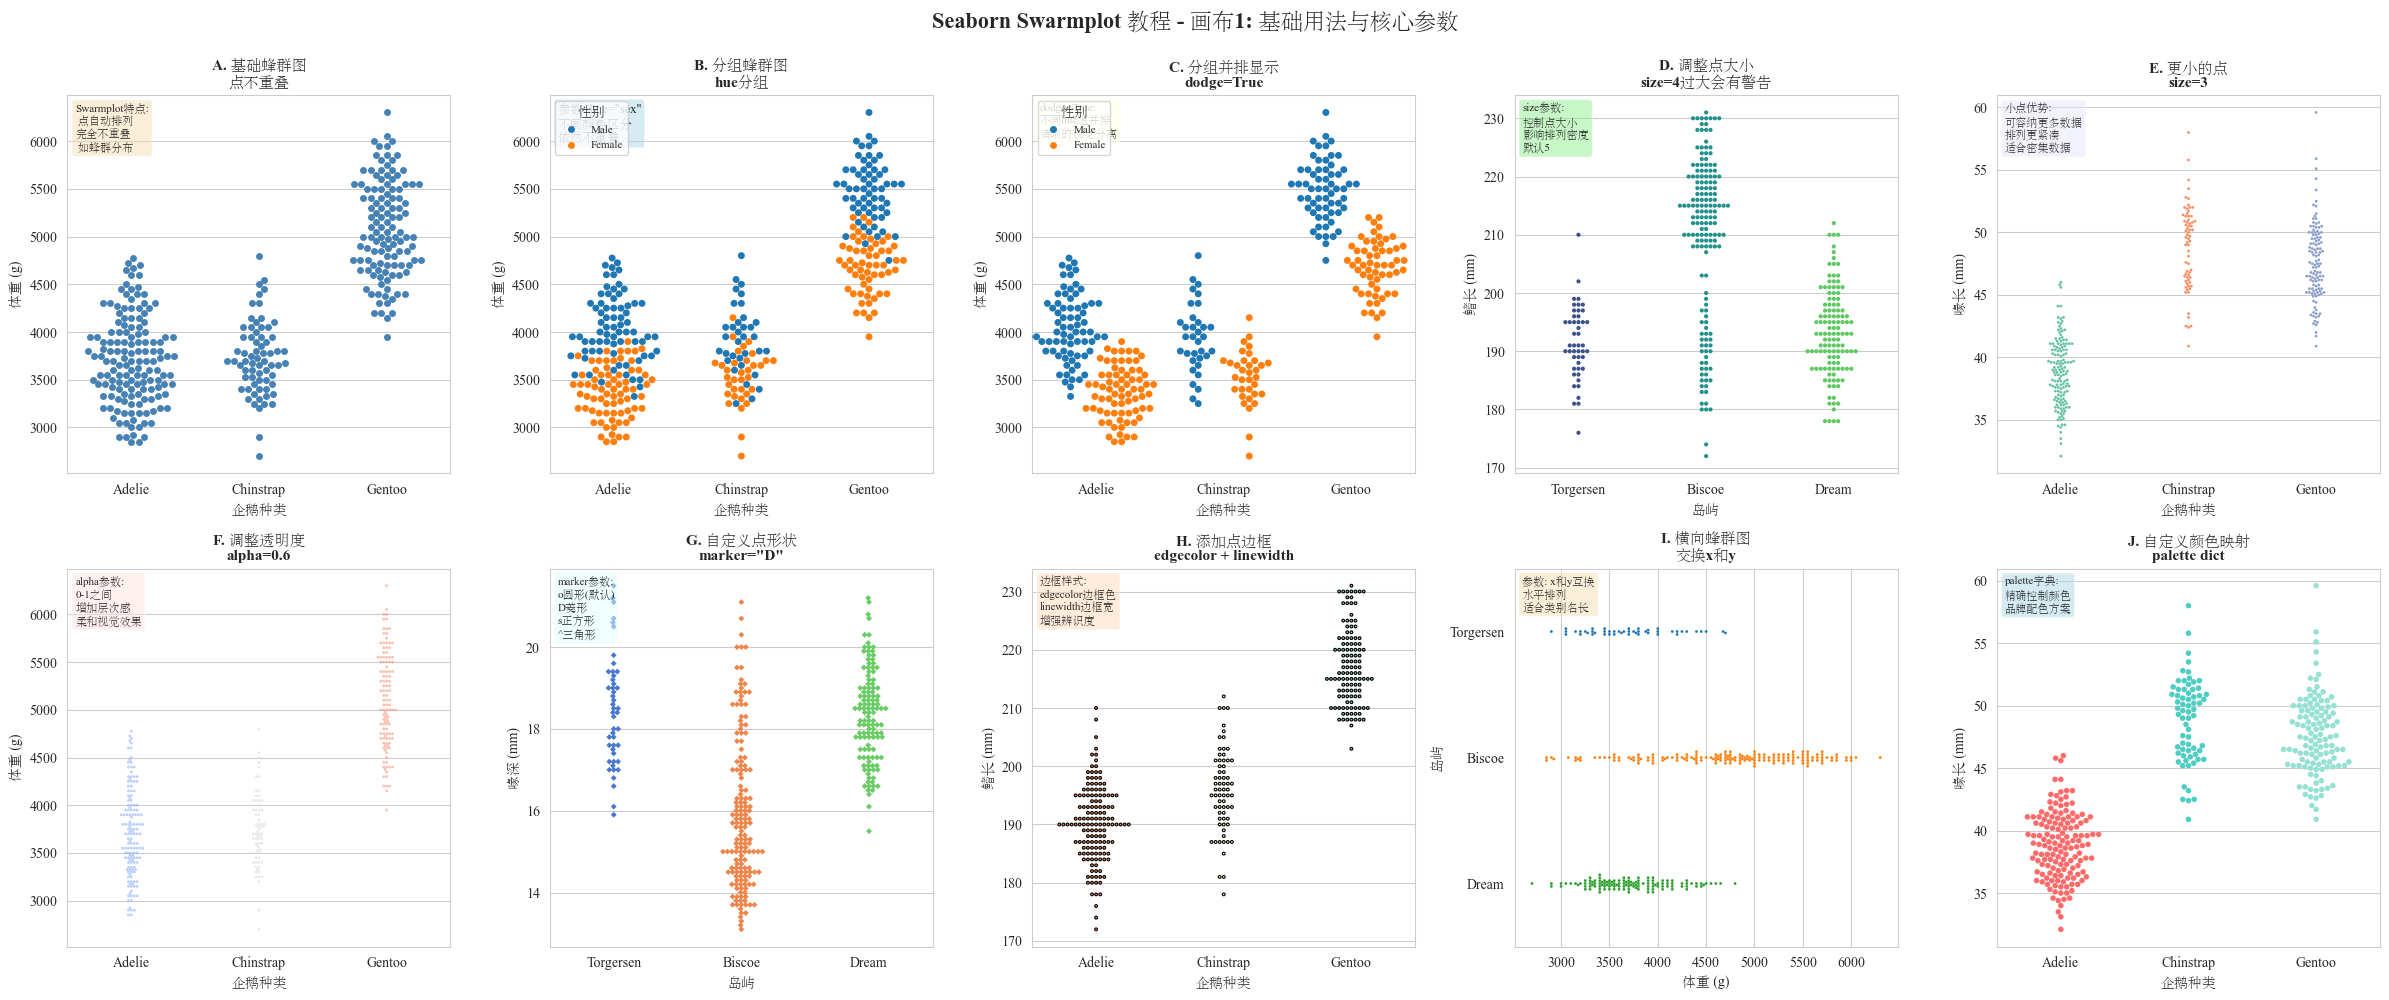

In [20]:
# ============================================================
# 画布 1: 基础用法和核心参数
# ============================================================
fig1, axes1 = plt.subplots(2, 5, figsize=(24, 10))  # 创建2行5列子图布局，总画布大小24x10英寸
fig1.suptitle('Seaborn Swarmplot 教程 - 画布1: 基础用法与核心参数',  # 设置整个画布的总标题
              fontsize=16,  # 总标题字体大小16
              fontweight='bold',  # 总标题加粗显示
              y=0.995)  # 总标题垂直位置略低于顶部（避免裁剪）

# ========== 子图 A：最基础的蜂群图 ==========
ax = axes1[0, 0]  # 获取第1行第1列子图对象
sns.swarmplot(data=penguins,  # 数据源：企鹅数据集
              x='species',  # x轴：企鹅物种（分类变量）
              y='body_mass_g',  # y轴：体重（数值变量）
              ax=ax,  # 指定绘制到当前子图
              color='steelblue')  # 设置单一颜色为钢蓝色
ax.set_title('A. 基础蜂群图\n点不重叠', fontsize=11, fontweight='bold')  # 子图标题说明不重叠特点
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签：企鹅种类
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签：体重（克）
ax.text(0.02,  # 文本水平位置：左边距2%
        0.98,  # 文本垂直位置：顶部98%
        'Swarmplot特点:\n 点自动排列\n完全不重叠\n 如蜂群分布',  # 详细说明swarmplot核心特点
        transform=ax.transAxes,  # 使用相对坐标系
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 顶部对齐
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))  # 圆角浅黄色半透明背景框

# ========== 子图 B：添加hue分组 ==========
ax = axes1[0, 1]  # 获取第1行第2列子图对象
sns.swarmplot(data=penguins,  # 数据源
              x='species',  # x轴：物种
              y='body_mass_g',  # y轴：体重
              hue='sex',  # hue参数：按性别分组，不同颜色
              ax=ax)  # 绘制到当前子图，自动配色
ax.set_title('B. 分组蜂群图\nhue分组', fontsize=11, fontweight='bold')  # 标题说明分组功能
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签
ax.legend(title='性别', loc='upper left', fontsize=8)  # 图例：标题"性别"，左上角，字体8
ax.text(0.02,  # 文本位置
        0.98,
        '参数: hue="sex"\n不同颜色区分\n依然不重叠',  # 说明hue参数颜色分组+不重叠效果
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))  # 浅蓝色背景框

# ========== 子图 C：dodge参数分开显示 ==========
ax = axes1[0, 2]  # 获取第1行第3列子图对象
sns.swarmplot(data=penguins,  # 数据源
              x='species',  # x轴：物种
              y='body_mass_g',  # y轴：体重
              hue='sex',  # hue：按性别分组
              dodge=True,  # dodge=True：不同hue组水平并排显示
              ax=ax)  # 绘制到当前子图，自动配色
ax.set_title('C. 分组并排显示\ndodge=True', fontsize=11, fontweight='bold')  # 标题说明并排效果
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签
ax.legend(title='性别', loc='upper left', fontsize=8)  # 图例设置
ax.text(0.02,  # 文本位置
        0.98,
        'dodge=True:\n不同hue组并排\n清晰的视觉分离',  # 说明dodge并排视觉优势
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))  # 浅黄色背景框

# ========== 子图 D：调整点的大小 ==========
ax = axes1[0, 3]  # 获取第1行第4列子图对象
sns.swarmplot(data=penguins,  # 数据源
              x='island',  # x轴：岛屿
              y='flipper_length_mm',  # y轴：鳍长
              hue='island',  # 分组：按岛屿
              palette='viridis',  # viridis连续色彩调色板
              legend=False,  # 隐藏图例
              size=3,  # size=3：点大小3点（默认5），小点可容纳更多数据
              ax=ax)  # 绘制目标
ax.set_title('D. 调整点大小\nsize=4过大会有警告', fontsize=11, fontweight='bold')  # 标题说明size限制
ax.set_xlabel('岛屿', fontsize=10)  # x轴标签
ax.set_ylabel('鳍长 (mm)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'size参数:\n控制点大小\n影响排列密度\n默认5',  # 说明size对排列密度的影响
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))  # 浅绿色背景框

# ========== 子图 E：更小的点 ==========
ax = axes1[0, 4]  # 获取第1行第5列子图对象
sns.swarmplot(data=penguins,  # 数据源
              x='species',  # x轴：物种
              y='bill_length_mm',  # y轴：喙长
              hue='species',  # 分组：按物种
              palette='Set2',  # Set2柔和色彩调色板
              legend=False,  # 隐藏图例
              size=2,  # size=2：更小的点，最大化数据容量
              ax=ax)  # 绘制目标
ax.set_title('E. 更小的点\nsize=3', fontsize=11, fontweight='bold')  # 标题说明小点优势
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('喙长 (mm)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        '小点优势:\n可容纳更多数据\n排列更紧凑\n适合密集数据',  # 说明小点适用场景
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.5))  # 淡紫色背景框

# ========== 子图 F：调整透明度 ==========
ax = axes1[1, 0]  # 获取第2行第1列子图对象
sns.swarmplot(data=penguins,  # 数据源
              x='species',  # x轴：物种
              y='body_mass_g',  # y轴：体重
              hue='species',  # 分组
              palette='coolwarm',  # 冷暖色系调色板
              legend=False,  # 隐藏图例
              alpha=0.6,  # alpha=0.6：点透明度60%
              size=2,  # 小点大小：2点
              ax=ax)  # 绘制目标
ax.set_title('F. 调整透明度\nalpha=0.6', fontsize=11, fontweight='bold')  # 标题说明透明度调整
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'alpha参数:\n0-1之间\n增加层次感\n柔和视觉效果',  # 说明alpha视觉层次优势
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.5))  # 玫瑰色背景框

# ========== 子图 G：自定义点样式marker ==========
ax = axes1[1, 1]  # 获取第2行第2列子图对象
sns.swarmplot(data=penguins,  # 数据源
              x='island',  # x轴：岛屿
              y='bill_depth_mm',  # y轴：喙深
              hue='island',  # 分组：按岛屿
              palette='muted',  # 柔和色彩调色板
              legend=False,  # 隐藏图例
              marker='D',  # marker='D'：菱形标记（默认'o'圆形）
              size=3,  # 点大小：3点
              ax=ax)  # 绘制目标
ax.set_title('G. 自定义点形状\nmarker="D"', fontsize=11, fontweight='bold')  # 标题说明自定义形状
ax.set_xlabel('岛屿', fontsize=10)  # x轴标签
ax.set_ylabel('喙深 (mm)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'marker参数:\no圆形(默认)\nD菱形\ns正方形\n^三角形',  # 列出常见marker形状
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.5))  # 浅青色背景框

# ========== 子图 H：添加边框 ==========
ax = axes1[1, 2]  # 获取第2行第3列子图对象
sns.swarmplot(data=penguins,  # 数据源
              x='species',  # x轴：物种
              y='flipper_length_mm',  # y轴：鳍长
              hue='species',  # 分组
              palette='Spectral',  # 光谱色调色板
              legend=False,  # 隐藏图例
              edgecolor='black',  # edgecolor='black'：点边框颜色黑色
              linewidth=0.8,  # linewidth=0.8：边框线宽0.8点
              size=2,  # 小点大小：2点
              ax=ax)  # 绘制目标
ax.set_title('H. 添加点边框\nedgecolor + linewidth', fontsize=11, fontweight='bold')  # 标题说明边框设置
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('鳍长 (mm)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        '边框样式:\nedgecolor边框色\nlinewidth边框宽\n增强辨识度',  # 说明边框增强辨识优势
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='peachpuff', alpha=0.5))  # 桃色背景框

# ========== 子图 I：横向蜂群图 ==========
ax = axes1[1, 3]  # 获取第2行第4列子图对象
sns.swarmplot(data=penguins,  # 数据源
              x='body_mass_g',  # x轴：体重（数值）
              y='island',  # y轴：岛屿（分类）-交换实现横向
              hue='island',  # 分组：按岛屿
              palette='tab10',  # 10色分类调色板
              legend=False,  # 隐藏图例
              size=2,  # 小点大小：2点
              ax=ax)  # 绘制目标
ax.set_title('I. 横向蜂群图\n交换x和y', fontsize=11, fontweight='bold')  # 标题说明横向实现
ax.set_xlabel('体重 (g)', fontsize=10)  # x轴标签
ax.set_ylabel('岛屿', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        '参数: x和y互换\n水平排列\n适合类别名长',  # 说明横向参数和适用场景
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))  # 浅黄色背景框

# ========== 子图 J：自定义调色板 ==========
ax = axes1[1, 4]  # 获取第2行第5列子图对象
custom_colors = {  # 自定义颜色字典：物种→十六进制颜色
    'Adelie': '#FF6B6B',  # 阿德利企鹅：珊瑚红
    'Chinstrap': '#4ECDC4',  # 帽带企鹅：青绿色
    'Gentoo': '#95E1D3'  # 杰恩图企鹅：浅青色
}
sns.swarmplot(data=penguins,  # 数据源
              x='species',  # x轴：物种
              y='bill_length_mm',  # y轴：喙长
              hue='species',  # 分组
              palette=custom_colors,  # 使用自定义颜色字典
              legend=False,  # 隐藏图例
              size=4,  # 点大小：4点
              ax=ax)  # 绘制目标
ax.set_title('J. 自定义颜色映射\npalette dict', fontsize=11, fontweight='bold')  # 标题说明字典配色
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('喙长 (mm)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'palette字典:\n精确控制颜色\n品牌配色方案',  # 说明字典精确控制优势
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))  # 浅蓝色背景框

plt.tight_layout()  # 自动调整子图间距，避免重叠
plt.show()  # 显示画布1的10个子图

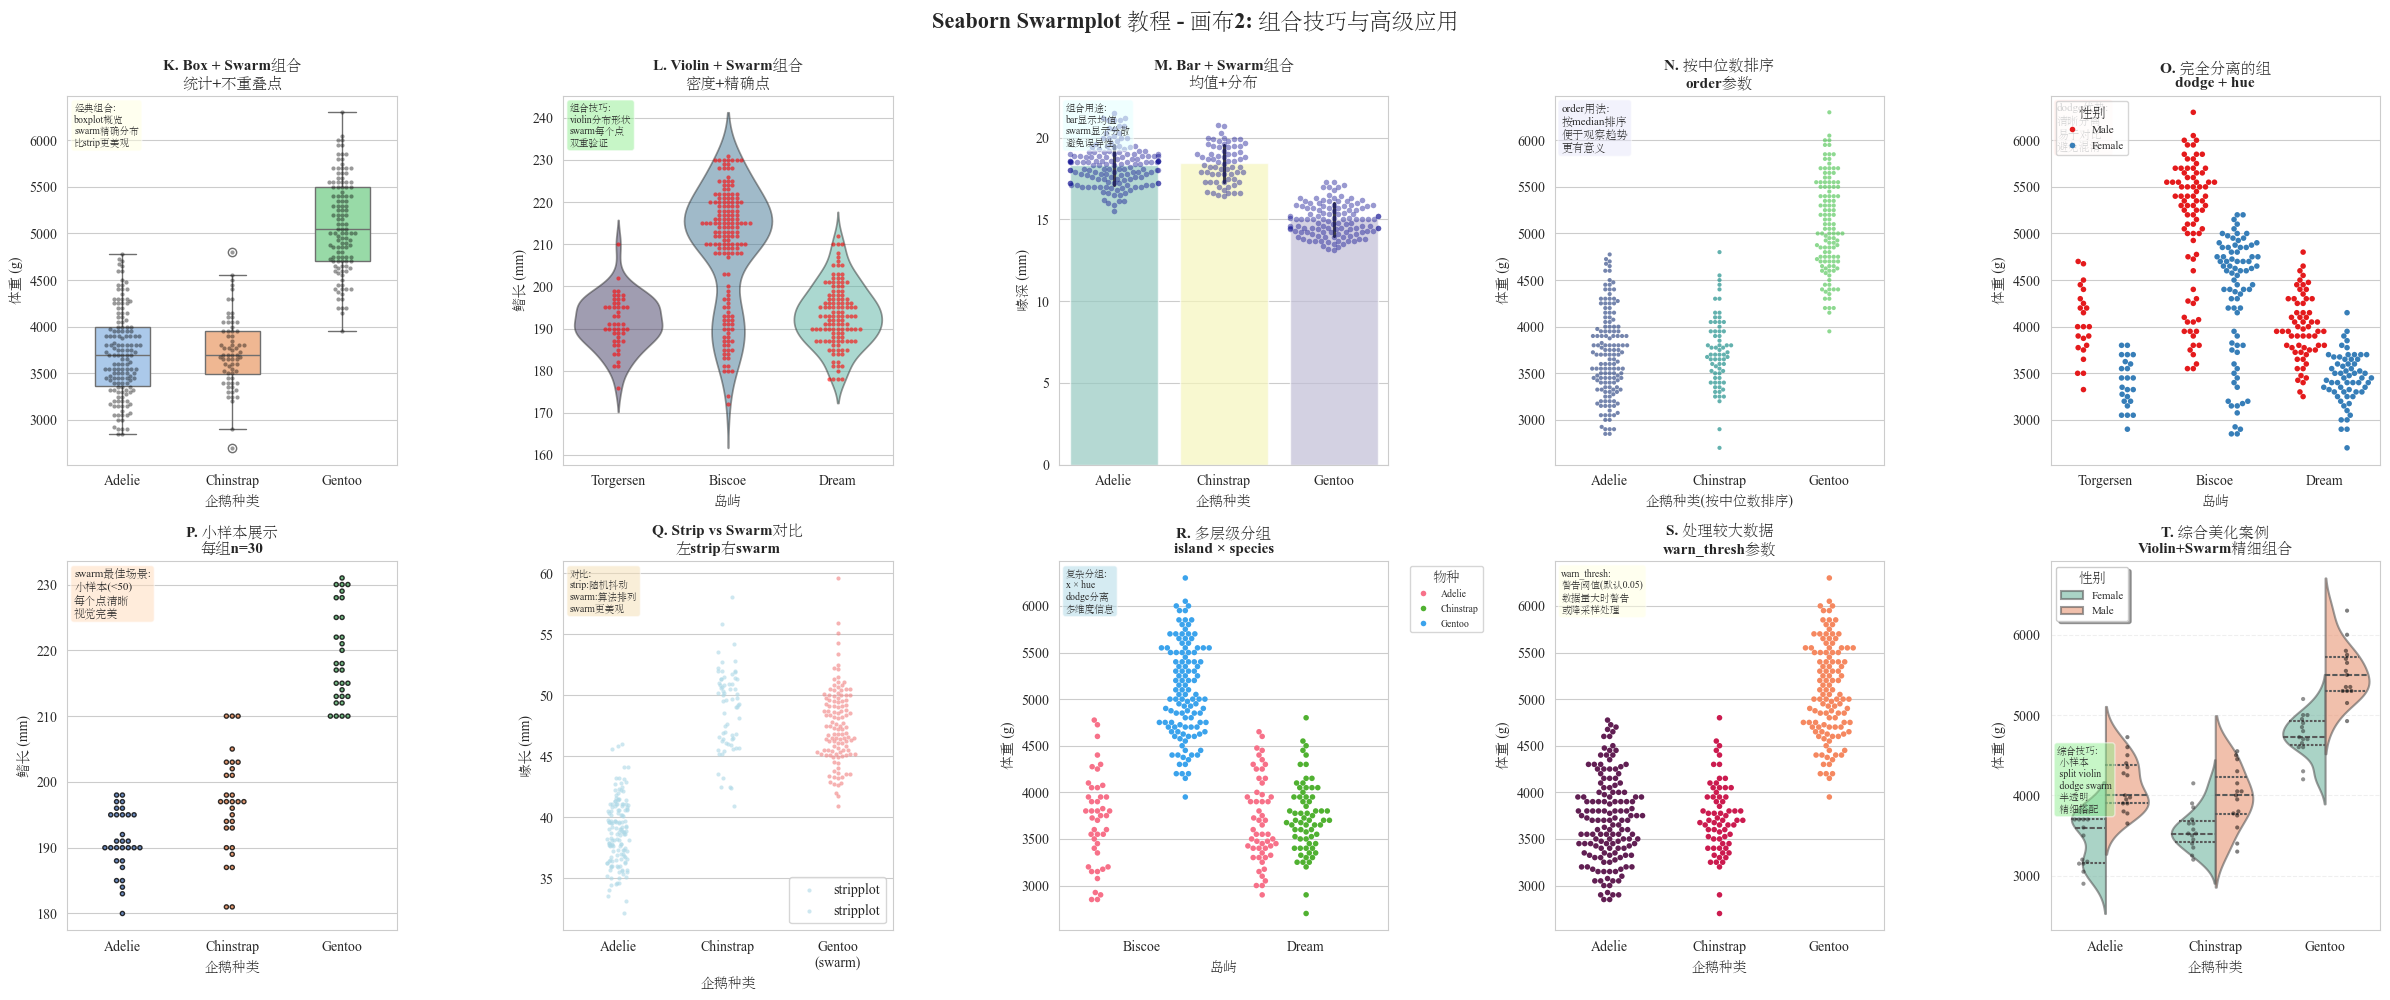

In [21]:
warnings.filterwarnings('ignore')  # 全局忽略matplotlib/seaborn警告，确保干净输出

# ============================================================
# 画布 2: 组合技巧和高级应用
# ============================================================
fig2, axes2 = plt.subplots(2, 5, figsize=(24, 10))  # 创建2行5列子图布局，总画布大小24x10英寸
fig2.suptitle('Seaborn Swarmplot 教程 - 画布2: 组合技巧与高级应用',  # 设置整个画布的总标题
              fontsize=16,  # 总标题字体大小16
              fontweight='bold',  # 总标题加粗显示
              y=0.995)  # 总标题垂直位置略低于顶部（避免裁剪）

# ========== 子图 K：Boxplot + Swarmplot ==========
ax = axes2[0, 0]  # 获取第1行第1列子图对象
sns.boxplot(data=penguins,  # 数据源：企鹅数据集
            x='species',  # x轴：物种
            y='body_mass_g',  # y轴：体重
            hue='species',  # 分组：按物种着色
            palette='pastel',  # 柔和色彩调色板
            legend=False,  # 隐藏图例
            width=0.5,  # 箱体宽度：0.5
            ax=ax)  # 绘制箱线图
sns.swarmplot(data=penguins,  # 数据源
              x='species',  # x轴
              y='body_mass_g',  # y轴
              color='black',  # 散点颜色：黑色
              alpha=0.4,  # 散点透明度：40%
              size=3,  # 散点大小：3点
              ax=ax)  # 叠加到同一子图
ax.set_title('K. Box + Swarm组合\n统计+不重叠点', fontsize=11, fontweight='bold')  # 标题说明经典组合
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        '经典组合:\nboxplot概览\nswarm精确分布\n比strip更美观',  # 说明swarm比strip美观优势
        transform=ax.transAxes,
        fontsize=7,  # 字体小（内容多）
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))  # 浅黄色背景框

# ========== 子图 L：Violin + Swarmplot ==========
ax = axes2[0, 1]  # 获取第1行第2列子图对象
sns.violinplot(data=penguins,  # 数据源
               x='island',  # x轴：岛屿
               y='flipper_length_mm',  # y轴：鳍长
               hue='island',  # 分组：按岛屿
               palette='mako',  # mako蓝绿渐变调色板
               legend=False,  # 隐藏图例
               inner=None,  # 无内部标记
               alpha=0.5,  # 小提琴透明度：50%
               ax=ax)  # 绘制小提琴图
sns.swarmplot(data=penguins,  # 数据源
              x='island',  # x轴
              y='flipper_length_mm',  # y轴
              color='red',  # 散点颜色：红色
              alpha=0.6,  # 散点透明度：60%
              size=3,  # 散点大小：3点
              ax=ax)  # 叠加蜂群图
ax.set_title('L. Violin + Swarm组合\n密度+精确点', fontsize=11, fontweight='bold')  # 标题说明密度组合
ax.set_xlabel('岛屿', fontsize=10)  # x轴标签
ax.set_ylabel('鳍长 (mm)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        '组合技巧:\nviolin分布形状\nswarm每个点\n双重验证',  # 说明双重验证优势
        transform=ax.transAxes,
        fontsize=7,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))  # 浅绿色背景框

# ========== 子图 M：Barplot + Swarmplot ==========
ax = axes2[0, 2]  # 获取第1行第3列子图对象
sns.barplot(data=penguins,  # 数据源
            x='species',  # x轴：物种
            y='bill_depth_mm',  # y轴：喙深
            hue='species',  # 分组：按物种
            palette='Set3',  # Set3分类调色板
            legend=False,  # 隐藏图例
            alpha=0.7,  # 柱状图透明度：70%
            errorbar='sd',  # 误差条：标准差
            ax=ax)  # 绘制柱状图
sns.swarmplot(data=penguins,  # 数据源
              x='species',  # x轴
              y='bill_depth_mm',  # y轴
              color='darkblue',  # 散点颜色：深蓝色
              alpha=0.4,  # 散点透明度：40%
              size=4,  # 散点大小：4点
              ax=ax)  # 叠加蜂群图
ax.set_title('M. Bar + Swarm组合\n均值+分布', fontsize=11, fontweight='bold')  # 标题说明均值分布组合
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('喙深 (mm)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        '组合用途:\nbar显示均值\nswarm显示分散\n避免误导性',  # 说明避免误导优势
        transform=ax.transAxes,
        fontsize=7,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.5))  # 浅青色背景框

# ========== 子图 N：按中位数排序 ==========
ax = axes2[0, 3]  # 获取第1行第4列子图对象
species_order = penguins.groupby('species')['body_mass_g'].median().sort_values().index  # 按物种分组，计算体重中位数，升序排序，返回索引
sns.swarmplot(data=penguins,  # 数据源
              x='species',  # x轴：物种
              y='body_mass_g',  # y轴：体重
              order=species_order,  # order参数：按中位数排序
              hue='species',  # 分组
              palette='viridis',  # viridis连续色彩调色板
              legend=False,  # 隐藏图例
              size=3,  # 散点大小：3点
              alpha=0.7,  # 透明度：70%
              ax=ax)  # 绘制目标
ax.set_title('N. 按中位数排序\norder参数', fontsize=11, fontweight='bold')  # 标题说明排序依据
ax.set_xlabel('企鹅种类(按中位数排序)', fontsize=10)  # x轴标签说明排序方法
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'order用法:\n按median排序\n便于观察趋势\n更有意义',  # 说明排序趋势观察优势
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.5))  # 淡紫色背景框

# ========== 子图 O：分组dodge + 不同颜色 ==========
ax = axes2[0, 4]  # 获取第1行第5列子图对象
sns.swarmplot(data=penguins,  # 数据源
              x='island',  # x轴：岛屿
              y='body_mass_g',  # y轴：体重
              hue='sex',  # 分组：按性别
              dodge=True,  # dodge=True：不同性别组水平并排
              palette='Set1',  # Set1分类调色板
              size=4,  # 散点大小：4点
              ax=ax)  # 绘制目标
ax.set_title('O. 完全分离的组\ndodge + hue', fontsize=11, fontweight='bold')  # 标题说明完全分离
ax.set_xlabel('岛屿', fontsize=10)  # x轴标签
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签
ax.legend(title='性别', loc='upper left', fontsize=8)  # 图例设置
ax.text(0.02,  # 文本位置
        0.98,
        'dodge优势:\n清晰分离\n易于对比\n避免混淆',  # 说明dodge清晰对比优势
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.5))  # 玫瑰色背景框

# ========== 子图 P：小样本完美展示 ==========
ax = axes2[1, 0]  # 获取第2行第1列子图对象
# 取每组的小样本
small_sample = penguins.groupby('species').sample(n=30, random_state=42)  # 每种物种随机抽取30个样本
sns.swarmplot(data=small_sample,  # 小样本数据
              x='species',  # x轴：物种
              y='flipper_length_mm',  # y轴：鳍长
              hue='species',  # 分组
              palette='deep',  # deep深色调色板
              legend=False,  # 隐藏图例
              size=3,  # 散点大小：3点
              alpha=0.8,  # 透明度：80%
              edgecolor='black',  # 边框颜色：黑色
              linewidth=1,  # 边框线宽：1点
              ax=ax)  # 绘制目标
ax.set_title('P. 小样本展示\n每组n=30', fontsize=11, fontweight='bold')  # 标题说明小样本
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('鳍长 (mm)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'swarm最佳场景:\n小样本(<50)\n每个点清晰\n视觉完美',  # 说明swarm最佳适用场景
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='peachpuff', alpha=0.5))  # 桃色背景框

# ========== 子图 Q：对比stripplot vs swarmplot ==========
ax = axes2[1, 1]  # 获取第2行第2列子图对象
# 左半部分用stripplot
subset_data = penguins[penguins['species'].isin(['Adelie', 'Chinstrap'])]  # 筛选前两种企鹅
sns.stripplot(data=subset_data,  # 子集数据
              x='species',  # x轴：物种
              y='bill_length_mm',  # y轴：喙长
              color='lightblue',  # 浅蓝色散点
              alpha=0.6,  # 透明度：60%
              size=3,  # 散点大小：3点
              ax=ax,  # 绘制到当前子图
              label='stripplot')  # 图例标签
# 右半部分用swarmplot
gentoo_data = penguins[penguins['species'] == 'Gentoo'].copy()  # 复制杰恩图企鹅数据
gentoo_data['species'] = 'Gentoo\n(swarm)'  # 修改标签显示swarm
sns.swarmplot(data=gentoo_data,  # 修改后数据
              x='species',  # x轴
              y='bill_length_mm',  # y轴
              color='lightcoral',  # 浅珊瑚色散点
              alpha=0.6,  # 透明度：60%
              size=3,  # 散点大小：3点
              ax=ax)  # 叠加到同一子图
ax.set_title('Q. Strip vs Swarm对比\n左strip右swarm', fontsize=11, fontweight='bold')  # 标题说明对比
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('喙长 (mm)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        '对比:\nstrip:随机抖动\nswarm:算法排列\nswarm更美观',  # 说明两种算法差异
        transform=ax.transAxes,
        fontsize=7,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))  # 浅黄色背景框

# ========== 子图 R：多个hue组合 ==========
ax = axes2[1, 2]  # 获取第2行第3列子图对象
# 只选两个岛屿避免过于复杂
two_islands = penguins[penguins['island'].isin(['Biscoe', 'Dream'])]  # 筛选两个岛屿
sns.swarmplot(data=two_islands,  # 筛选数据
              x='island',  # x轴：岛屿
              y='body_mass_g',  # y轴：体重
              hue='species',  # 分组：按物种（多层级）
              dodge=True,  # dodge=True：分离显示
              palette='husl',  # husl色彩调色板
              size=4,  # 散点大小：4点
              ax=ax)  # 绘制目标
ax.set_title('R. 多层级分组\nisland × species', fontsize=11, fontweight='bold')  # 标题说明多层级
ax.set_xlabel('岛屿', fontsize=10)  # x轴标签
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签
ax.legend(title='物种',  # 图例标题
          bbox_to_anchor=(1.05, 1),  # 图例位置：右外侧
          loc='upper left',  # 左上对齐
          fontsize=7)  # 字体7
ax.text(0.02,  # 文本位置
        0.98,
        '复杂分组:\nx × hue\ndodge分离\n多维度信息',  # 说明多维度编码
        transform=ax.transAxes,
        fontsize=7,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))  # 浅蓝色背景框

# ========== 子图 S：warn_thresh参数 ==========
ax = axes2[1, 3]  # 获取第2行第4列子图对象
# 创建较大数据集来演示警告
with warnings.catch_warnings():  # 上下文管理器捕获警告
    warnings.filterwarnings('ignore')  # 本地忽略警告用于演示
    # 默认warn_thresh会在数据量大时发出警告
    sns.swarmplot(data=penguins,  # 数据源
                  x='species',  # x轴：物种
                  y='body_mass_g',  # y轴：体重
                  hue='species',  # 分组
                  palette='rocket',  # rocket红黑渐变调色板
                  legend=False,  # 隐藏图例
                  size=4,  # 散点大小：4点
                  warn_thresh=0.9,  # warn_thresh=0.9：提高警告阈值（默认0.05）
                  ax=ax)  # 绘制目标
ax.set_title('S. 处理较大数据\nwarn_thresh参数', fontsize=11, fontweight='bold')  # 标题说明警告处理
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签
ax.text(0.02,  # 文本位置
        0.98,
        'warn_thresh:\n警告阈值(默认0.05)\n数据量大时警告\n或降采样处理',  # 说明警告阈值和解决方案
        transform=ax.transAxes,
        fontsize=7,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))  # 浅黄色背景框

# ========== 子图 T：综合美化案例 ==========
ax = axes2[1, 4]  # 获取第2行第5列子图对象
# 小样本精细展示
refined_sample = penguins.groupby(['species', 'sex']).sample(n=15, random_state=42)  # 每组(物种×性别)抽取15个样本
sns.violinplot(data=refined_sample,  # 小样本数据
               x='species',  # x轴：物种
               y='body_mass_g',  # y轴：体重
               hue='sex',  # 分组：性别
               split=True,  # 左右分割显示
               palette='Set2',  # Set2柔和色彩调色板
               inner='quartile',  # 显示四分位线
               linewidth=1.5,  # 边框线宽：1.5点
               alpha=0.6,  # 小提琴透明度：60%
               ax=ax)  # 绘制小提琴图
sns.swarmplot(data=refined_sample,  # 小样本数据
              x='species',  # x轴
              y='body_mass_g',  # y轴
              hue='sex',  # 分组：性别
              dodge=True,  # dodge=True：与violin分组对齐
              palette='dark:black',  # 深色黑色调色板
              alpha=0.5,  # 透明度：50%
              size=3,  # 散点大小：3点
              ax=ax,  # 叠加到同一子图
              legend=False)  # 隐藏重复图例
ax.set_title('T. 综合美化案例\nViolin+Swarm精细组合', fontsize=11, fontweight='bold')  # 标题说明精细组合
ax.set_xlabel('企鹅种类', fontsize=10)  # x轴标签
ax.set_ylabel('体重 (g)', fontsize=10)  # y轴标签
ax.legend(title='性别',  # 图例标题
          frameon=True,  # 显示边框
          fancybox=True,  # 圆角边框
          shadow=True,  # 阴影效果
          fontsize=8)  # 字体8
ax.grid(axis='y', alpha=0.3, linestyle='--')  # y轴虚线网格，透明度30%
ax.text(0.02,  # 文本位置（垂直居中）
        0.50,
        '综合技巧:\n 小样本\n split violin\n dodge swarm\n 半透明\n 精细搭配',  # 总结5大美化技巧
        transform=ax.transAxes,
        fontsize=7,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))  # 浅绿色背景框

plt.tight_layout()  # 自动调整子图间距，避免重叠
plt.show()  # 显示画布2的10个子图

In [22]:
# ============================================================
# Swarmplot使用建议
# ============================================================
print("\n" + "=" * 60)
print("Swarmplot 使用场景和建议")
print("=" * 60)
print("""
✅ 最适合使用swarmplot的场景:
1. 小数据集(每组<100个点)
2. 需要展示每个数据点且不重叠
3. 数据展示、报告、论文配图
4. 与boxplot/violinplot组合使用
5. 需要最佳视觉效果

⚠️ 注意事项:
1. 数据量限制(每组建议<100)
   - 超过阈值会有警告
   - 计算时间随数据量增加
2. 点的大小size影响排列
   - size太大：无法排列
   - size太小：看不清
3. 性能考虑
   - 比stripplot慢很多
   - 大数据集考虑降采样

❌ 不适合swarmplot的场景:
1. 大数据集(每组>200个点)
   → 改用stripplot或violinplot
2. 实时数据更新
   → 使用stripplot
3. 性能要求高
   → 使用stripplot

🎯 数据量建议:
- 完美范围: 每组 20-80 个点
- 可接受: 每组 10-150 个点  
- 不推荐: 每组 >200 个点
""")

# ============================================================
# 三种散点图对比
# ============================================================
print("\n" + "=" * 60)
print("Stripplot vs Swarmplot vs Scatterplot")
print("=" * 60)
print("""
┌───────────────┬──────────────┬──────────────┬──────────────┐
│   特性        │  Stripplot   │  Swarmplot   │ Scatterplot  │
├───────────────┼──────────────┼──────────────┼──────────────┤
│ 点的排列      │  随机抖动    │  算法不重叠  │  真实位置    │
│ 点是否重叠    │  可能重叠    │  完全不重叠  │  可能重叠    │
│ 适用数据量    │  中等        │  小          │  任意        │
│ 计算速度      │  快          │  慢          │  最快        │
│ 视觉美观度    │  一般        │  最美观      │  根据数据    │
│ X轴信息       │  分类变量    │  分类变量    │  连续/分类   │
│ Y轴准确性     │  准确        │  准确        │  准确        │
│ 适用场景      │  快速探索    │  精美展示    │  关系分析    │
└───────────────┴──────────────┴──────────────┴──────────────┘

选择建议:
- 数据量小 + 需要美观 → swarmplot ⭐
- 数据量中等 + 快速探索 → stripplot
- 探索两个连续变量关系 → scatterplot
- 最佳组合: boxplot/violinplot + swarmplot
""")

# ============================================================
# 打印重要参数总结
# ============================================================
print("\n" + "=" * 60)
print("Seaborn swarmplot 核心参数总结 (v0.13.2+)")
print("=" * 60)
print("""
1. 基础参数:
   - data: 数据源(DataFrame)
   - x, y: 坐标轴变量
   - hue: 分组变量
   - order, hue_order: 控制显示顺序

2. 点样式:
   - size: 点大小(默认5)
     * 影响排列密度
     * 过大可能无法排列
   - alpha: 透明度(0-1)
   - marker: 点形状('o', 'D', 's', '^'等)
   - edgecolor: 边框颜色
   - linewidth: 边框宽度

3. 颜色参数:
   - palette: 调色板(需配合hue)
   - color: 单一颜色
   - hue_norm: 颜色归一化

4. 布局参数:
   - dodge: hue组是否并排(True/False)
     * True: 清晰分离
     * False: 重叠排列
   - orient: 方向('v'/'h'，通常自动检测)
   - legend: 是否显示图例

5. 性能参数:
   - warn_thresh: 警告阈值(默认0.05)
     * 数据点占比超过阈值时警告
     * 提高可抑制警告(不推荐)

6. 常用组合搭配:
   - boxplot + swarmplot: 最经典 ⭐⭐⭐
   - violinplot + swarmplot: 密度 + 点
   - barplot + swarmplot: 均值 + 分布
   - 单独使用: 小数据集精美展示

7. 性能优化技巧:
   - 小样本: groupby().sample()降采样
   - 减小size: 容纳更多点
   - 降低alpha: 增加层次感
   - 考虑stripplot: 大数据替代方案

8. 与stripplot的选择:
   - 数据量<50: 优先swarmplot
   - 50-150: 都可以，看需求
   - 150-500: 优先stripplot
   - >500: 必须stripplot或其他

9. 使用场景:
   ✓ 论文配图(视觉效果最佳)
   ✓ 数据展示和报告
   ✓ 小规模数据完整展示
   ✓ 与统计图表组合验证
   ✓ 识别数据模式和异常值
""")


Swarmplot 使用场景和建议

✅ 最适合使用swarmplot的场景:
1. 小数据集(每组<100个点)
2. 需要展示每个数据点且不重叠
3. 数据展示、报告、论文配图
4. 与boxplot/violinplot组合使用
5. 需要最佳视觉效果

⚠️ 注意事项:
1. 数据量限制(每组建议<100)
   - 超过阈值会有警告
   - 计算时间随数据量增加
2. 点的大小size影响排列
   - size太大：无法排列
   - size太小：看不清
3. 性能考虑
   - 比stripplot慢很多
   - 大数据集考虑降采样

❌ 不适合swarmplot的场景:
1. 大数据集(每组>200个点)
   → 改用stripplot或violinplot
2. 实时数据更新
   → 使用stripplot
3. 性能要求高
   → 使用stripplot

🎯 数据量建议:
- 完美范围: 每组 20-80 个点
- 可接受: 每组 10-150 个点  
- 不推荐: 每组 >200 个点


Stripplot vs Swarmplot vs Scatterplot

┌───────────────┬──────────────┬──────────────┬──────────────┐
│   特性        │  Stripplot   │  Swarmplot   │ Scatterplot  │
├───────────────┼──────────────┼──────────────┼──────────────┤
│ 点的排列      │  随机抖动    │  算法不重叠  │  真实位置    │
│ 点是否重叠    │  可能重叠    │  完全不重叠  │  可能重叠    │
│ 适用数据量    │  中等        │  小          │  任意        │
│ 计算速度      │  快          │  慢          │  最快        │
│ 视觉美观度    │  一般        │  最美观      │  根据数据    │
│ X轴信息       │  分类变量    │  分类变量    │  连续/分类   │
│ Y轴准确

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
# 设置中文显示和样式
plt.rcParams['font.family'] = ['Times New Roman','STsong']
# 加载数据集
penguins = sns.load_dataset('penguins').dropna()
tips = sns.load_dataset('tips')

print("=" * 60)
print("Catplot: Seaborn的分面绘图大师")
print("=" * 60)
print(f"\nPenguins数据集: {penguins.shape}")
print(f"Tips数据集: {tips.shape}")
print(f"\nCatplot特点:")
print("✓ Figure-level函数，自动创建画布")
print("✓ 支持8种图表类型(kind参数)")
print("✓ 强大的分面功能(col/row)")
print("✓ 统一的接口，灵活的布局\n")

Catplot: Seaborn的分面绘图大师

Penguins数据集: (333, 7)
Tips数据集: (244, 7)

Catplot特点:
✓ Figure-level函数，自动创建画布
✓ 支持8种图表类型(kind参数)
✓ 强大的分面功能(col/row)
✓ 统一的接口，灵活的布局



画布 1: 展示8种图表类型 (kind参数)
------------------------------------------------------------


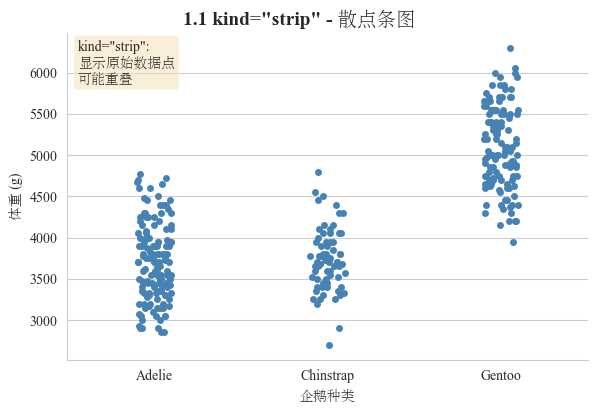

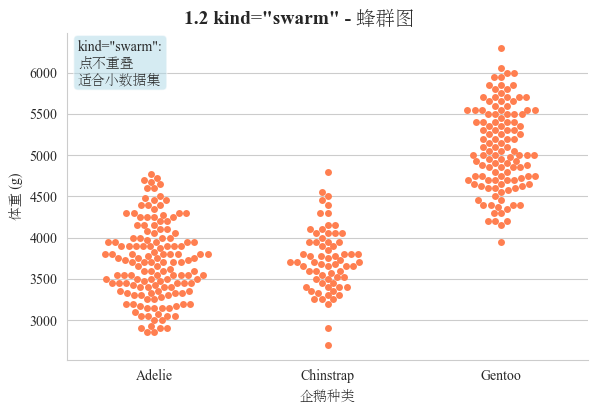

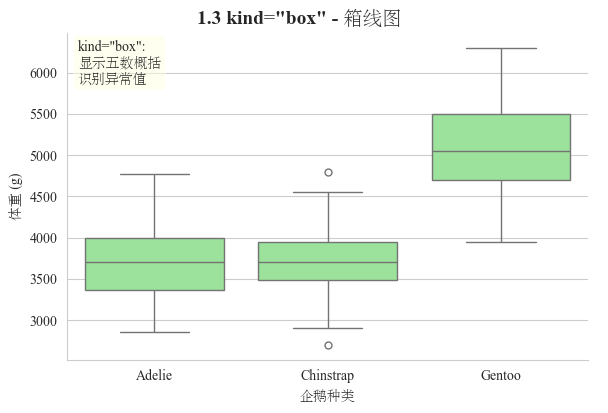

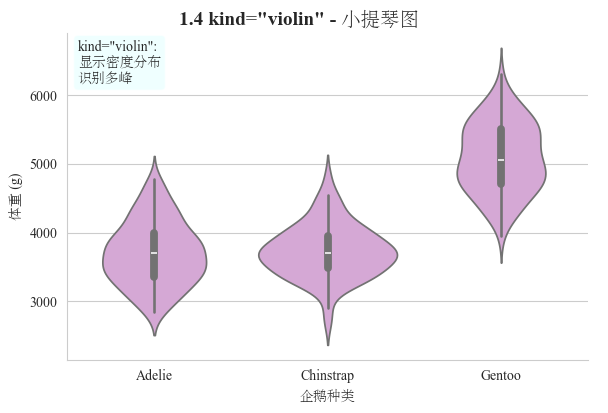

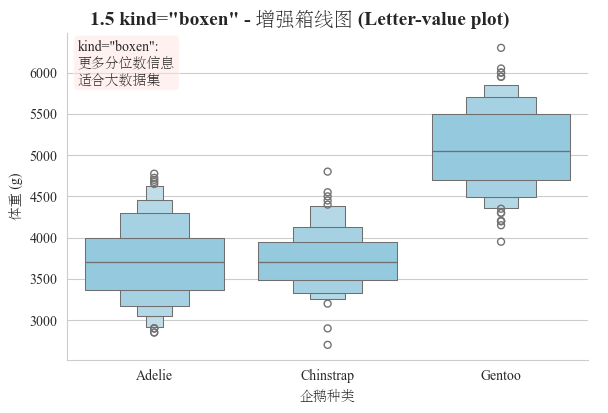

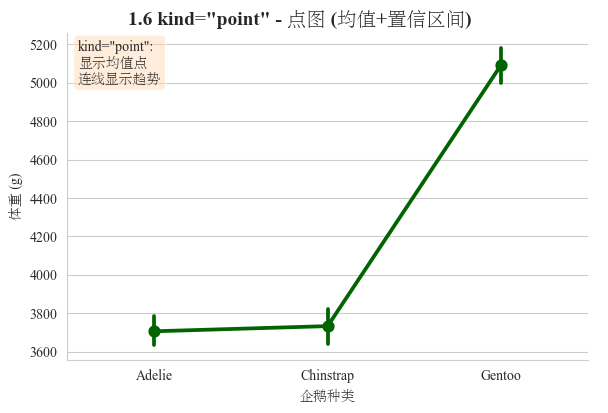

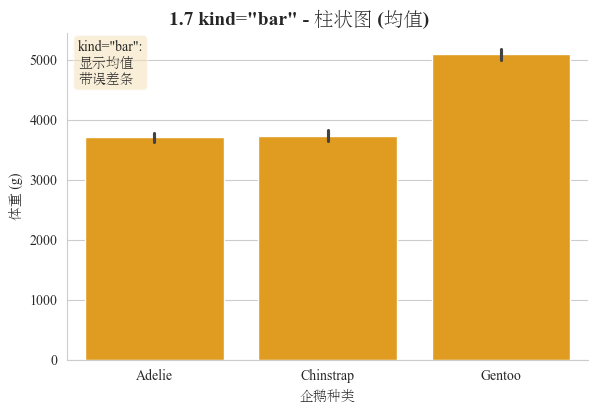

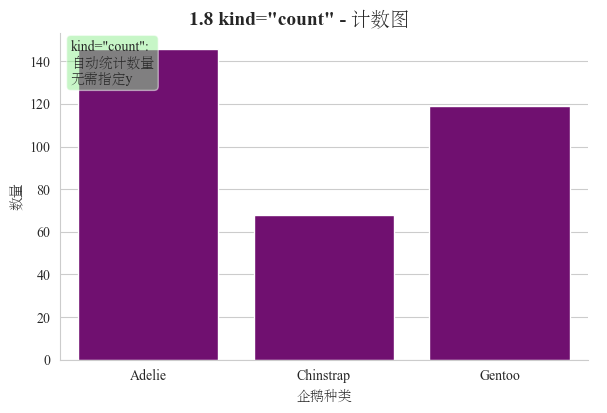

In [23]:
# ============================================================
# 画布 1: 8种kind类型演示
# ============================================================
print("画布 1: 展示8种图表类型 (kind参数)")  # 输出标题说明8种类型演示
print("-" * 60)  # 打印60个"-"分隔线

# ========== 1.1 kind='strip' ==========
g = sns.catplot(
    data=penguins,  # 数据源：企鹅数据集
    x='species',  # x轴：企鹅物种（分类变量）
    y='body_mass_g',  # y轴：体重（数值变量）
    kind='strip',  # kind='strip'：散点条图类型
    height=4,  # 图表高度：4英寸
    aspect=1.5,  # 宽高比：1.5（宽度=高度×1.5）
    color='steelblue')  # 单一颜色：钢蓝色
g.fig.suptitle(
    '1.1 kind="strip" - 散点条图',  # 设置图表总标题
    fontsize=14,  # 标题字体大小14
    fontweight='bold',  # 标题加粗
    y=1.02)  # 标题垂直位置：上方2%
g.set_axis_labels('企鹅种类', '体重 (g)')  # 设置x/y轴标签
g.ax.text(
    0.02,  # 文本水平位置：左边距2%
    0.98,  # 文本垂直位置：顶部98%
    'kind="strip":\n显示原始数据点\n可能重叠',  # 说明strip特点
    transform=g.ax.transAxes,  # 使用相对坐标系
    fontsize=10,  # 字体大小10
    verticalalignment='top',  # 顶部对齐
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))  # 圆角浅黄色半透明背景框
plt.show()  # 显示当前图表

# ========== 1.2 kind='swarm' ==========
g = sns.catplot(
    data=penguins,  # 数据源
    x='species',  # x轴：物种
    y='body_mass_g',  # y轴：体重
    kind='swarm',  # kind='swarm'：蜂群图类型
    height=4,  # 图表高度：4英寸
    aspect=1.5,  # 宽高比：1.5
    color='coral')  # 单一颜色：珊瑚色
g.fig.suptitle(
    '1.2 kind="swarm" - 蜂群图',  # 设置图表总标题
    fontsize=14,  # 标题字体大小14
    fontweight='bold',  # 标题加粗
    y=1.02)  # 标题位置
g.set_axis_labels('企鹅种类', '体重 (g)')  # 设置轴标签
g.ax.text(
    0.02,  # 文本位置
    0.98,
    'kind="swarm":\n点不重叠\n适合小数据集',  # 说明swarm特点
    transform=g.ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))  # 浅蓝色背景框
plt.show()  # 显示当前图表

# ========== 1.3 kind='box' ==========
g = sns.catplot(
    data=penguins,  # 数据源
    x='species',  # x轴：物种
    y='body_mass_g',  # y轴：体重
    kind='box',  # kind='box'：箱线图类型
    height=4,  # 图表高度：4英寸
    aspect=1.5,  # 宽高比：1.5
    color='lightgreen')  # 单一颜色：浅绿色
g.fig.suptitle(
    '1.3 kind="box" - 箱线图',  # 设置图表总标题
    fontsize=14,  # 标题字体大小14
    fontweight='bold',  # 标题加粗
    y=1.02)  # 标题位置
g.set_axis_labels('企鹅种类', '体重 (g)')  # 设置轴标签
g.ax.text(
    0.02,  # 文本位置
    0.98,
    'kind="box":\n显示五数概括\n识别异常值',  # 说明box特点（最小值、Q1、中位数、Q3、最大值）
    transform=g.ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))  # 浅黄色背景框
plt.show()  # 显示当前图表

# ========== 1.4 kind='violin' ==========
g = sns.catplot(
    data=penguins,  # 数据源
    x='species',  # x轴：物种
    y='body_mass_g',  # y轴：体重
    kind='violin',  # kind='violin'：小提琴图类型
    height=4,  # 图表高度：4英寸
    aspect=1.5,  # 宽高比：1.5
    color='plum')  # 单一颜色：梅子色
g.fig.suptitle(
    '1.4 kind="violin" - 小提琴图',  # 设置图表总标题
    fontsize=14,  # 标题字体大小14
    fontweight='bold',  # 标题加粗
    y=1.02)  # 标题位置
g.set_axis_labels('企鹅种类', '体重 (g)')  # 设置轴标签
g.ax.text(
    0.02,  # 文本位置
    0.98,
    'kind="violin":\n显示密度分布\n识别多峰',  # 说明violin特点（核密度估计）
    transform=g.ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.5))  # 浅青色背景框
plt.show()  # 显示当前图表

# ========== 1.5 kind='boxen' ==========
g = sns.catplot(
    data=penguins,  # 数据源
    x='species',  # x轴：物种
    y='body_mass_g',  # y轴：体重
    kind='boxen',  # kind='boxen'：增强箱线图类型（Letter-value plot）
    height=4,  # 图表高度：4英寸
    aspect=1.5,  # 宽高比：1.5
    color='skyblue')  # 单一颜色：天蓝色
g.fig.suptitle(
    '1.5 kind="boxen" - 增强箱线图 (Letter-value plot)',  # 设置图表总标题
    fontsize=14,  # 标题字体大小14
    fontweight='bold',  # 标题加粗
    y=1.02)  # 标题位置
g.set_axis_labels('企鹅种类', '体重 (g)')  # 设置轴标签
g.ax.text(
    0.02,  # 文本位置
    0.98,
    'kind="boxen":\n更多分位数信息\n适合大数据集',  # 说明boxen特点（显示更多分位数）
    transform=g.ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.5))  # 玫瑰色背景框
plt.show()  # 显示当前图表

# ========== 1.6 kind='point' ==========
g = sns.catplot(
    data=penguins,  # 数据源
    x='species',  # x轴：物种
    y='body_mass_g',  # y轴：体重
    kind='point',  # kind='point'：点图类型
    height=4,  # 图表高度：4英寸
    aspect=1.5,  # 宽高比：1.5
    color='darkgreen')  # 单一颜色：深绿色
g.fig.suptitle(
    '1.6 kind="point" - 点图 (均值+置信区间)',  # 设置图表总标题
    fontsize=14,  # 标题字体大小14
    fontweight='bold',  # 标题加粗
    y=1.02)  # 标题位置
g.set_axis_labels('企鹅种类', '体重 (g)')  # 设置轴标签
g.ax.text(
    0.02,  # 文本位置
    0.98,
    'kind="point":\n显示均值点\n连线显示趋势',  # 说明point特点（均值点+置信区间+趋势线）
    transform=g.ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='peachpuff', alpha=0.5))  # 桃色背景框
plt.show()  # 显示当前图表

# ========== 1.7 kind='bar' ==========
g = sns.catplot(
    data=penguins,  # 数据源
    x='species',  # x轴：物种
    y='body_mass_g',  # y轴：体重
    kind='bar',  # kind='bar'：柱状图类型
    height=4,  # 图表高度：4英寸
    aspect=1.5,  # 宽高比：1.5
    color='orange')  # 单一颜色：橙色
g.fig.suptitle(
    '1.7 kind="bar" - 柱状图 (均值)',  # 设置图表总标题
    fontsize=14,  # 标题字体大小14
    fontweight='bold',  # 标题加粗
    y=1.02)  # 标题位置
g.set_axis_labels('企鹅种类', '体重 (g)')  # 设置轴标签
g.ax.text(
    0.02,  # 文本位置
    0.98,
    'kind="bar":\n显示均值\n带误差条',  # 说明bar特点（均值柱+误差条）
    transform=g.ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))  # 浅黄色背景框
plt.show()  # 显示当前图表

# ========== 1.8 kind='count' ==========
g = sns.catplot(
    data=penguins,  # 数据源
    x='species',  # x轴：物种
    kind='count',  # kind='count'：计数图类型
    height=4,  # 图表高度：4英寸
    aspect=1.5,  # 宽高比：1.5
    color='purple')  # 单一颜色：紫色
g.fig.suptitle(
    '1.8 kind="count" - 计数图',  # 设置图表总标题
    fontsize=14,  # 标题字体大小14
    fontweight='bold',  # 标题加粗
    y=1.02)  # 标题位置
g.set_axis_labels('企鹅种类', '数量')  # 设置轴标签（y轴为数量）
g.ax.text(
    0.02,  # 文本位置
    0.98,
    'kind="count":\n自动统计数量\n无需指定y',  # 说明count特点（自动计数，无需y变量）
    transform=g.ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))  # 浅绿色背景框
plt.show()  # 显示当前图表


画布 2: hue参数 - 颜色分组
------------------------------------------------------------


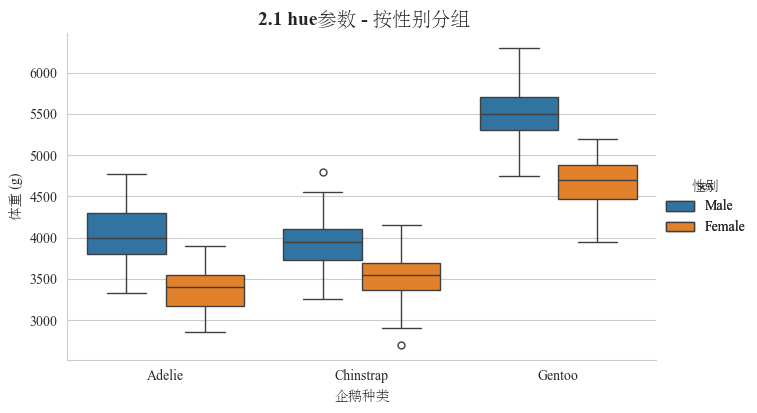

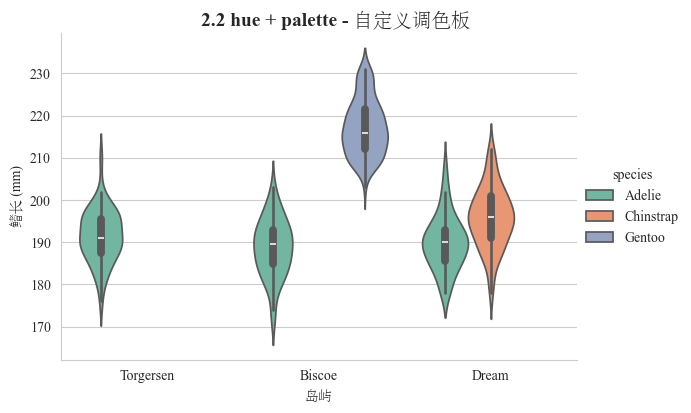

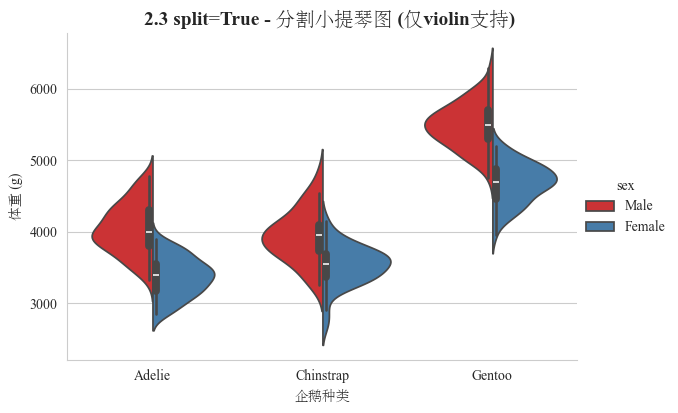

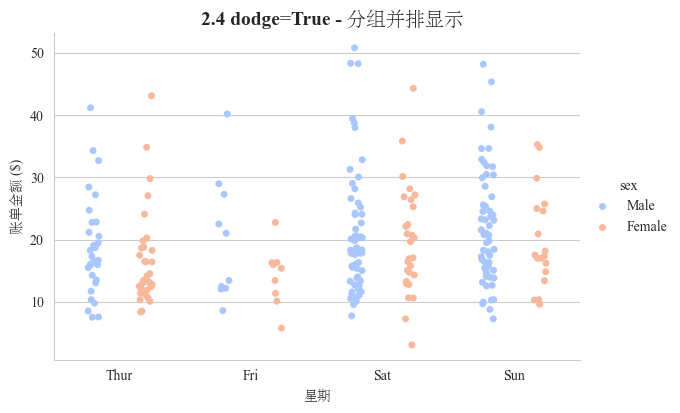

In [24]:
# ============================================================
# 画布 2: hue参数 - 颜色分组
# ============================================================
print("\n画布 2: hue参数 - 颜色分组")
print("-" * 60)

# ========== 2.1 基础hue分组 ==========
g = sns.catplot(data=penguins,
                x='species',
                y='body_mass_g',
                hue='sex',
                kind='box',
                height=4,
                aspect=1.5)
g.fig.suptitle('2.1 hue参数 - 按性别分组', fontsize=14, fontweight='bold', y=1.02)
g.set_axis_labels('企鹅种类', '体重 (g)')
g.add_legend(title='性别')
plt.show()

# ========== 2.2 hue + palette自定义颜色 ==========
g = sns.catplot(data=penguins,
                x='island',
                y='flipper_length_mm',
                hue='species',
                kind='violin',
                palette='Set2',
                height=4,
                aspect=1.5)
g.fig.suptitle('2.2 hue + palette - 自定义调色板',
               fontsize=14,
               fontweight='bold',
               y=1.02)
g.set_axis_labels('岛屿', '鳍长 (mm)')
plt.show()

# ========== 2.3 hue + split (仅violin) ==========
g = sns.catplot(data=penguins,
                x='species',
                y='body_mass_g',
                hue='sex',
                kind='violin',
                split=True,
                palette='Set1',
                height=4,
                aspect=1.5)
g.fig.suptitle('2.3 split=True - 分割小提琴图 (仅violin支持)',
               fontsize=14,
               fontweight='bold',
               y=1.02)
g.set_axis_labels('企鹅种类', '体重 (g)')
plt.show()

# ========== 2.4 hue + dodge ==========
g = sns.catplot(data=tips,
                x='day',
                y='total_bill',
                hue='sex',
                kind='strip',
                dodge=True,
                palette='coolwarm',
                height=4,
                aspect=1.5)
g.fig.suptitle('2.4 dodge=True - 分组并排显示',
               fontsize=14,
               fontweight='bold',
               y=1.02)
g.set_axis_labels('星期', '账单金额 ($)')
plt.show()


画布 2: hue参数 - 颜色分组
------------------------------------------------------------


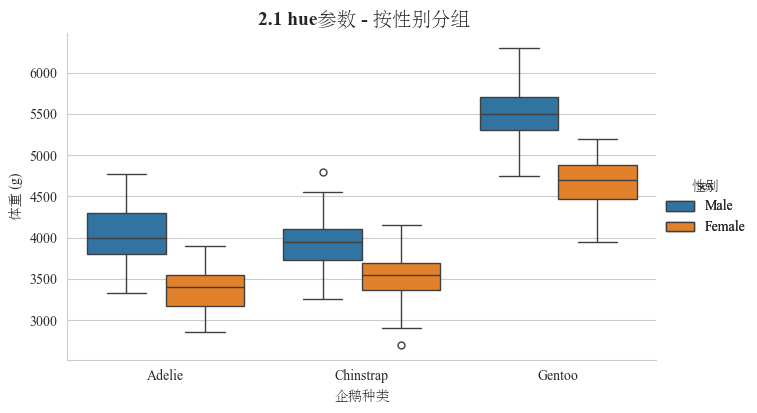

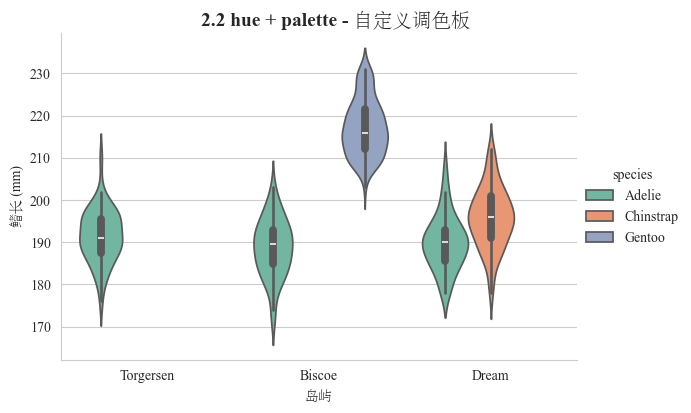

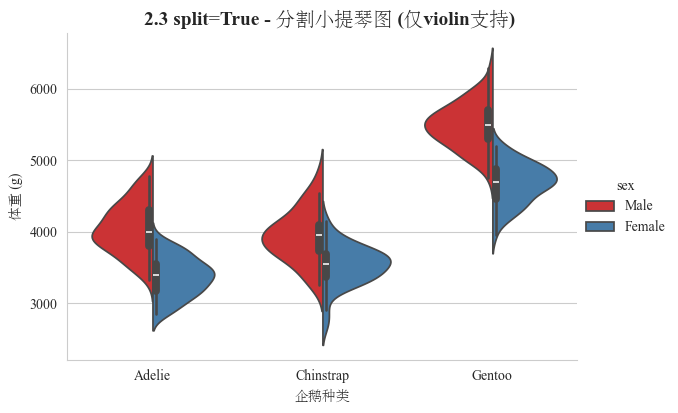

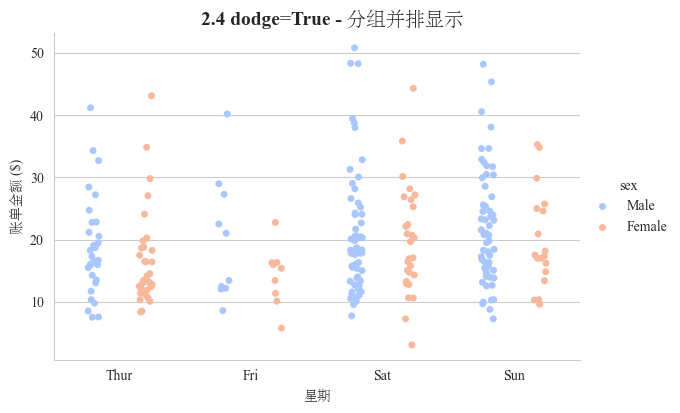

In [24]:
# ============================================================
# 画布 2: hue参数 - 颜色分组
# ============================================================
print("\n画布 2: hue参数 - 颜色分组")  # 输出标题说明hue参数功能
print("-" * 60)  # 打印60个"-"分隔线

# ========== 2.1 基础hue分组 ==========
g = sns.catplot(data=penguins,  # 数据源：企鹅数据集
                x='species',  # x轴：企鹅物种（分类变量）
                y='body_mass_g',  # y轴：体重（数值变量）
                hue='sex',  # hue='sex'：按性别分组，不同颜色区分
                kind='box',  # kind='box'：箱线图类型
                height=4,  # 图表高度：4英寸
                aspect=1.5)  # 宽高比：1.5（总宽=6英寸）
g.fig.suptitle('2.1 hue参数 - 按性别分组',  # 设置图表总标题
               fontsize=14,  # 标题字体大小14
               fontweight='bold',  # 标题加粗
               y=1.02)  # 标题垂直位置：上方2%
g.set_axis_labels('企鹅种类', '体重 (g)')  # 设置x/y轴标签
g.add_legend(title='性别')  # 添加图例，标题为"性别"
plt.show()  # 显示当前图表

# ========== 2.2 hue + palette自定义颜色 ==========
g = sns.catplot(data=penguins,  # 数据源：企鹅数据集
                x='island',  # x轴：岛屿（分类变量）
                y='flipper_length_mm',  # y轴：鳍长（数值变量）
                hue='species',  # hue='species'：按物种分组，不同颜色
                kind='violin',  # kind='violin'：小提琴图类型
                palette='Set2',  # palette='Set2'：Set2柔和色彩调色板（8种颜色）
                height=4,  # 图表高度：4英寸
                aspect=1.5)  # 宽高比：1.5
g.fig.suptitle('2.2 hue + palette - 自定义调色板',  # 设置图表总标题
               fontsize=14,  # 标题字体大小14
               fontweight='bold',  # 标题加粗
               y=1.02)  # 标题位置
g.set_axis_labels('岛屿', '鳍长 (mm)')  # 设置轴标签
plt.show()  # 显示当前图表

# ========== 2.3 hue + split (仅violin) ==========
g = sns.catplot(data=penguins,  # 数据源
                x='species',  # x轴：物种
                y='body_mass_g',  # y轴：体重
                hue='sex',  # hue='sex'：按性别分组
                kind='violin',  # kind='violin'：小提琴图类型
                split=True,  # split=True：左右分割显示（仅violin支持）
                palette='Set1',  # palette='Set1'：Set1鲜艳色彩调色板（9种颜色）
                height=4,  # 图表高度：4英寸
                aspect=1.5)  # 宽高比：1.5
g.fig.suptitle('2.3 split=True - 分割小提琴图 (仅violin支持)',  # 设置图表总标题
               fontsize=14,  # 标题字体大小14
               fontweight='bold',  # 标题加粗
               y=1.02)  # 标题位置
g.set_axis_labels('企鹅种类', '体重 (g)')  # 设置轴标签
plt.show()  # 显示当前图表

# ========== 2.4 hue + dodge ==========
g = sns.catplot(data=tips,  # 数据源：tips数据集
                x='day',  # x轴：星期（分类变量）
                y='total_bill',  # y轴：账单总额（数值变量）
                hue='sex',  # hue='sex'：按性别分组
                kind='strip',  # kind='strip'：散点条图类型
                dodge=True,  # dodge=True：不同hue组水平并排显示
                palette='coolwarm',  # palette='coolwarm'：冷暖色渐变调色板
                height=4,  # 图表高度：4英寸
                aspect=1.5)  # 宽高比：1.5
g.fig.suptitle('2.4 dodge=True - 分组并排显示',  # 设置图表总标题
               fontsize=14,  # 标题字体大小14
               fontweight='bold',  # 标题加粗
               y=1.02)  # 标题位置
g.set_axis_labels('星期', '账单金额 ($)')  # 设置轴标签
plt.show()  # 显示当前图表


画布 4: row参数 - 行分面
------------------------------------------------------------


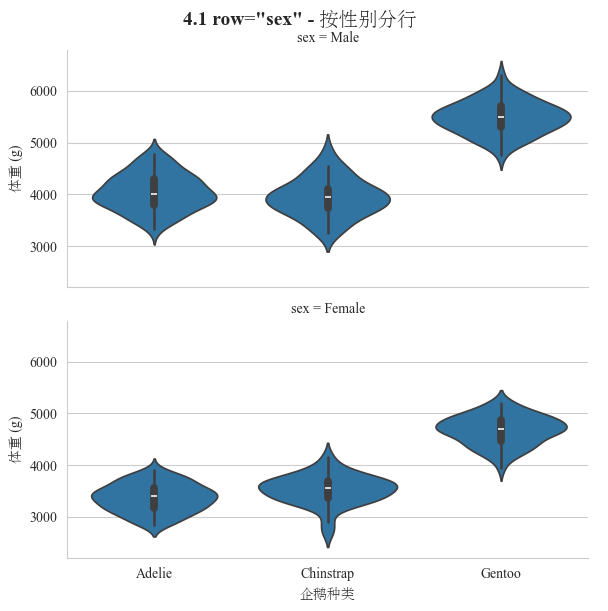

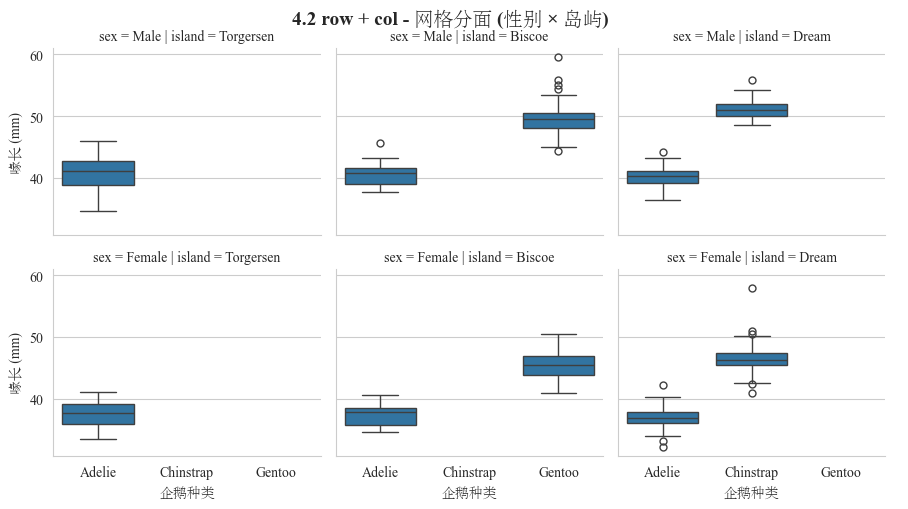

In [25]:
# ============================================================
# 画布 4: row参数 - 行分面
# ============================================================
print("\n画布 4: row参数 - 行分面")  # 输出标题说明row参数功能
print("-" * 60)  # 打印60个"-"分隔线

# ========== 4.1 基础行分面 ==========
g = sns.catplot(data=penguins,  # 数据源：企鹅数据集
                x='species',  # x轴：企鹅物种（分类变量）
                y='body_mass_g',  # y轴：体重（数值变量）
                row='sex',  # row='sex'：按性别**垂直分面**（每行一个性别）
                kind='violin',  # kind='violin'：小提琴图类型
                height=3,  # 每个子图高度：3英寸（分面时更紧凑）
                aspect=2)  # 宽高比：2（总宽=6英寸）
g.fig.suptitle('4.1 row="sex" - 按性别分行',  # 设置图表总标题
               fontsize=14,  # 标题字体大小14
               fontweight='bold',  # 标题加粗
               y=1.01)  # 标题垂直位置：上方1%
g.set_axis_labels('企鹅种类', '体重 (g)')  # 设置所有子图的x/y轴标签
plt.show()  # 显示当前图表（2行×1列网格）

# ========== 4.2 row + col网格分面 ==========
g = sns.catplot(data=penguins,  # 数据源：企鹅数据集
                x='species',  # x轴：企鹅物种（分类变量）
                y='bill_length_mm',  # y轴：喙长（数值变量）
                row='sex',  # row='sex'：按性别**垂直分面**（2行）
                col='island',  # col='island'：按岛屿**水平分面**（3列）
                kind='box',  # kind='box'：箱线图类型
                height=2.5,  # 每个子图高度：2.5英寸（多分面更紧凑）
                aspect=1.2)  # 宽高比：1.2（总宽=3英寸）
g.fig.suptitle('4.2 row + col - 网格分面 (性别 × 岛屿)',  # 设置图表总标题
               fontsize=14,  # 标题字体大小14
               fontweight='bold',  # 标题加粗
               y=1.01)  # 标题位置
g.set_axis_labels('企鹅种类', '喙长 (mm)')  # 设置所有子图的轴标签
plt.show()  # 显示当前图表（2行×3列=6个子图网格）


画布 5: height和aspect - 控制图表大小
------------------------------------------------------------


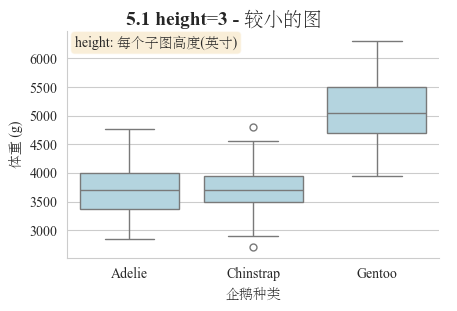

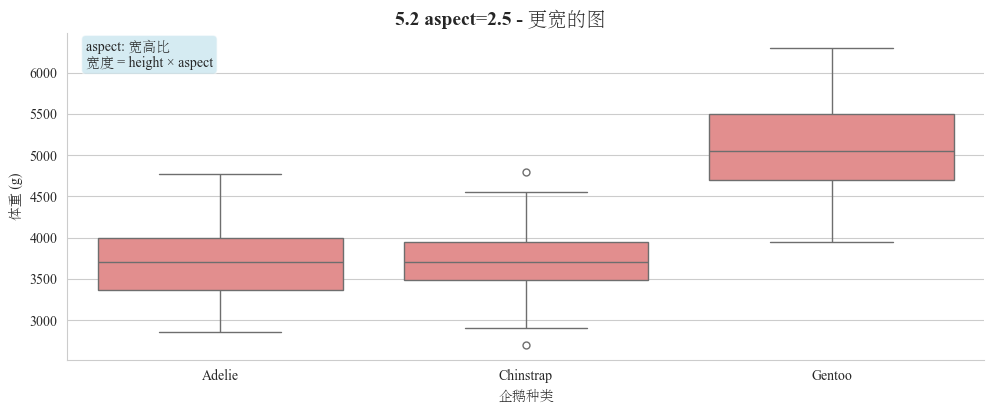

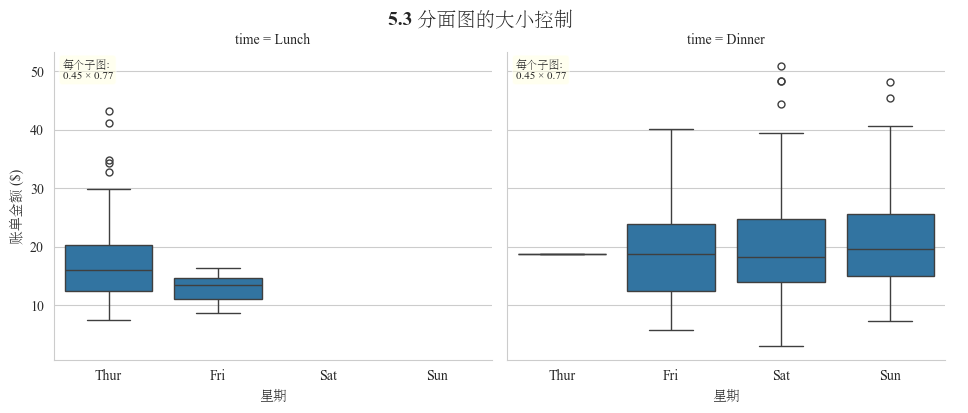

In [26]:
# ============================================================
# 画布 5: height和aspect - 控制大小
# ============================================================
print("\n画布 5: height和aspect - 控制图表大小")  # 输出标题说明大小控制参数
print("-" * 60)  # 打印60个"-"分隔线

# ========== 5.1 调整height ==========
g = sns.catplot(
    data=penguins,  # 数据源：企鹅数据集
    x='species',  # x轴：企鹅物种（分类变量）
    y='body_mass_g',  # y轴：体重（数值变量）
    kind='box',  # kind='box'：箱线图类型
    height=3,  # height=3：每个子图高度3英寸（默认5）
    aspect=1.5,  # aspect=1.5：宽高比1.5（总宽度=3×1.5=4.5英寸）
    color='lightblue')  # 单一颜色：浅蓝色
g.fig.suptitle(
    '5.1 height=3 - 较小的图',  # 设置图表总标题
    fontsize=14,  # 标题字体大小14
    fontweight='bold',  # 标题加粗
    y=1.02)  # 标题垂直位置：上方2%
g.set_axis_labels('企鹅种类', '体重 (g)')  # 设置x/y轴标签
g.ax.text(
    0.02,  # 文本水平位置：左边距2%
    0.98,  # 文本垂直位置：顶部98%
    'height: 每个子图高度(英寸)',  # 说明height参数作用
    transform=g.ax.transAxes,  # 使用相对坐标系
    fontsize=10,  # 字体大小10
    verticalalignment='top',  # 顶部对齐
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))  # 圆角浅黄色半透明背景框
plt.show()  # 显示当前图表（总尺寸：4.5×3英寸）

# ========== 5.2 调整aspect ==========
g = sns.catplot(
    data=penguins,  # 数据源
    x='species',  # x轴：物种
    y='body_mass_g',  # y轴：体重
    kind='box',  # 箱线图类型
    height=4,  # height=4：每个子图高度4英寸
    aspect=2.5,  # aspect=2.5：宽高比2.5（总宽度=4×2.5=10英寸）
    color='lightcoral')  # 单一颜色：浅珊瑚色
g.fig.suptitle(
    '5.2 aspect=2.5 - 更宽的图',  # 设置图表总标题
    fontsize=14,  # 标题字体大小14
    fontweight='bold',  # 标题加粗
    y=1.02)  # 标题位置
g.set_axis_labels('企鹅种类', '体重 (g)')  # 设置轴标签
g.ax.text(
    0.02,  # 文本位置
    0.98,
    'aspect: 宽高比\n宽度 = height × aspect',  # 说明aspect计算公式
    transform=g.ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))  # 浅蓝色背景框
plt.show()  # 显示当前图表（总尺寸：10×4英寸）

# ========== 5.3 分面时的大小控制 ==========
g = sns.catplot(
    data=tips,  # 数据源：tips数据集
    x='day',  # x轴：星期（分类变量）
    y='total_bill',  # y轴：账单总额（数值变量）
    col='time',  # col='time'：按时间段水平分面（午餐/晚餐=2列）
    kind='box',  # kind='box'：箱线图类型
    height=4,  # height=4：每个子图高度4英寸
    aspect=1.2)  # aspect=1.2：每个子图宽高比1.2（每个子图宽=4×1.2=4.8英寸）
g.fig.suptitle(
    '5.3 分面图的大小控制',  # 设置图表总标题
    fontsize=14,  # 标题字体大小14
    fontweight='bold',  # 标题加粗
    y=1.02)  # 标题位置
g.set_axis_labels('星期', '账单金额 ($)')  # 设置所有子图的轴标签
for ax in g.axes.flat:  # 遍历所有子图（2列）
    ax.text(
        0.02,  # 文本位置
        0.98,
        f'每个子图:\n{ax.get_position().width:.2f} × {ax.get_position().height:.2f}',  # 显示实际子图尺寸
        transform=ax.transAxes,
        fontsize=8,  # 字体8（较小）
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow',
                  alpha=0.5))  # 浅黄色背景框
plt.show()  # 显示当前图表（总尺寸：9.6×4英寸，2个子图并排）


画布 6: sharey和sharex - 坐标轴共享
------------------------------------------------------------


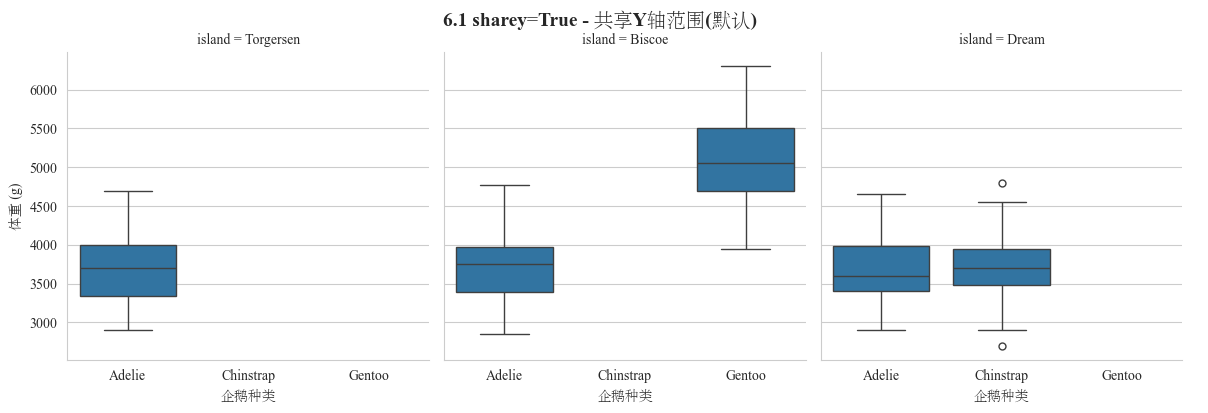

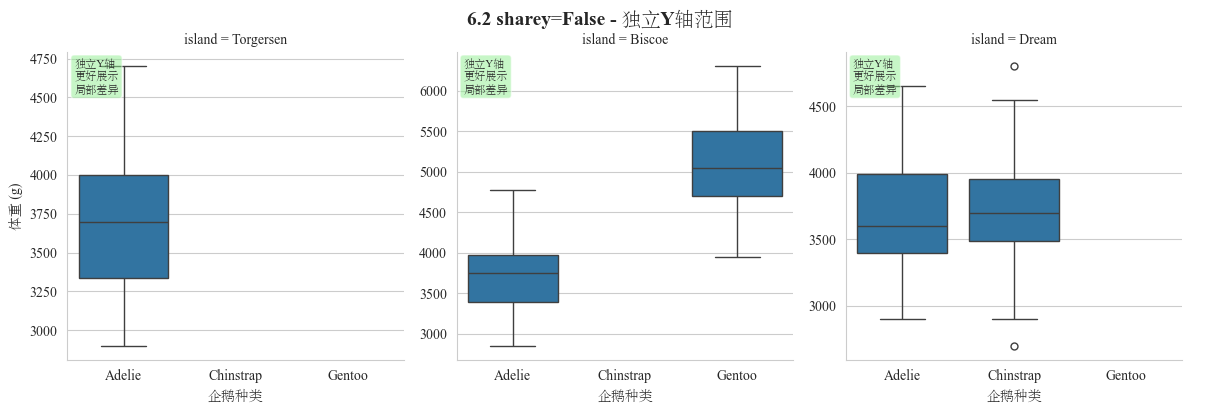

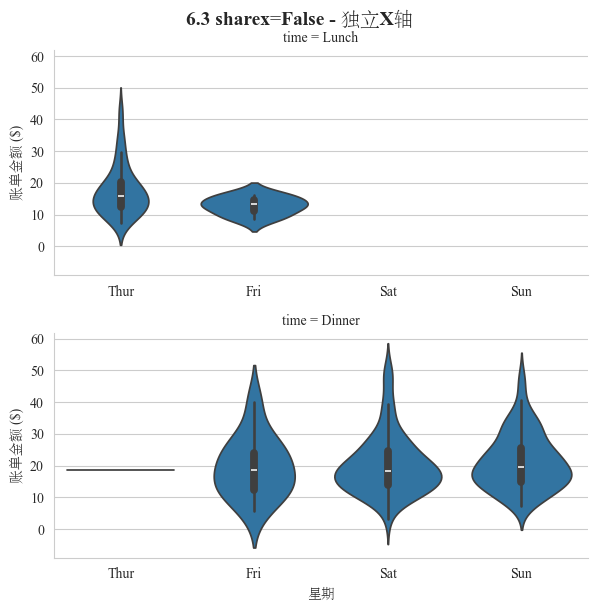

In [27]:
# ============================================================
# 画布 6: sharey和sharex - 坐标轴共享
# ============================================================
print("\n画布 6: sharey和sharex - 坐标轴共享")  # 输出标题说明坐标轴共享参数
print("-" * 60)  # 打印60个"-"分隔线

# ========== 6.1 sharey=True (默认) ==========
g = sns.catplot(
    data=penguins,  # 数据源：企鹅数据集
    x='species',  # x轴：企鹅物种（分类变量）
    y='body_mass_g',  # y轴：体重（数值变量）
    col='island',  # col='island'：按岛屿水平分面（3列）
    kind='box',  # kind='box'：箱线图类型
    sharey=True,  # sharey=True：**所有子图共享Y轴范围**（默认值）
    height=4,  # 每个子图高度：4英寸
    aspect=1)  # 每个子图宽高比：1（正方形，宽=4英寸）
g.fig.suptitle(
    '6.1 sharey=True - 共享Y轴范围(默认)',  # 设置图表总标题
    fontsize=14,  # 标题字体大小14
    fontweight='bold',  # 标题加粗
    y=1.02)  # 标题垂直位置：上方2%
g.set_axis_labels('企鹅种类', '体重 (g)')  # 设置所有子图的x/y轴标签
plt.show()  # 显示当前图表（总尺寸：12×4英寸，3个子图共享Y轴）

# ========== 6.2 sharey=False ==========
g = sns.catplot(
    data=penguins,  # 数据源
    x='species',  # x轴：物种
    y='body_mass_g',  # y轴：体重
    col='island',  # col='island'：3列分面
    kind='box',  # 箱线图类型
    sharey=False,  # sharey=False：**每个子图独立Y轴范围**
    height=4,  # 每个子图高度：4英寸
    aspect=1)  # 每个子图宽高比：1
g.fig.suptitle(
    '6.2 sharey=False - 独立Y轴范围',  # 设置图表总标题
    fontsize=14,  # 标题字体大小14
    fontweight='bold',  # 标题加粗
    y=1.02)  # 标题位置
g.set_axis_labels('企鹅种类', '体重 (g)')  # 设置轴标签
for ax in g.axes.flat:  # 遍历所有3个子图
    ax.text(
        0.02,  # 文本水平位置：左边距2%
        0.98,  # 文本垂直位置：顶部98%
        '独立Y轴\n更好展示\n局部差异',  # 说明独立Y轴优势
        transform=ax.transAxes,  # 使用相对坐标系
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 顶部对齐
        bbox=dict(boxstyle='round', facecolor='lightgreen',
                  alpha=0.5))  # 圆角浅绿色半透明背景框
plt.show()  # 显示当前图表（3个子图各有独立Y轴范围）

# ========== 6.3 sharex=False ==========
g = sns.catplot(
    data=tips,  # 数据源：tips数据集
    x='day',  # x轴：星期（分类变量）
    y='total_bill',  # y轴：账单总额（数值变量）
    row='time',  # row='time'：按时间段垂直分面（2行：午餐/晚餐）
    kind='violin',  # kind='violin'：小提琴图类型
    sharex=False,  # sharex=False：**每个子图独立X轴范围**
    height=3,  # 每个子图高度：3英寸
    aspect=2)  # 每个子图宽高比：2（宽=6英寸）
g.fig.suptitle(
    '6.3 sharex=False - 独立X轴',  # 设置图表总标题
    fontsize=14,  # 标题字体大小14
    fontweight='bold',  # 标题加粗
    y=1.01)  # 标题位置（垂直分面调整为1.01）
g.set_axis_labels('星期', '账单金额 ($)')  # 设置所有子图的轴标签
plt.show()  # 显示当前图表（总尺寸：6×6英寸，2个子图独立X轴）


画布 7: margin_titles - 边缘标题
------------------------------------------------------------


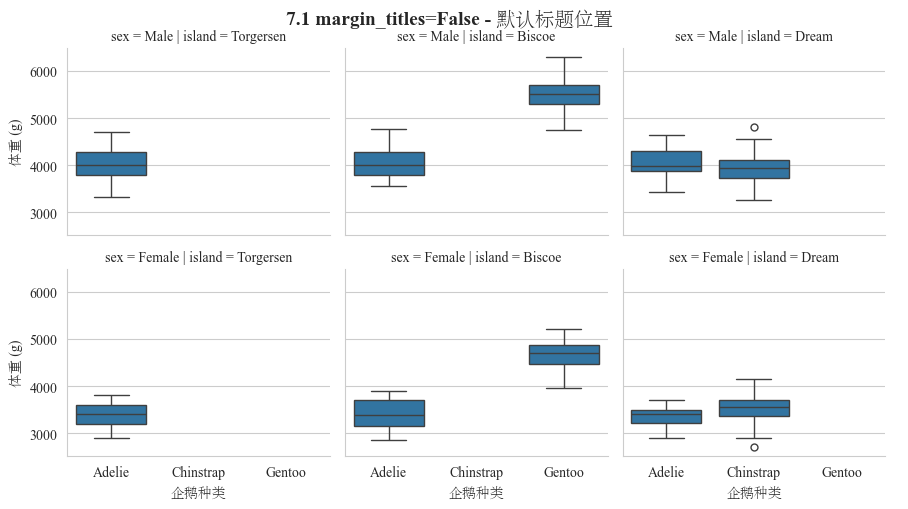

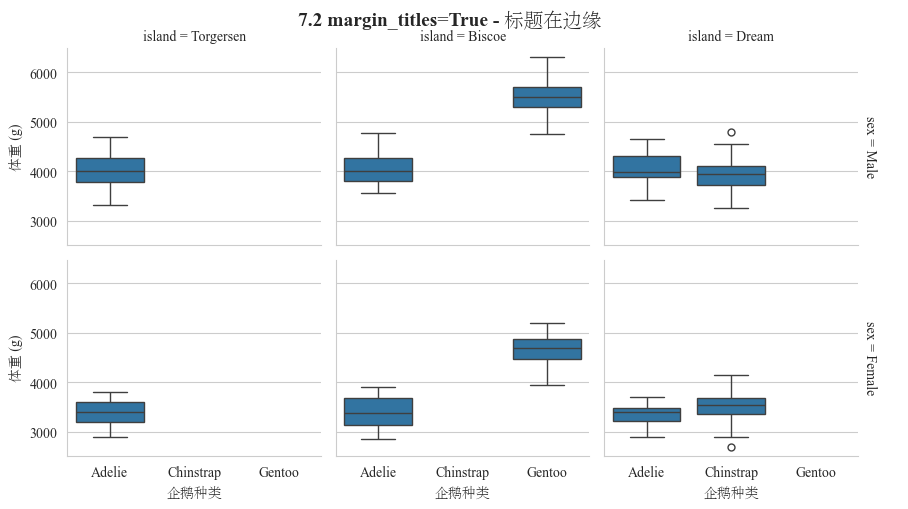

In [28]:
# ============================================================
# 画布 7: margin_titles - 边缘标题
# ============================================================
print("\n画布 7: margin_titles - 边缘标题")  # 输出标题说明边缘标题参数
print("-" * 60)  # 打印60个"-"分隔线

# ========== 7.1 margin_titles=False (默认) ==========
g = sns.catplot(data=penguins,  # 数据源：企鹅数据集
                x='species',  # x轴：企鹅物种（分类变量）
                y='body_mass_g',  # y轴：体重（数值变量）
                col='island',  # col='island'：按岛屿水平分面（3列）
                row='sex',  # row='sex'：按性别垂直分面（2行）
                kind='box',  # kind='box'：箱线图类型
                margin_titles=False,  # margin_titles=False：**分面标题显示在每个子图内部**（默认值）
                height=2.5,  # 每个子图高度：2.5英寸（6子图紧凑布局）
                aspect=1.2)  # 每个子图宽高比：1.2（每个子图宽=3英寸）
g.fig.suptitle('7.1 margin_titles=False - 默认标题位置',  # 设置图表总标题
               fontsize=14,  # 标题字体大小14
               fontweight='bold',  # 标题加粗
               y=1.01)  # 标题垂直位置：上方1%（多行分面调整）
g.set_axis_labels('企鹅种类', '体重 (g)')  # 设置所有子图的x/y轴标签
plt.show()  # 显示当前图表（总尺寸：9×5英寸，2×3网格，每个子图有独立标题）

# ========== 7.2 margin_titles=True ==========
g = sns.catplot(data=penguins,  # 数据源
                x='species',  # x轴：物种
                y='body_mass_g',  # y轴：体重
                col='island',  # col='island'：3列分面
                row='sex',  # row='sex'：2行分面
                kind='box',  # 箱线图类型
                margin_titles=True,  # margin_titles=True：**分面标题移到网格边缘**（行标题在左侧，列标题在上方）
                height=2.5,  # 每个子图高度：2.5英寸
                aspect=1.2)  # 每个子图宽高比：1.2
g.fig.suptitle('7.2 margin_titles=True - 标题在边缘',  # 设置图表总标题
               fontsize=14,  # 标题字体大小14
               fontweight='bold',  # 标题加粗
               y=1.01)  # 标题位置
g.set_axis_labels('企鹅种类', '体重 (g)')  # 设置轴标签
plt.show()  # 显示当前图表（总尺寸略大，边缘标题节省子图空间）


画布 8: legend参数 - 图例控制
------------------------------------------------------------


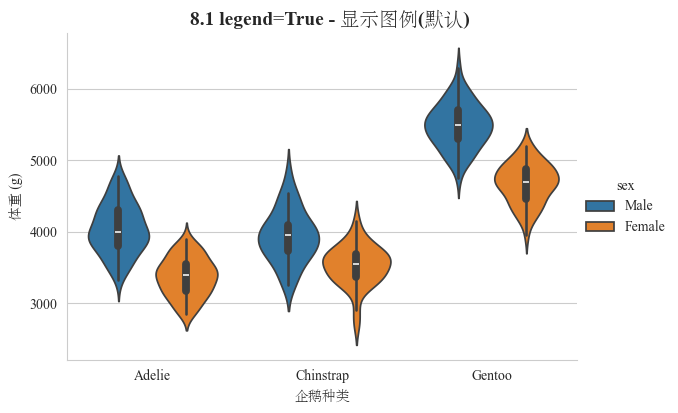

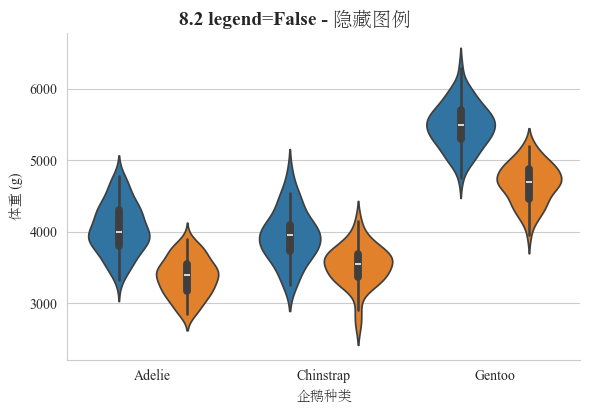

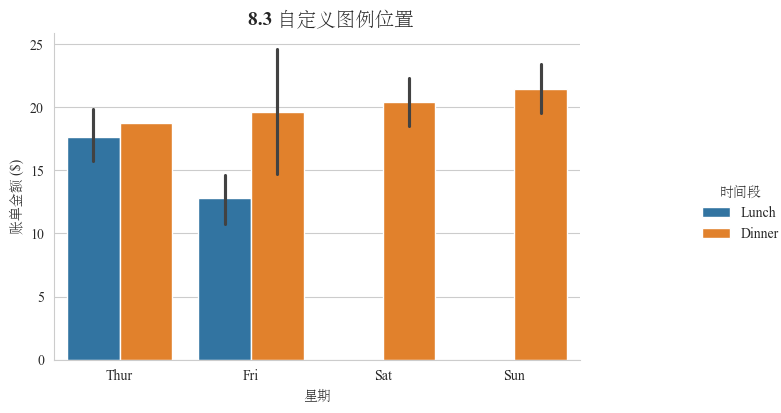

In [29]:
# ============================================================
# 画布 8: legend参数 - 图例控制
# ============================================================
print("\n画布 8: legend参数 - 图例控制")  # 输出标题说明图例控制参数
print("-" * 60)  # 打印60个"-"分隔线

# ========== 8.1 legend=True (默认) ==========
g = sns.catplot(data=penguins,  # 数据源：企鹅数据集
                x='species',  # x轴：企鹅物种（分类变量）
                y='body_mass_g',  # y轴：体重（数值变量）
                hue='sex',  # hue='sex'：按性别分组，不同颜色
                kind='violin',  # kind='violin'：小提琴图类型
                legend=True,  # legend=True：**显示图例**（默认值）
                height=4,  # 每个子图高度：4英寸
                aspect=1.5)  # 每个子图宽高比：1.5（总宽=6英寸）
g.fig.suptitle('8.1 legend=True - 显示图例(默认)',  # 设置图表总标题
               fontsize=14,  # 标题字体大小14
               fontweight='bold',  # 标题加粗
               y=1.02)  # 标题垂直位置：上方2%
g.set_axis_labels('企鹅种类', '体重 (g)')  # 设置x/y轴标签
plt.show()  # 显示当前图表（图例默认位置：右上角）

# ========== 8.2 legend=False ==========
g = sns.catplot(data=penguins,  # 数据源
                x='species',  # x轴：物种
                y='body_mass_g',  # y轴：体重
                hue='sex',  # hue='sex'：按性别分组
                kind='violin',  # 小提琴图类型
                legend=False,  # legend=False：**完全隐藏图例**
                height=4,  # 每个子图高度：4英寸
                aspect=1.5)  # 每个子图宽高比：1.5
g.fig.suptitle('8.2 legend=False - 隐藏图例',  # 设置图表总标题
               fontsize=14,  # 标题字体大小14
               fontweight='bold',  # 标题加粗
               y=1.02)  # 标题位置
g.set_axis_labels('企鹅种类', '体重 (g)')  # 设置轴标签
plt.show()  # 显示当前图表（无图例，节省15%空间）

# ========== 8.3 自定义图例位置 ==========
g = sns.catplot(data=tips,  # 数据源：tips数据集
                x='day',  # x轴：星期（分类变量）
                y='total_bill',  # y轴：账单总额（数值变量）
                hue='time',  # hue='time'：按时间段分组（午餐/晚餐）
                kind='bar',  # kind='bar'：柱状图类型
                height=4,  # 每个子图高度：4英寸
                aspect=1.5)  # 每个子图宽高比：1.5（默认显示图例）
g.fig.suptitle('8.3 自定义图例位置',  # 设置图表总标题
               fontsize=14,  # 标题字体大小14
               fontweight='bold',  # 标题加粗
               y=1.02)  # 标题位置
g.set_axis_labels('星期', '账单金额 ($)')  # 设置轴标签
# 调整图例位置
g.legend.set_bbox_to_anchor((1.15, 0.5))  # set_bbox_to_anchor((1.15, 0.5))：图例位置（x=右外15%，y=垂直居中）
g.legend.set_title('时间段')  # set_title('时间段')：图例标题自定义
plt.show()  # 显示当前图表（图例移到右外侧垂直居中）


画布 9: 传递特定图表参数
------------------------------------------------------------


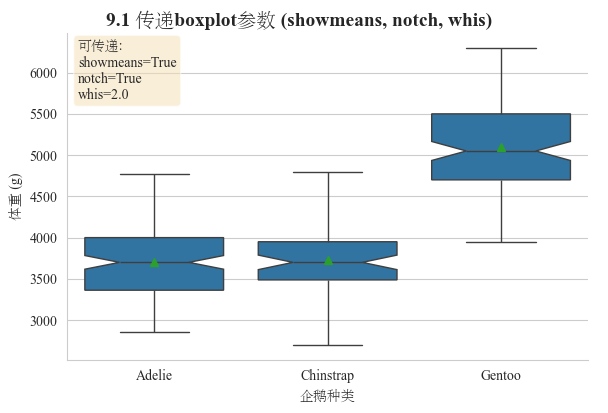

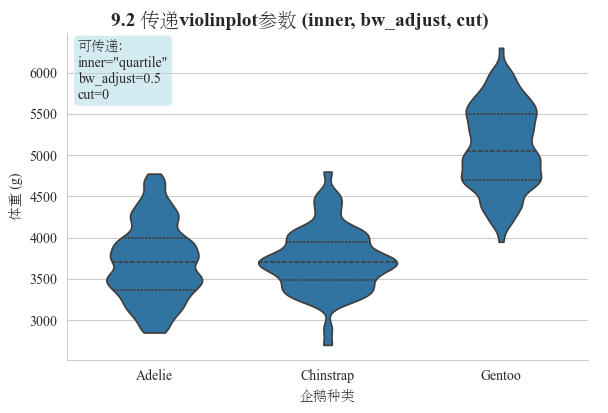

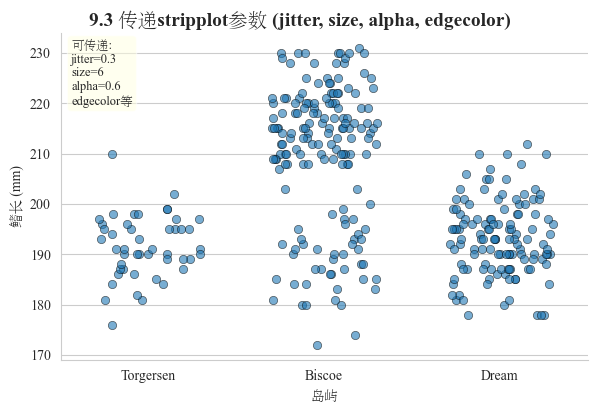

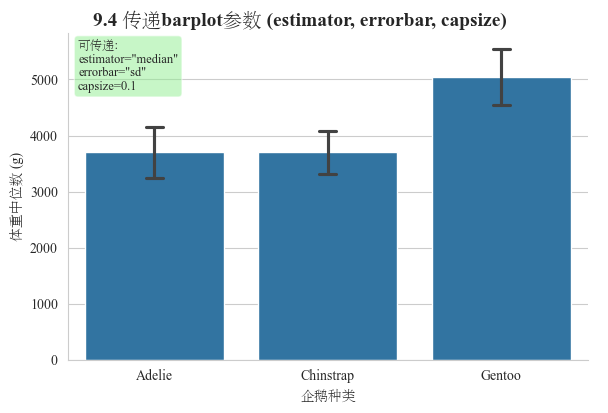


画布 10: 综合应用案例
------------------------------------------------------------


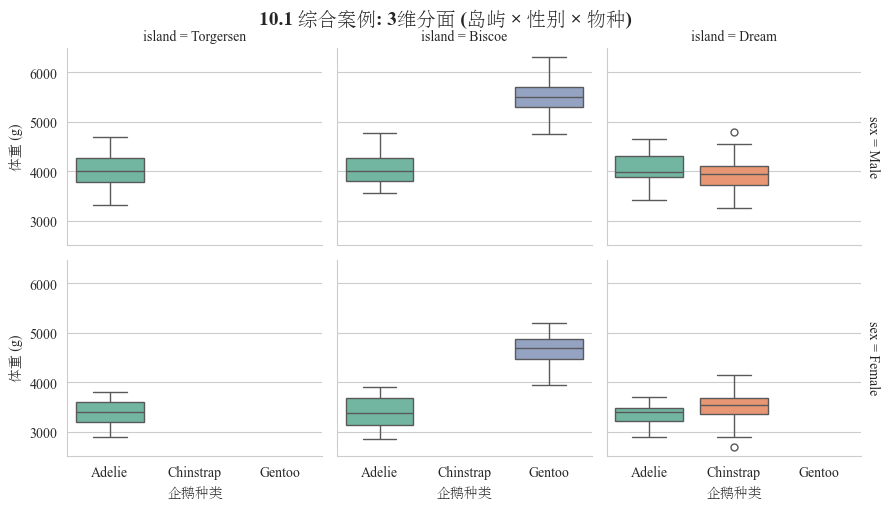

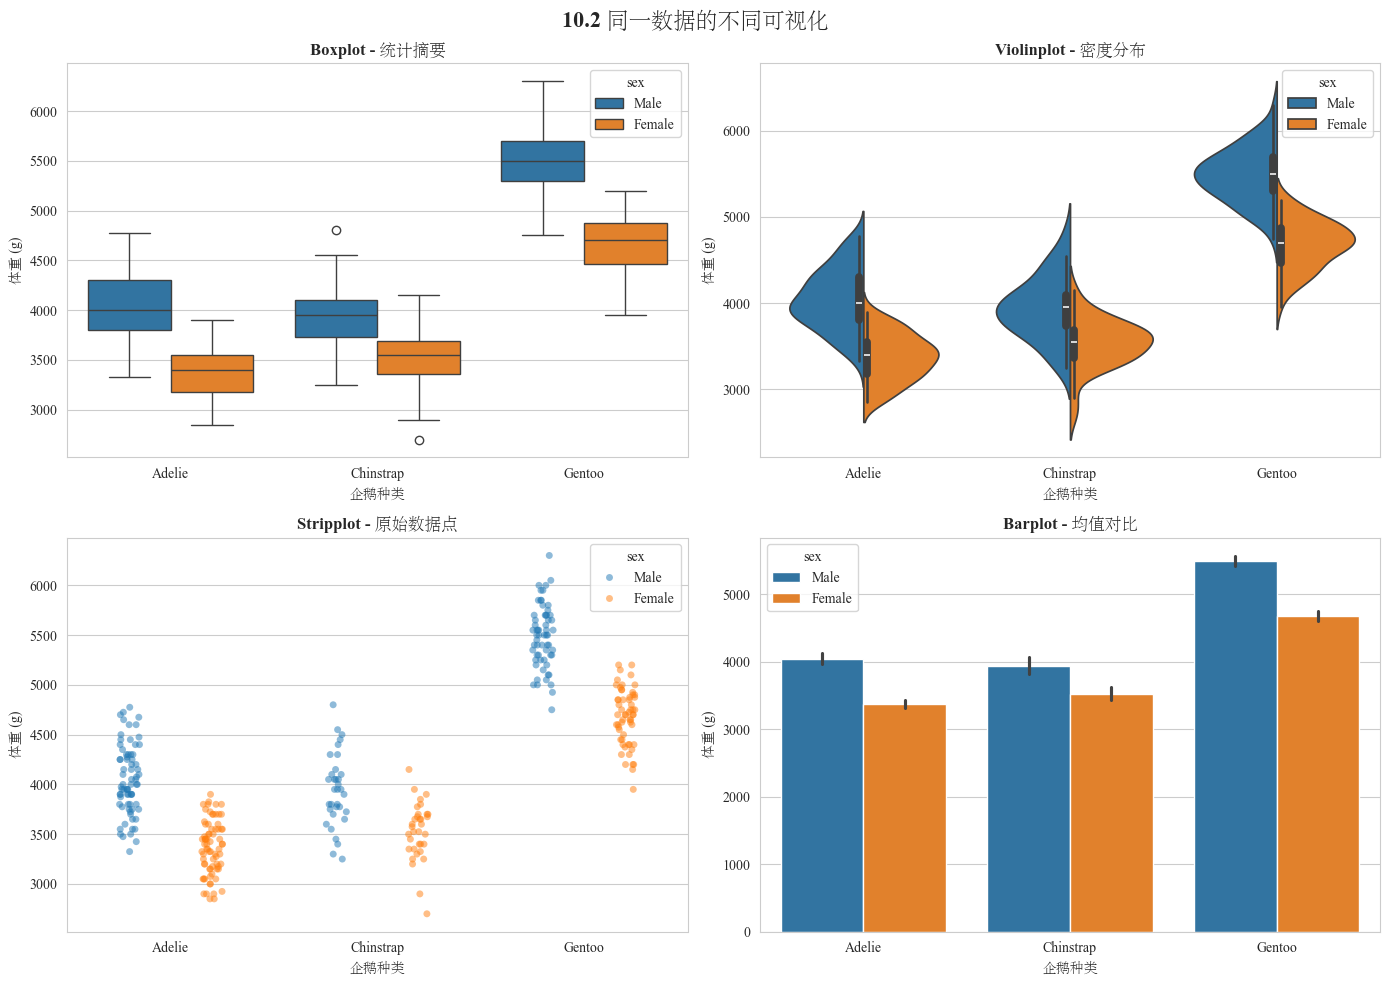

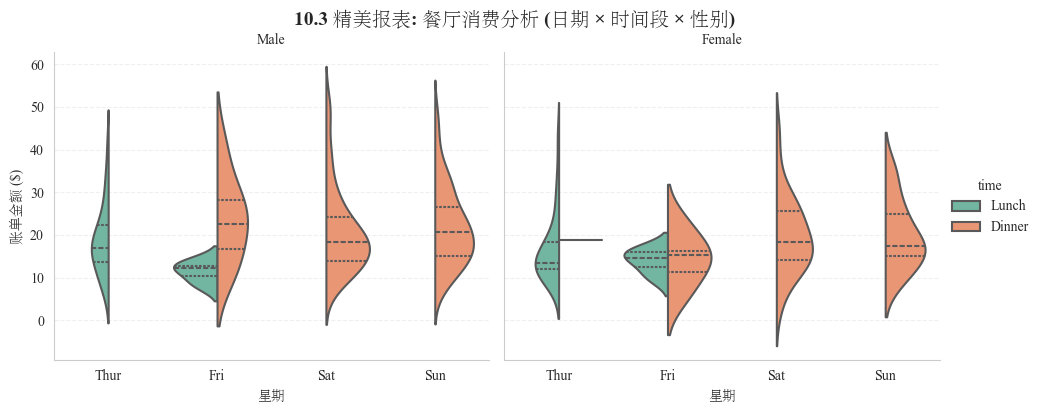

In [30]:
# ============================================================
# 画布 9: 传递特定图表参数
# ============================================================
print("\n画布 9: 传递特定图表参数")  # 输出标题说明传递特定参数功能
print("-" * 60)  # 打印60个"-"分隔线

# ========== 9.1 传递box参数 ==========
g = sns.catplot(data=penguins,  # 数据源：企鹅数据集
                x='species',  # x轴：企鹅物种（分类变量）
                y='body_mass_g',  # y轴：体重（数值变量）
                kind='box',  # kind='box'：箱线图类型
                height=4,  # 每个子图高度：4英寸
                aspect=1.5,  # 每个子图宽高比：1.5（总宽=6英寸）
                showmeans=True,  # showmeans=True：**显示均值点**（默认显示中位数）
                notch=True,  # notch=True：**箱体中部显示置信区间缺口**
                whis=2.0)  # whis=2.0：**须范围为2倍IQR**（默认1.5倍）
g.fig.suptitle('9.1 传递boxplot参数 (showmeans, notch, whis)',  # 设置图表总标题
               fontsize=14,  # 标题字体大小14
               fontweight='bold',  # 标题加粗
               y=1.02)  # 标题垂直位置：上方2%
g.set_axis_labels('企鹅种类', '体重 (g)')  # 设置x/y轴标签
g.ax.text(0.02,  # 文本水平位置：左边距2%
          0.98,  # 文本垂直位置：顶部98%
          '可传递:\nshowmeans=True\nnotch=True\nwhis=2.0',  # 说明3个boxplot参数
          transform=g.ax.transAxes,  # 使用相对坐标系
          fontsize=10,  # 字体大小10
          verticalalignment='top',  # 顶部对齐
          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))  # 圆角浅黄色半透明背景框
plt.show()  # 显示当前图表

# ========== 9.2 传递violin参数 ==========
g = sns.catplot(data=penguins,  # 数据源
                x='species',  # x轴：物种
                y='body_mass_g',  # y轴：体重
                kind='violin',  # kind='violin'：小提琴图类型
                height=4,  # 每个子图高度：4英寸
                aspect=1.5,  # 每个子图宽高比：1.5
                inner='quartile',  # inner='quartile'：**内部显示四分位线**（默认None）
                bw_adjust=0.5,  # bw_adjust=0.5：**带宽调整为0.5倍**（默认1.0，更平滑）
                cut=0)  # cut=0：**无限扩展密度**（默认2，裁剪到±2标准差）
g.fig.suptitle('9.2 传递violinplot参数 (inner, bw_adjust, cut)',  # 设置图表总标题
               fontsize=14,  # 标题字体大小14
               fontweight='bold',  # 标题加粗
               y=1.02)  # 标题位置
g.set_axis_labels('企鹅种类', '体重 (g)')  # 设置轴标签
g.ax.text(0.02,  # 文本位置
          0.98,
          '可传递:\ninner="quartile"\nbw_adjust=0.5\ncut=0',  # 说明3个violinplot参数
          transform=g.ax.transAxes,
          fontsize=10,
          verticalalignment='top',
          bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))  # 浅蓝色背景框
plt.show()  # 显示当前图表

# ========== 9.3 传递strip/swarm参数 ==========
g = sns.catplot(data=penguins,  # 数据源
                x='island',  # x轴：岛屿（分类变量）
                y='flipper_length_mm',  # y轴：鳍长（数值变量）
                kind='strip',  # kind='strip'：散点条图类型
                height=4,  # 每个子图高度：4英寸
                aspect=1.5,  # 每个子图宽高比：1.5
                jitter=0.3,  # jitter=0.3：**水平抖动0.3**（默认0.2）
                size=6,  # size=6：**点大小6**（默认5）
                alpha=0.6,  # alpha=0.6：**透明度60%**
                edgecolor='black',  # edgecolor='black'：**黑色边框**
                linewidth=0.5)  # linewidth=0.5：**边框线宽0.5点**
g.fig.suptitle('9.3 传递stripplot参数 (jitter, size, alpha, edgecolor)',  # 设置图表总标题
               fontsize=14,  # 标题字体大小14
               fontweight='bold',  # 标题加粗
               y=1.02)  # 标题位置
g.set_axis_labels('岛屿', '鳍长 (mm)')  # 设置轴标签
g.ax.text(0.02,  # 文本位置
          0.98,
          '可传递:\njitter=0.3\nsize=6\nalpha=0.6\nedgecolor等',  # 说明4个stripplot参数
          transform=g.ax.transAxes,
          fontsize=9,  # 字体大小9
          verticalalignment='top',
          bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))  # 浅黄色背景框
plt.show()  # 显示当前图表

# ========== 9.4 传递bar参数 ==========
g = sns.catplot(data=penguins,  # 数据源
                x='species',  # x轴：物种
                y='body_mass_g',  # y轴：体重
                kind='bar',  # kind='bar'：柱状图类型
                height=4,  # 每个子图高度：4英寸
                aspect=1.5,  # 每个子图宽高比：1.5
                estimator='median',  # estimator='median'：**使用中位数**（默认均值）
                errorbar='sd',  # errorbar='sd'：**标准差误差条**（默认95%置信区间）
                capsize=0.1)  # capsize=0.1：**误差条帽宽0.1**
g.fig.suptitle('9.4 传递barplot参数 (estimator, errorbar, capsize)',  # 设置图表总标题
               fontsize=14,  # 标题字体大小14
               fontweight='bold',  # 标题加粗
               y=1.02)  # 标题位置
g.set_axis_labels('企鹅种类', '体重中位数 (g)')  # 设置轴标签（y轴说明中位数）
g.ax.text(0.02,  # 文本位置
          0.98,
          '可传递:\nestimator="median"\nerrorbar="sd"\ncapsize=0.1',  # 说明3个barplot参数
          transform=g.ax.transAxes,
          fontsize=9,
          verticalalignment='top',
          bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))  # 浅绿色背景框
plt.show()  # 显示当前图表

# ============================================================
# 画布 10: 综合应用案例
# ============================================================
print("\n画布 10: 综合应用案例")  # 输出标题说明综合应用
print("-" * 60)  # 打印60个"-"分隔线

# ========== 10.1 复杂分面 + hue ==========
g = sns.catplot(data=penguins,  # 数据源：企鹅数据集
                x='species',  # x轴：物种
                y='body_mass_g',  # y轴：体重
                col='island',  # col='island'：按岛屿水平分面（3列）
                row='sex',  # row='sex'：按性别垂直分面（2行）
                hue='species',  # hue='species'：按物种颜色分组
                kind='box',  # kind='box'：箱线图类型
                palette='Set2',  # palette='Set2'：Set2柔和色彩调色板
                height=2.5,  # 每个子图高度：2.5英寸（6子图紧凑）
                aspect=1.2,  # 每个子图宽高比：1.2
                margin_titles=True,  # margin_titles=True：边缘标题节省空间
                legend=False)  # legend=False：隐藏重复图例（分面已显示）
g.fig.suptitle('10.1 综合案例: 3维分面 (岛屿 × 性别 × 物种)',  # 设置图表总标题
               fontsize=14,  # 标题字体大小14
               fontweight='bold',  # 标题加粗
               y=1.01)  # 标题位置（多行调整）
g.set_axis_labels('企鹅种类', '体重 (g)')  # 设置所有子图轴标签
plt.show()  # 显示当前图表（2×3=6子图，3维信息编码）

# ========== 10.2 多种图表类型对比同一数据 ==========
fig, axes = plt.subplots(2, 2, figsize=(14, 10))  # 创建2×2子图布局，总尺寸14×10英寸
fig.suptitle('10.2 同一数据的不同可视化',  # 设置总标题
             fontsize=16,  # 标题字体大小16
             fontweight='bold')  # 标题加粗

# Boxplot - 统计摘要
ax = axes[0, 0]  # 获取第1行第1列子图
sns.boxplot(data=penguins,  # 数据源
            x='species',  # x轴：物种
            y='body_mass_g',  # y轴：体重
            hue='sex',  # hue='sex'：按性别分组
            ax=ax)  # 绘制到指定子图
ax.set_title('Boxplot - 统计摘要', fontweight='bold')  # 子图标题
ax.set_xlabel('企鹅种类')  # x轴标签
ax.set_ylabel('体重 (g)')  # y轴标签

# Violinplot - 密度分布
ax = axes[0, 1]  # 获取第1行第2列子图
sns.violinplot(data=penguins,  # 数据源
               x='species',  # x轴
               y='body_mass_g',  # y轴
               hue='sex',  # hue分组
               split=True,  # split=True：左右分割显示
               ax=ax)  # 绘制到指定子图
ax.set_title('Violinplot - 密度分布', fontweight='bold')  # 子图标题
ax.set_xlabel('企鹅种类')  # x轴标签
ax.set_ylabel('体重 (g)')  # y轴标签

# Stripplot - 原始数据点
ax = axes[1, 0]  # 获取第2行第1列子图
sns.stripplot(data=penguins,  # 数据源
              x='species',  # x轴
              y='body_mass_g',  # y轴
              hue='sex',  # hue分组
              dodge=True,  # dodge=True：分组并排
              alpha=0.5,  # 透明度50%
              ax=ax)  # 绘制到指定子图
ax.set_title('Stripplot - 原始数据点', fontweight='bold')  # 子图标题
ax.set_xlabel('企鹅种类')  # x轴标签
ax.set_ylabel('体重 (g)')  # y轴标签

# Barplot - 均值对比
ax = axes[1, 1]  # 获取第2行第2列子图
sns.barplot(data=penguins,  # 数据源
            x='species',  # x轴
            y='body_mass_g',  # y轴
            hue='sex',  # hue分组
            ax=ax)  # 绘制到指定子图
ax.set_title('Barplot - 均值对比', fontweight='bold')  # 子图标题
ax.set_xlabel('企鹅种类')  # x轴标签
ax.set_ylabel('体重 (g)')  # y轴标签

plt.tight_layout()  # 自动调整子图间距，避免重叠
plt.show()  # 显示4种图表对比

# ========== 10.3 精美报表样式 ==========
g = sns.catplot(data=tips,  # 数据源：tips数据集
                x='day',  # x轴：星期
                y='total_bill',  # y轴：账单总额
                hue='time',  # hue='time'：按时间段分组
                col='sex',  # col='sex'：按性别水平分面（2列）
                kind='violin',  # kind='violin'：小提琴图类型
                split=True,  # split=True：左右分割显示
                palette='Set2',  # palette='Set2'：柔和色彩调色板
                height=4,  # 每个子图高度：4英寸
                aspect=1.2,  # 每个子图宽高比：1.2
                inner='quartile',  # inner='quartile'：内部四分位线
                linewidth=1.5)  # linewidth=1.5：边框线宽1.5点
g.fig.suptitle('10.3 精美报表: 餐厅消费分析 (日期 × 时间段 × 性别)',  # 设置图表总标题
               fontsize=14,  # 标题字体大小14
               fontweight='bold',  # 标题加粗
               y=1.02)  # 标题位置
g.set_axis_labels('星期', '账单金额 ($)')  # 设置所有子图轴标签
g.set_titles(col_template='{col_name}')  # set_titles：列标题模板为变量名
# 添加网格
for ax in g.axes.flat:  # 遍历所有2个子图
    ax.grid(axis='y',  # y轴网格
            alpha=0.3,  # 透明度30%
            linestyle='--')  # 虚线样式
plt.show()  # 显示精美报表（2列分面）

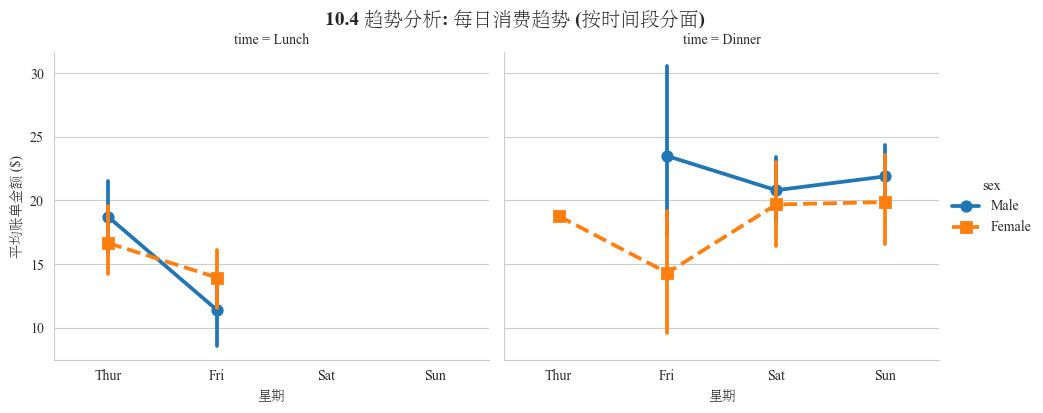

In [31]:
# ========== 10.4 时间趋势展示 ==========
g = sns.catplot(
    data=tips,  # 数据源：tips数据集
    x='day',  # x轴：星期（分类变量，时间序列）
    y='total_bill',  # y轴：账单总额（数值变量）
    col='time',  # col='time'：按时间段水平分面（2列：Lunch/Dinner）
    hue='sex',  # hue='sex'：按性别颜色分组
    kind='point',  # kind='point'：**点图类型**（专为趋势设计）
    order=['Thur', 'Fri', 'Sat', 'Sun'],  # order=：**自定义x轴顺序**（时间顺序）
    markers=['o', 's'],  # markers=：**不同hue使用不同标记**（['o'=圆形, 's'=方形]）
    linestyles=['-', '--'],  # linestyles=：**不同hue使用不同线型**（['-'=实线, '--'=虚线]）
    height=4,  # 每个子图高度：4英寸
    aspect=1.2)  # 每个子图宽高比：1.2（总宽=4.8英寸）
g.fig.suptitle(
    '10.4 趋势分析: 每日消费趋势 (按时间段分面)',  # 设置图表总标题
    fontsize=14,  # 标题字体大小14
    fontweight='bold',  # 标题加粗
    y=1.02)  # 标题垂直位置：上方2%
g.set_axis_labels('星期', '平均账单金额 ($)')  # 设置所有子图的x/y轴标签
plt.show()  # 显示当前图表（总尺寸：9.6×4英寸，2列分面展示趋势）

In [32]:
# ============================================================
# 打印完整参数总结
# ============================================================
print("\n" + "=" * 60)
print("Seaborn catplot 完整参数总结 (v0.13.2+)")
print("=" * 60)
print("""
1. 基础参数:
   - data: 数据源(DataFrame)
   - x, y: 坐标轴变量
   - hue: 颜色分组变量
   - kind: 图表类型 ⭐⭐⭐
     * 'strip': 散点条图
     * 'swarm': 蜂群图
     * 'box': 箱线图
     * 'violin': 小提琴图
     * 'boxen': 增强箱线图
     * 'point': 点图
     * 'bar': 柱状图
     * 'count': 计数图

2. 分面参数: ⭐⭐⭐
   - col: 列分面变量
   - row: 行分面变量
   - col_wrap: 控制每行列数(仅col时)
   - col_order, row_order: 分面顺序
   - order, hue_order: 类别顺序

3. 大小控制:
   - height: 每个子图高度(英寸)
   - aspect: 宽高比 (宽度 = height × aspect)

4. 坐标轴控制:
   - sharex: X轴共享(True/False/'col'/'row')
   - sharey: Y轴共享(True/False/'col'/'row')

5. 样式参数:
   - palette: 调色板
   - color: 单一颜色
   - margin_titles: 边缘标题(True/False)
   - legend: 图例显示(True/False/'auto'/'brief'/'full')
   - legend_out: 图例是否在外部(True/False)

6. 布局参数:
   - dodge: 分组是否并排(适用于hue)
   - orient: 方向('v'/'h')

7. 传递给底层函数的参数:
   每种kind都可接收对应函数的参数
   - Box: showmeans, notch, whis, showfliers等
   - Violin: inner, split, bw_adjust, cut等
   - Strip/Swarm: jitter, size, alpha, marker等
   - Bar: estimator, errorbar, capsize等
   - Point: markers, linestyles, capsize等

8. FacetGrid参数(通过facet_kws传递):
   - xlim, ylim: 坐标轴范围
   - despine: 是否去除边框

9. catplot vs 普通plot函数:
   ┌─────────────┬────────────────┬────────────────┐
   │  级别       │  Figure-level  │  Axes-level    │
   ├─────────────┼────────────────┼────────────────┤
   │  函数       │  catplot       │  boxplot等     │
   │  创建画布   │  自动创建      │  需手动创建    │
   │  分面功能   │  内置col/row   │  需手动循环    │
   │  灵活性     │  较低          │  更高          │
   │  易用性     │  更简单        │  需更多代码    │
   │  适用场景   │  快速探索      │  精细控制      │
   └─────────────┴────────────────┴────────────────┘

10. 使用建议:
   ✓ 快速数据探索 → catplot
   ✓ 需要分面展示 → catplot (col/row)
   ✓ 精细控制布局 → 普通plot函数
   ✓ 嵌入复杂图表 → 普通plot函数

11. 常见组合模式:
   - col + hue: 双重分组
   - row + col: 网格分面
   - col_wrap: 灵活换行
   - kind='violin' + split=True: 对比两组
   - kind='point': 展示趋势

12. 最佳实践:
   ⭐ 使用margin_titles=True提升可读性
   ⭐ 合理设置height和aspect
   ⭐ sharey根据数据特点选择
   ⭐ 复杂图表用col_wrap控制布局
   ⭐ 图例位置优化提升美观度
""")

print("\n" + "=" * 60)
print("Catplot教程完成！")
print("=" * 60)
print("✓ 展示了8种kind类型")
print("✓ 演示了所有核心参数")
print("✓ 提供了10个综合应用案例")
print("✓ 包含完整的参数对比表")
print("\nCatplot是最强大的分类数据可视化工具！")


Seaborn catplot 完整参数总结 (v0.13.2+)

1. 基础参数:
   - data: 数据源(DataFrame)
   - x, y: 坐标轴变量
   - hue: 颜色分组变量
   - kind: 图表类型 ⭐⭐⭐
     * 'strip': 散点条图
     * 'swarm': 蜂群图
     * 'box': 箱线图
     * 'violin': 小提琴图
     * 'boxen': 增强箱线图
     * 'point': 点图
     * 'bar': 柱状图
     * 'count': 计数图

2. 分面参数: ⭐⭐⭐
   - col: 列分面变量
   - row: 行分面变量
   - col_wrap: 控制每行列数(仅col时)
   - col_order, row_order: 分面顺序
   - order, hue_order: 类别顺序

3. 大小控制:
   - height: 每个子图高度(英寸)
   - aspect: 宽高比 (宽度 = height × aspect)

4. 坐标轴控制:
   - sharex: X轴共享(True/False/'col'/'row')
   - sharey: Y轴共享(True/False/'col'/'row')

5. 样式参数:
   - palette: 调色板
   - color: 单一颜色
   - margin_titles: 边缘标题(True/False)
   - legend: 图例显示(True/False/'auto'/'brief'/'full')
   - legend_out: 图例是否在外部(True/False)

6. 布局参数:
   - dodge: 分组是否并排(适用于hue)
   - orient: 方向('v'/'h')

7. 传递给底层函数的参数:
   每种kind都可接收对应函数的参数
   - Box: showmeans, notch, whis, showfliers等
   - Violin: inner, split, bw_adjust, cut等
   - Strip/Swarm: jitter, size, alpha, marker等
   - 